# 📘 Cas d'usage 01 — Résiliation client SaaS (churn)

**Certification « Concevoir et implémenter une solution d'intelligence artificielle »**

| | |
|---|---|
| **Candidat** | BANDERA QUENTIN |
| **Date** | 23/09/2026 |
| **Version du notebook** | v1.0 |
| **Type de problème** | Classification binaire (`churn`) + régression secondaire (`valeur_vie_client_eur`) |
| **Données** | `churn_saas_complet.csv` (5 035 lignes brutes) · `churn_saas_echantillon.csv` (50 lignes) · `catalogue_plans.csv` (4 plans) |
| **Environnement** | Python 3.12 · pandas · scikit-learn · matplotlib / seaborn · joblib · **XGBoost** + **Optuna** (challenger optimisé) · **MLflow** (suivi des expériences + registre de modèles) · **CodeCarbon** (empreinte carbone) · FastAPI (esquisse d'API) — versions exactes imprimées en annexe (§15) |

> **Comment lire ce notebook.** Chaque cellule de code est précédée d'une cellule markdown qui explique **ce que fait le code et pourquoi ce choix a été retenu** (et, quand c'est utile, quelles alternatives ont été écartées). Chaque grande étape se termine par un **journal de bord** (décisions, difficultés, essais abandonnés). Le notebook s'exécute de haut en bas sans intervention (`Kernel → Restart & Run All`).

### Configuration de l'environnement

**Pourquoi cette cellule en premier ?** Un notebook certifiant doit être *reproductible* : on centralise ici les imports, la graine aléatoire (`RANDOM_STATE = 42`) et les chemins. Fixer la graine garantit que le découpage train/test, la validation croisée et les modèles à base d'aléatoire (forêts) donnent **les mêmes chiffres à chaque exécution** — les valeurs citées dans le texte correspondent donc à ce que le lecteur verra.

**Choix des bibliothèques :**
- `pandas` / `numpy` : standard de manipulation tabulaire.
- `scikit-learn` : couvre l'essentiel du besoin (pipelines, validation croisée, modèles linéaires et ensemblistes, grid search, métriques, importance par permutation) avec une API homogène.
- `xgboost` + `optuna` : utilisés **uniquement pour le challenger** du §9.1 bis (XGBoost optimisé par Optuna), afin de vérifier qu'un boosting bien réglé ne bat pas le modèle retenu. Le modèle déployé n'en dépend pas : l'API et l'image Docker restent légères.
- `matplotlib` / `seaborn` : visualisations statiques, lisibles dans un notebook exporté en PDF/HTML.
- Palette : bleu = « non-churn », orange = « churn », gris = variables non informatives. Les deux couleurs principales sont distinguables par les personnes daltoniennes.

In [1]:
import warnings, json, re, platform, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
DATA_DIR = Path(".")
MODEL_DIR = Path("models"); MODEL_DIR.mkdir(exist_ok=True)
API_DIR = Path("api"); API_DIR.mkdir(exist_ok=True)

# Palette (bleu = non-churn, orange = churn, gris = neutre / leurre)
C_OK, C_CHURN, C_GREY = "#2a78d6", "#eb6834", "#9a9893"
PAL_CHURN = {0: C_OK, 1: C_CHURN}
sns.set_theme(style="whitegrid", rc={"grid.color": "#e6e5e1", "axes.edgecolor": "#c9c8c3",
                                     "axes.titleweight": "bold", "figure.dpi": 100})

print("Python      :", sys.version.split()[0], "|", platform.platform())
print("pandas      :", pd.__version__)
print("numpy       :", np.__version__)
print("scikit-learn:", sklearn.__version__)

Python      : 3.12.13 | macOS-27.0.1-arm64-arm-64bit
pandas      : 3.0.6
numpy       : 2.5.3
scikit-learn: 1.9.1


### Outils MLOps : suivi des expériences (MLflow) et empreinte carbone (CodeCarbon)

**Pourquoi MLflow dès le début du notebook ?** Pour que **chaque expérience soit tracée au moment où elle est faite**, et pas reconstituée après coup. Chaque évaluation de modèle (baselines, démonstration de fuite, comparaison, optimisation) crée un *run* MLflow avec ses paramètres, ses métriques et une étiquette de phase. Le modèle final est enregistré dans le **registre de modèles** (§10.1) avec l'alias `champion`. C'est ce qui rend concrets le versioning et la stratégie champion / challenger du §13.

**Choix de configuration :**
- **Stockage `sqlite:///mlflow.db`** (fichier local) plutôt qu'un simple dossier : le registre de modèles de MLflow a besoin d'une base de données. SQLite en fournit une sans serveur à installer. En production, on pointerait vers un serveur MLflow partagé (§11) ; seule l'URI change.
- **Un seul *experiment* `churn_saas`** : tous les runs du projet sont comparables dans la même vue.
- **Consulter les résultats** : `mlflow ui --backend-store-uri sqlite:///mlflow.db`, puis ouvrir http://127.0.0.1:5000.

**Pourquoi CodeCarbon ?** Entraîner des modèles consomme de l'électricité. Mesurer cette consommation permet (1) de **justifier par des chiffres** le choix d'un modèle sobre (§12.5), (2) d'estimer le coût environnemental du ré-entraînement récurrent (§13), et (3) de répondre à l'enjeu sociétal du numérique responsable (§4.5).

**Choix de configuration :**
- **`OfflineEmissionsTracker` avec `country_iso_code="FRA"`** : aucun appel réseau (pas de géolocalisation par IP), et les émissions sont calculées avec l'intensité carbone du mix électrique français.
- **Mesure de toute la machine** (mode par défaut) plutôt que du seul processus Python : les validations croisées tournent en parallèle (`n_jobs=-1`) dans des processus séparés, qu'un suivi par processus ne verrait pas. Contrepartie : les autres applications ouvertes sont aussi comptées, donc la mesure est une **borne haute**.
- On mesure **par phase** (comparaison, optimisation de chaque modèle, scoring) avec un gestionnaire de contexte `with carbon_phase(...)`, pour savoir *où* part l'énergie. Chaque phase est aussi enregistrée dans MLflow.
- ⚠️ *Limite* : sur un Mac sans droits administrateur, CodeCarbon ne lit pas la consommation réelle du processeur ; il l'**estime** à partir du modèle de CPU et de sa charge. Les valeurs sont donc des ordres de grandeur.

**Robustesse** : si l'une des deux bibliothèques n'est pas installée, les fonctions ci-dessous ne font rien et le reste du notebook s'exécute normalement.

In [2]:
import os, logging
from contextlib import contextmanager

os.environ.setdefault("MLFLOW_DISABLE_AGENT_HINT", "1")
warnings.filterwarnings("ignore", message="IProgress not found")  # barre de progression tqdm, sans effet sur les calculs
os.environ.setdefault("MLFLOW_LOGGING_LEVEL", "ERROR")

try:
    import mlflow
    from mlflow.models import infer_signature
    MLFLOW_OK = True
except ImportError:
    MLFLOW_OK = False
try:
    from codecarbon import OfflineEmissionsTracker
    CODECARBON_OK = True
except ImportError:
    CODECARBON_OK = False
for noisy in ["mlflow", "alembic", "codecarbon"]:  # après les imports, qui fixent leur propre niveau
    logging.getLogger(noisy).setLevel(logging.ERROR)

MLFLOW_URI, EXPERIMENT = "sqlite:///mlflow.db", "churn_saas"
REGISTERED_MODEL = "churn_saas_logistic"
CARBON_DIR = Path("carbone"); CARBON_DIR.mkdir(exist_ok=True)
EMISSIONS = []  # une ligne par phase mesurée

if MLFLOW_OK:
    mlflow.set_tracking_uri(MLFLOW_URI)
    mlflow.set_experiment(EXPERIMENT)


def log_run(name, params=None, metrics=None, tags=None, artifacts=()):
    # Crée un run MLflow (paramètres, métriques, étiquettes, fichiers) ; ne fait rien sans MLflow
    if not MLFLOW_OK:
        return None
    with mlflow.start_run(run_name=name) as run:
        mlflow.set_tags(tags or {})
        mlflow.log_params({k: str(v)[:500] for k, v in (params or {}).items()})
        mlflow.log_metrics({k: float(v) for k, v in (metrics or {}).items() if pd.notna(v)})
        for a in artifacts:
            mlflow.log_artifact(str(a))
    return run.info.run_id


@contextmanager
def carbon_phase(phase):
    # Mesure l'énergie et les émissions du bloc de code, et les enregistre (tableau + MLflow)
    if not CODECARBON_OK:
        yield
        return
    tracker = OfflineEmissionsTracker(country_iso_code="FRA", project_name=phase, output_dir=str(CARBON_DIR),
                                      measure_power_secs=1, log_level="error")
    tracker.start()
    try:
        yield
    finally:
        tracker.stop()
        d = tracker.final_emissions_data
        row = {"phase": phase, "durée (s)": d.duration, "énergie (Wh)": d.energy_consumed * 1000,
               "émissions (mg CO2eq)": d.emissions * 1e6, "puissance CPU moyenne (W)": d.cpu_power}
        EMISSIONS.append(row)
        log_run(f"carbone — {phase}", tags={"phase": "empreinte_carbone"},
                metrics={"duree_s": row["durée (s)"], "energie_Wh": row["énergie (Wh)"],
                         "emissions_mgCO2eq": row["émissions (mg CO2eq)"]})


print(f"MLflow     : {'actif — ' + MLFLOW_URI + ' / experiment ' + EXPERIMENT if MLFLOW_OK else 'non installé (pip install mlflow)'}")
print(f"CodeCarbon : {'actif — mix électrique France, résultats dans ' + str(CARBON_DIR) if CODECARBON_OK else 'non installé (pip install codecarbon)'}")

MLflow     : actif — sqlite:///mlflow.db / experiment churn_saas
CodeCarbon : actif — mix électrique France, résultats dans carbone


## 🟦 1. Résumé exécutif

**Problème.** Un éditeur SaaS B2B perd du revenu récurrent (MRR) chaque fois qu'un compte résilie à l'échéance. Sur l'historique fourni, **28 % des comptes résilient** : c'est un taux élevé qui pèse directement sur la croissance.

**Objectif.** Fournir aux équipes *Customer Success* (CSM) un **score de risque de churn** par compte, calculé *avant* l'échéance, pour prioriser les actions de rétention. L'outil est une **aide à la décision** : le CSM garde la main sur l'action à mener.

**Approche.**
1. Organisation des données en couches **Bronze** (sources intactes) → **Silver** (nettoyées) → **Gold** (prêtes pour le modèle), en Parquet, avec rapports de qualité et empreintes.
1. Nettoyage d'un jeu volontairement « sale » : 35 doublons exacts supprimés, nombres stockés en texte (`%`, `€`, `h`, virgules décimales), casse/espaces hétérogènes, 3 formats de date, 3 à 10 % de valeurs manquantes selon les colonnes.
2. **Détection et exclusion de la fuite de données** : `sante_compte_fin_periode` (score calculé *en fin de période*, donc après la décision) donne à lui seul une AUC ≈ 0,999 — irréaliste. Le commentaire libre du CSM est aussi écarté (risque de fuite + données personnelles non structurées).
3. Identification de 4 **variables leurres** (couleur du thème, datacenter, groupe A/B, jour de souscription) — sans pouvoir prédictif, écartées.
4. Jointure avec le **catalogue des plans** pour créer des variables métier (taux d'usage des fonctionnalités, écart au SLA support, MRR par siège).
5. Baseline (classifieur naïf) puis comparaison de **3 familles de modèles** (régression logistique, forêt aléatoire, gradient boosting) en validation croisée stratifiée 5 plis ; optimisation par **grid search**, puis un challenger **XGBoost optimisé par Optuna** (60 essais).

**Résultats clés** *(jeu de test tenu à l'écart, 1 000 comptes)*.
- Modèle retenu : **régression logistique régularisée** — la plus performante *et* la plus explicable, y compris face à XGBoost optimisé par Optuna (AUC CV 0,892 contre 0,887). **ROC-AUC ≈ 0,88**, **PR-AUC ≈ 0,76** (baseline naïve : 0,50 / 0,28 ; règle métier sans ML : ≈ 0,77 / 0,57).
- **Seuil métier** choisi pour limiter les faux négatifs (un churn raté coûte ~5× plus qu'une action de rétention inutile) : seuil **0,18**, le modèle détecte **près de 9 churners sur 10** (rappel 0,89) avec une précision de 0,53, et **divise par ~1,7 le coût des erreurs** par rapport au seuil par défaut de 0,5.
- Facteurs principaux : inactivité récente, faible nombre d'intégrations, faible ancienneté, tickets support / insatisfaction, retards de paiement.
- Cible secondaire (valeur vie client) : régression sur le log de la CLV, **R² ≈ 0,90 (échelle log)** ; utilisée uniquement pour enrichir la priorisation, **jamais comme variable du modèle de churn**.

**Industrialisation.** Chaque expérience est tracée dans **MLflow** ; le modèle final est inscrit au registre avec l'alias `champion`, prêt pour un scoring batch mensuel et une API. L'empreinte carbone est mesurée avec **CodeCarbon** : l'ensemble de l'entraînement pèse quelques dizaines de milligrammes de CO₂eq, dont l'essentiel pour l'étude Optuna / XGBoost ; l'optimisation de la logistique émet de 60 à 250 fois moins selon les exécutions (§12.5).

**Limites.** Données synthétiques sur une seule photographie temporelle (pas d'historique mensuel), hypothèses de coût à valider avec le métier, pas de mesure causale de l'effet des actions de rétention (à mettre en place par A/B test).

## 🟦 2. Cadrage métier et cas d'usage — journal de bord [C1]

### 2.1 Contexte et besoin

L'entreprise vend des abonnements mensuels par siège (4 plans : Starter, Pro, Business, Enterprise). Le revenu dépend du plan, du nombre de licences et de l'usage. Le churn fait perdre :
- le **MRR** du compte (revenu immédiat),
- la **valeur future** (CLV) : renouvellements, montées en gamme, recommandations.

Acquérir un nouveau client coûte généralement bien plus cher que d'en retenir un : **prévenir le churn est un levier de rentabilité direct**.

### 2.2 Problématique

| Niveau | Formulation |
|---|---|
| **Métier** | *Quels comptes les CSM doivent-ils contacter en priorité ce mois-ci, pour maximiser le revenu préservé avec une capacité d'action limitée ?* |
| **IA** | Estimer, pour chaque compte actif, la **probabilité de résiliation à la prochaine échéance** à partir des seules informations disponibles **au moment du scoring** (usage, facturation, support, contrat). |
| **Décision** | Un compte est signalé « à risque » si sa probabilité dépasse un **seuil fixé selon le coût métier** d'un faux négatif vs un faux positif. |

### 2.3 Utilisateurs et usage

- **Utilisateurs** : CSM et managers Customer Success.
- **Fréquence** : scoring **mensuel en batch** (le churn se décide à l'échéance, un score quotidien n'apporterait rien et générerait du bruit).
- **Forme de la sortie** : liste priorisée dans le CRM avec probabilité, niveau de risque, principaux facteurs explicatifs et valeur du compte.
- **Ce que l'outil ne fait pas** : il ne déclenche **aucune action automatique** (pas de remise, pas de relance automatique) — c'est un choix éthique et métier (voir §4).

### 2.4 Critères de succès

| Type | Critère | Justification |
|---|---|---|
| Technique | ROC-AUC et **PR-AUC** nettement supérieures à la baseline | La PR-AUC est plus informative que l'AUC quand la classe positive est minoritaire (28 %). |
| Technique | **Rappel ≥ 0,80** sur les churners au seuil retenu | Un churner non détecté = revenu perdu sans avoir tenté quoi que ce soit. |
| Métier | Coût total (FN + FP) inférieur à la stratégie « ne rien faire » et à « contacter tout le monde » | Le modèle doit être plus rentable que les stratégies triviales. |
| Usage | Chaque score est **explicable** au CSM | Un CSM n'agit pas sur une boîte noire ; il doit savoir *quoi* dire au client. |

**Performance attendue, fixée avant la modélisation :**

| Dimension | Objectif | Justification | Vérifié au |
|---|---|---|---|
| Qualité du classement | ROC-AUC et PR-AUC **nettement** au-dessus de la règle métier | Sinon, le ML ne vaut pas le coût de son industrialisation | §8.4, §9.4 |
| Détection | Rappel ≥ 0,80 au seuil retenu | Voir ci-dessus | §9.3, §9.4 |
| Qualité des probabilités | Brier score inférieur à celui de la baseline naïve (0,20) | Les CSM lisent la probabilité comme un risque : elle doit être fiable | §8.4, §9.4 |
| Temps d'entraînement | < 1 min sur un ordinateur portable | Permet de ré-entraîner souvent, sans infrastructure dédiée | §12.1 bis |
| Scoring batch (5 000 comptes) | < 10 s | Job mensuel : le temps n'est pas critique, mais doit rester négligeable | §12.1 bis |
| Latence de l'API (1 compte) | < 100 ms | Re-scoring à la demande depuis le CRM, sans attente perceptible | §12.1 bis |
| Énergie | Négligeable, **mesurée** ; à performance égale, le modèle le plus sobre est préféré | Éco-conception (§4.5) | §12.5 |

**Type de résultat attendu : probabiliste, puis décision déterministe.**
- Le modèle produit une **probabilité de churn calibrée** (entre 0 et 1) pour chaque compte. Une simple étiquette « part / reste » ne suffirait pas : les CSM ont besoin d'un **classement** pour prioriser, et d'un niveau de risque qu'ils peuvent interpréter.
- Cette probabilité est transformée en **décision déterministe** par un seuil métier fixe (compte « à risque » ou non) et en **niveau** (élevé, modéré, faible). Le même compte donne toujours le même résultat : c'est auditable et explicable.
- Chaque score est accompagné de ses **3 principaux facteurs**, pour que le CSM sache quoi dire au client.
- La cible secondaire (CLV) est une **valeur continue** : c'est un problème de régression, traité à part (§12.4).

### 2.5 Hypothèses de départ (à vérifier en EDA)

- **H1 — Engagement** : faible adoption des sièges, peu de connexions et une dernière connexion lointaine augmentent le risque.
- **H2 — Friction support** : beaucoup de tickets, un délai de réponse long et un CSAT bas augmentent le risque.
- **H3 — Santé financière** : les retards de paiement sont un signal fort de départ.
- **H4 — Ancrage** : les comptes récents et peu intégrés (peu d'intégrations tierces) partent plus facilement.
- **H5 — Leurres** : la couleur de l'interface, le datacenter, le groupe A/B et le jour de souscription n'ont aucun lien logique avec le churn.

### 📓 Journal de bord — Cadrage
- **Décision** : cible principale = `churn` (binaire), cible secondaire = CLV (régression) utilisée *à côté* du score, pour pondérer la priorisation (un compte à risque *et* à forte valeur passe en premier).
- **Décision** : scoring mensuel batch plutôt que temps réel → architecture plus simple et adaptée au rythme contractuel.
- **Difficulté** : l'énoncé ne donne pas les coûts réels d'une action de rétention ni son taux de succès → hypothèses explicites posées au §9 et analyse de sensibilité.

## 🟦 3. Données : disponibilité, gouvernance et alternatives — journal de bord [C1]

### 3.1 Sources disponibles

| Fichier | Contenu | Rôle dans le projet |
|---|---|---|
| `churn_saas_complet.csv` | ~5 000 comptes × 29 colonnes | Jeu d'apprentissage / évaluation |
| `churn_saas_echantillon.csv` | 50 comptes, même schéma | Sous-ensemble du fichier complet (vérifié au §5) → utilisé pour **simuler un lot de scoring** en §10 |
| `catalogue_plans.csv` | 4 plans : prix/siège, fonctionnalités, SLA support, stockage, support dédié | **Référentiel** joint sur `plan` : contrôle de cohérence et variables métier |

### 3.2 Origine des données en situation réelle et gouvernance

| Famille de variables | Système source probable | Fraîcheur | Propriétaire |
|---|---|---|---|
| Contrat (plan, sièges, ancienneté, MRR) | Facturation / CRM | Mensuelle | Finance / Sales Ops |
| Usage (connexions, heures, fonctionnalités, intégrations) | Logs produit / analytics | Quotidienne → agrégée 30 j | Product / Data |
| Support (tickets, délai, CSAT) | Outil de ticketing | Quotidienne → agrégée 90 j | Support |
| Paiement (retards) | Facturation | Mensuelle | Finance |
| Profil de l'entreprise (secteur, pays, taille) | CRM | Rarement mise à jour | Sales |

**Points de gouvernance :**
- Les données sont **B2B** (comptes entreprises) : peu de données personnelles directes, **sauf** le commentaire libre du CSM qui peut contenir des noms ou des jugements sur des personnes → à exclure (voir §4).
- Il faut garantir la **disponibilité au moment du scoring** : chaque variable utilisée doit exister *avant* l'échéance. C'est ce critère qui exclut `sante_compte_fin_periode`.
- Un **dictionnaire de données versionné** et un contrat d'interface entre sources et pipeline sont nécessaires (formats, unités, fréquences).
- Les données sont organisées en **trois couches Bronze → Silver → Gold** (§5.0), chacune avec son rapport de qualité et son empreinte, pour tracer chaque modèle jusqu'aux fichiers sources.

### 3.3 Alternatives et enrichissements possibles

- **Historique mensuel** des métriques d'usage (tendance sur 3-6 mois) : une *baisse* d'usage est souvent plus prédictive qu'un niveau absolu. Les données fournies sont une photographie unique.
- **Données produit fines** (événements par fonctionnalité), **NPS**, **contenu des tickets** (catégories, pas le texte brut), **historique de contacts CSM**.
- **Données externes** (santé financière de l'entreprise cliente, levées de fonds, recrutements) — à évaluer au regard du RGPD et de la finalité.

### 3.4 Données nécessaires a minima, accès et solutions de repli

**Socle minimal et données facultatives.** Toutes les variables n'ont pas le même statut : certaines sont indispensables pour produire un score, d'autres améliorent le score mais peuvent manquer. Cette distinction est appliquée concrètement par le schéma de l'API (§10.4) : champs obligatoires ou optionnels.

| Niveau | Variables | Si absentes au moment du scoring |
|---|---|---|
| **Bloquant** : identification et contrat | `client_id`, `plan`, `taille_entreprise`, `anciennete_mois`, `sieges_souscrits` + référentiel `catalogue_plans.csv` | Scoring impossible : `plan` est la clé de jointure avec le catalogue (prix, SLA, fonctionnalités incluses). L'API refuse la requête (422). |
| **Requis** : compteurs produits automatiquement par les systèmes | `utilisateurs_actifs`, `connexions_30j`, `fonctionnalites_utilisees`, `derniere_connexion_jours`, `tickets_support_90j` | Ces compteurs valent 0 en l'absence d'activité : une valeur absente signale une **panne de la source**, pas une information manquante. L'API refuse la requête (422) plutôt que de deviner. |
| **Facultatif** | `secteur`, `pays`, `taux_adoption_pct`, `heures_usage_30j`, `nb_integrations`, `delai_reponse_support_h`, `csat`, `retards_paiement_12m`, MRR | Imputées : recalcul métier (§7.1), médiane ou modalité « Inconnu » (§7.4). Le scoring fonctionne, ce qui est testé au §10.4. |

**Existence et accès.** Dans le cadre du projet, l'existence et l'accès sont vérifiés par la lecture effective des 3 fichiers (§5.1), leur empreinte SHA-256 à l'ingestion (Bronze, §5.0) et l'inventaire de qualité (§5.3). En situation réelle, l'accès doit être formalisé **avant** le développement, avec chaque propriétaire de données :

| Source | Mode d'accès prévu | Validation | Contraintes |
|---|---|---|---|
| Facturation / CRM | Export planifié ou API, compte de service en **lecture seule** | Sales Ops / Finance | Confidentialité commerciale (MRR, remises) |
| Logs produit | Tables **agrégées par compte** de l'entrepôt de données (pas les logs bruts par utilisateur) | Product / Data | Minimisation : aucun suivi individuel des utilisateurs finaux |
| Ticketing | API de l'outil, **champs structurés uniquement** (nombre de tickets, délai, CSAT) | Support | Le texte des tickets est exclu (données personnelles) |
| Catalogue des plans | Référentiel versionné | Finance / Marketing produit | Toute évolution tarifaire doit être répercutée avant le scoring |

Chaque accès est inscrit au **registre des traitements** (RGPD, art. 30) et validé par le DPO (voir §4.8).

**Plan de repli si une source est indisponible.** On a **mesuré** au §8.5 la perte de performance quand une source entière manque. Cela permet de décider à l'avance quoi faire en cas de panne :

| Source indisponible | Effet mesuré (AUC CV, modèle complet 0,891) | Repli retenu |
|---|---|---|
| **Usage produit** (logs) | 0,806 (−0,085) : la plus forte perte, mais encore au-dessus de la règle métier (0,797) | Le scoring étant mensuel, on **reporte le scoring** de quelques jours le temps de rétablir la source. Si la panne dure, on utilise un modèle de secours entraîné sans ces variables, en prévenant les CSM que les scores sont moins fiables. |
| **Support** (ticketing) | 0,843 (−0,048) | Modèle de secours sans les variables support, avec un avertissement dans le CRM. |
| **Paiement** (facturation) | 0,884 (−0,007) : perte négligeable | Retards imputés par la médiane (déjà prévu par le pipeline) ; le scoring continue normalement. |
| **Profil de l'entreprise** (CRM) | 0,892 (+0,001) : aucune perte | Modalité « Inconnu » (déjà prévue) ; le scoring continue normalement. |
| **Contrat / catalogue** | Non testé : socle bloquant | Pas de scoring : on garde les scores du mois précédent et on alerte l'équipe data. |

**Représentativité du jeu de données.**
- **Volume** : 5 000 comptes distincts (après retrait de 35 doublons), dont 1 400 churners. C'est suffisant pour un modèle à 22 variables et un jeu de test de 1 000 comptes (≈ 280 churners).
- **Couverture** : tous les segments sont présents. 4 plans (Pro 35 %, Starter 27 %, Business 26 %, Enterprise 11 %), 4 tailles (PME 41 %, TPE 34 %, ETI 18 %, GE 7 %), 6 pays (France 54 %, chacun des 5 autres entre 8 et 9 %) et 7 secteurs (8 à 18 % chacun). En revanche, les **grandes entreprises, le plan Enterprise et les pays hors France sont peu nombreux** : la performance sur ces segments est mesurée avec moins de précision (§12.3).
- **Taux de churn (28 %)** : à confronter au taux réel de l'entreprise. S'il diffère, les probabilités devront être recalibrées ; le classement des comptes, lui, reste valable.
- **Limites** : données synthétiques, photographie unique (pas de tendance d'usage, pas de validation temporelle, saisonnalité inconnue).

**Conclusion** : le jeu est représentatif des **types de comptes** et des **signaux métier** utiles au cas d'usage. Il ne l'est pas de la **dynamique temporelle**. Avant la mise en production, le modèle devra être validé sur une cohorte réelle (mois suivant, §13).

### 📓 Journal de bord — Données
- **Décision** : le catalogue est joint car il apporte une information *de référence* stable (prix, SLA) permettant de créer des ratios métier et de vérifier la cohérence du MRR.
- **Décision** : architecture en couches Bronze / Silver / Gold (§5.0) pour la traçabilité et la séparation des responsabilités.
- **Décision** : l'échantillon de 50 lignes n'est **pas** utilisé comme jeu de validation (il est inclus dans le fichier complet) mais comme **exemple de lot de production**.
- **Décision** : socle minimal défini (variables bloquantes, requises, facultatives), appliqué par le schéma de l'API ; plan de repli par source, fondé sur une mesure (§8.5) plutôt que sur une supposition.


## 🟦 4. Enjeux éthiques, sociétaux et conformité — journal de bord [C2]

### 4.1 Conséquences des erreurs

| Erreur | Conséquence métier | Conséquence pour le client |
|---|---|---|
| **Faux négatif** (churner non détecté) | Perte du MRR et de la CLV sans tentative de rétention | Client insatisfait non accompagné |
| **Faux positif** (fidèle signalé à risque) | Temps CSM consommé, éventuelle remise inutile | Sollicitation superflue, sentiment d'être « surveillé » |

→ Le FN est plus coûteux pour l'entreprise, **mais** le FP n'est pas gratuit : trop de sollicitations dégradent la relation. Le seuil (§9) arbitre explicitement entre les deux.

### 4.2 Biais et équité

- **Risque** : le modèle pourrait systématiquement sur-signaler certains segments (TPE, un pays, un secteur) parce que leur taux de churn historique est plus élevé. Ce n'est pas illégitime en soi (ce sont des entreprises, pas des personnes protégées), mais cela peut conduire à **concentrer les efforts sur certains clients et en délaisser d'autres**.
- **Mesure** : au §12, on contrôle le **rappel et le taux de faux positifs par segment** (taille, pays, plan). Un écart important déclencherait une revue.
- **Variables sensibles** : aucune donnée sur les personnes physiques (âge, genre…) n'est présente. `pays` et `secteur` sont conservés car pertinents métier, mais surveillés.

### 4.3 RGPD et conformité

- **Base légale** : intérêt légitime (gestion de la relation contractuelle B2B). Les utilisateurs finaux des clients ne sont pas scorés individuellement — seul le **compte** l'est.
- **Minimisation** : on retire tout ce qui n'est pas nécessaire (identifiant du modèle, commentaire libre, variables leurres).
- **Pseudonymisation** : un pseudonyme calculé avec une clé secrète est créé dès la couche Silver (§6.1 bis) ; la table d'entraînement (Gold) ne contient que ce pseudonyme. Seules les équipes ayant accès à Silver, zone restreinte qui contient la correspondance, peuvent revenir au compte. Ce n'est pas une anonymisation (réversible avec la clé, quasi-identifiants conservés) : la table Gold reste confidentielle et à accès restreint.
- **Commentaire CSM (`commentaire_csm`)** : texte libre pouvant contenir des données personnelles ou des jugements subjectifs ; il est aussi rédigé à un moment inconnu (potentiellement après des signaux de départ) → **exclu**.
- **Transparence et intervention humaine** : pas de décision automatisée produisant des effets juridiques (art. 22 RGPD) ; le CSM décide. Les facteurs explicatifs sont fournis avec chaque score.
- **AI Act** : un scoring de churn B2B ne figure pas parmi les usages à haut risque (annexe III) et ne relève pas des obligations de transparence de l'article 50 (pas de chatbot ni de contenu généré) : c'est un usage à **risque minimal**. Les bonnes pratiques (documentation, traçabilité, supervision humaine) sont néanmoins appliquées volontairement, et l'obligation de **maîtrise de l'IA** (art. 4 : former les utilisateurs) s'applique à tous les déployeurs. ⚠️ Utiliser ce score pour **évaluer les CSM** ferait basculer l'usage dans le haut risque (annexe III, emploi) : cet usage est exclu (§4.7).
- **Conservation** : scores historisés pour le monitoring avec une durée limitée (ex. 24 mois), accès restreint aux équipes CS.

### 4.4 Variables écartées pour raisons éthiques / méthodologiques

| Variable | Raison |
|---|---|
| `client_id` | Identifiant : aucun sens prédictif, risque de mémorisation ; **pseudonymisé** (HMAC à clé secrète) dès Silver, seul le pseudonyme passe dans Gold |
| `sante_compte_fin_periode` | **Fuite de données** : connue après la décision |
| `commentaire_csm` | Texte libre non structuré, données personnelles possibles, moment de rédaction inconnu (fuite probable) |
| `valeur_vie_client_eur` | Cible secondaire, calculée a posteriori (dépend de la durée de vie réelle, donc du churn) |

### 4.5 Impact environnemental

- Entraîner et ré-entraîner des modèles consomme de l'énergie. Le principe retenu est la **sobriété** : à performance équivalente, on préfère le modèle le moins coûteux à entraîner et à exécuter.
- L'empreinte est **mesurée** avec CodeCarbon, phase par phase (§12.5), et non supposée. Le coût annuel du ré-entraînement et du scoring récurrents en est déduit.
- Le scoring mensuel en batch (et non en temps réel) est aussi un choix sobre : on calcule 12 fois par an au lieu de milliers de fois par jour.

### 4.6 Référentiels éthiques appliqués

Le projet s'appuie sur les référentiels européens et français suivants :
- **Lignes directrices en matière d'éthique pour une IA digne de confiance** (groupe d'experts de haut niveau de la Commission européenne, 2019) et leur liste d'auto-évaluation **ALTAI** (2020) : 7 exigences, détaillées ci-dessous ;
- **Règlement européen sur l'IA (AI Act, règlement 2024/1689)** : classification du risque (§4.3) ;
- **RGPD** : base légale, minimisation, information, conservation, AIPD (§4.3, §4.8) ;
- **CNIL** : rapport *Comment permettre à l'homme de garder la main ?* (2017), qui pose les principes de **loyauté** et de **vigilance**, et recommandations sur le développement des systèmes d'IA (fiches pratiques, 2024-2025) ;
- **Rapport Villani** *Donner un sens à l'intelligence artificielle* (2018) : explicabilité, IA sobre (« IA verte »), non-discrimination.

**Application des 7 exigences européennes au projet :**

| Exigence | Ce que fait le projet | Où |
|---|---|---|
| 1. Facteur humain et contrôle humain | Le score **priorise**, le CSM **décide** ; aucune action automatique ; pas de décision au sens de l'art. 22 RGPD | §2.3, §4.3 |
| 2. Robustesse technique et sécurité | Validation croisée, test utilisé une seule fois, robustesse mesurée par source de données, API qui refuse les entrées invalides, empreinte du modèle vérifiée au chargement | §8.5, §9, §10.4 |
| 3. Vie privée et gouvernance des données | Minimisation, pseudonymisation à clé secrète, couches Bronze / Silver / Gold, accès restreint, durées de conservation | §3, §4.3, §6.1 bis, §13.6 |
| 4. Transparence | Modèle explicable (régression logistique), 3 facteurs fournis avec chaque score, documentation et lignée des données dans MLflow | §9.6, §10.1 bis, §10.2 |
| 5. Diversité, non-discrimination, équité | Aucune variable sur des personnes ; audit du rappel et des faux positifs par segment ; profil de l'entreprise identifié comme inutile au modèle | §4.2, §8.5, §12.3 |
| 6. Bien-être sociétal et environnemental | Empreinte carbone mesurée (CodeCarbon), choix du modèle le plus sobre, scoring mensuel plutôt qu'en temps réel | §4.5, §12.5 |
| 7. Responsabilité | Journal de bord, traçabilité de chaque expérience (MLflow), validation par les acteurs concernés | §4.8, §13 |

### 4.7 Impacts sociétaux et dilemmes éthiques

**Impacts à anticiper au déploiement :**
- **Pour les CSM** : risque de **biais d'automatisation** (suivre le score sans esprit critique). Réponse : les facteurs explicatifs sont fournis, le CSM peut écarter une alerte, et les utilisateurs sont formés (art. 4 AI Act). Risque de **détournement de finalité** si le score servait à juger les CSM (« vos comptes partent ») : cet usage est **exclu** par la charte d'usage.
- **Pour les clients** : **traitement commercial inégal** si les gestes commerciaux (remises) sont réservés aux comptes « à risque » : les clients fidèles seraient moins bien traités, et certains pourraient être tentés de simuler un désengagement. Réponse : privilégier des actions d'accompagnement (formation, onboarding) plutôt que des remises. **Sentiment de surveillance** de l'usage du produit : seules des données agrégées par compte sont utilisées, et les clients en sont informés (politique de confidentialité).
- **Comptes classés « faible risque »** : risque qu'ils soient délaissés, ce qui ferait de la prédiction une prophétie auto-réalisatrice. Réponse : le score s'ajoute au suivi habituel des CSM, il ne le remplace pas.
- **Boucle de rétroaction** : les actions de rétention modifient les churns futurs, donc les données du prochain ré-entraînement. Réponse : garder un groupe témoin non contacté pour mesurer l'effet réel (§13.4).
- **Biais historique** : les churns passés reflètent aussi la qualité du suivi des CSM de l'époque. Le modèle apprend « qui est parti », pas « qui serait parti sans action ».

**Dilemmes éthiques identifiés et arbitrages :**

| Dilemme | Options en présence | Arbitrage retenu | Justification |
|---|---|---|---|
| Détecter plus de churners **ou** solliciter moins les clients | Seuil 0,5 (moins d'alertes) ou seuil bas (plus de churners détectés) | Seuil **0,18** : rappel 0,89, mais 47 % des comptes signalés | Un churn raté coûte ~5 fois plus qu'une action inutile ; la gêne est limitée par des actions légères pour les segments très sollicités (§9.3, §12.3) |
| Maximiser le revenu **ou** traiter équitablement petits et grands clients | Sélectionner les comptes par MRR à risque (p × MRR) ou par probabilité | Sélection par **probabilité** ; le MRR sert seulement à **ordonner** la liste | Revenu quasi identique, mais 20 comptes sauvés de plus et pas de mise à l'écart des petits clients (§12.2) |
| Performance **ou** explicabilité | XGBoost optimisé ou régression logistique | Régression logistique | Pas de vrai dilemme ici : la logistique est aussi la plus performante (§9.1 bis) |
| Performance **ou** vie privée | Exploiter le commentaire CSM, des données externes, le profil de l'entreprise | Commentaire exclu ; données externes non utilisées ; retrait du profil de l'entreprise proposé | Minimisation ; le profil de l'entreprise n'apporte rien au modèle (§8.5) |
| Transparence envers le client **ou** efficacité commerciale | Montrer le score au client, l'informer en général, ou ne rien dire | Information générale (politique de confidentialité, art. 13-14 RGPD), **pas** d'affichage du score | Loyauté envers le client sans transformer le score en étiquette visible |

### 4.8 Information et validation par les acteurs concernés

**Qui est informé de quoi, et qui valide :**

| Acteur | Ce qui lui est présenté | Ce qu'il valide | Quand |
|---|---|---|---|
| **Commanditaire** (direction Customer Success) | Risques, dilemmes et arbitrages (§4.7), hypothèses de coût, limites du modèle, **empreinte carbone et arbitrages d'éco-conception** (§12.5) | Seuil, usages autorisés et interdits (charte d'usage), fréquence de ré-entraînement et budget de calcul | Cadrage, puis avant la mise en production |
| **DPO** | Finalité, jeu de données, base légale, minimisation, pseudonymisation, cycle de vie (§13.6) | Inscription au registre des traitements (art. 30), décision sur l'AIPD, mentions d'information, durées de conservation | **Avant** l'accès aux données réelles |
| **Juristes** | Contrats clients (usage des données d'utilisation), classification AI Act, exclusion de l'évaluation des salariés | Conformité contractuelle et réglementaire | Avant la mise en production |
| **Propriétaires des données** (Finance, Product, Support, Sales Ops) | Variables utilisées, mode d'accès, fréquences, cycle de vie (§3.4, §13.6) | Accès, qualité, contrat d'interface | Avant le développement |
| **RSSI** | Stockage, gestion des secrets, sécurité de l'API | Mesures de sécurité | Avant la mise en production |
| **Managers CS et CSM** | Fonctionnement, limites, signification des facteurs, ce que le score **n'est pas** | Charte d'usage ; formation suivie | Avant le déploiement |
| **Représentants du personnel** (CSE), le cas échéant | Changement de l'organisation du travail des CSM | Information-consultation (introduction d'une nouvelle technologie) | Avant le déploiement |

**Check-list de vérification légale et éthique du jeu de données** (à faire valider par le DPO et les juristes) :

| Point de contrôle | Statut dans le projet |
|---|---|
| Finalité déterminée, explicite et documentée | ✅ §2.2 |
| Base légale : intérêt légitime, avec mise en balance des intérêts | 📝 Argumentée au §4.3, à valider par le DPO |
| Absence de données sensibles (art. 9 RGPD) | ✅ Vérifiée ; le texte libre est exclu |
| Minimisation : seules les variables utiles entrent dans Gold | ✅ §7.2, §7.2 bis |
| Pseudonymisation et séparation des accès | ✅ §6.1 bis |
| Nécessité d'une **AIPD** : au moins 2 critères du CEPD potentiellement remplis (évaluation / scoring, croisement de plusieurs sources) | 📝 AIPD recommandée par précaution, ou absence justifiée par écrit par le DPO |
| Inscription au registre des traitements | 📝 Fiche préparée (finalité, données, durées, destinataires), à valider |
| Information des clients (art. 13-14) | 📝 Mention à ajouter à la politique de confidentialité |
| Durées de conservation par jeu de données | 📝 Proposées au §13.6, à valider |
| Absence de fuite et de variables non pertinentes | ✅ §6.5, §7.2, §8.3 |

**Dans le cadre de la certification**, ces validations sont simulées : le dossier qui serait soumis est ce notebook, avec les rapports de qualité (`_ingestion.json`, `_qualite.json`, `_meta.json`) et le registre MLflow. En situation réelle, chaque ligne marquée 📝 ferait l'objet d'une validation écrite (compte rendu de revue, avis du DPO) avant la mise en production.

### 📓 Journal de bord — Éthique
- **Décision** : mesure de l'empreinte carbone intégrée au projet (CodeCarbon) et critère de sobriété dans le choix du modèle.
- **Décision** : supervision humaine systématique ; le modèle *priorise*, il ne *décide* pas.
- **Décision** : audit d'équité par segment inclus dans l'évaluation (§12) et dans le monitoring (§13).
- **Décision** : référentiels explicites (lignes directrices européennes et ALTAI, AI Act, RGPD, CNIL, rapport Villani) et correspondance exigence par exigence (§4.6).
- **Décision** : dilemmes nommés et arbitrés (§4.7) ; usage du score pour évaluer les CSM explicitement exclu.
- **Décision** : plan d'information et de validation par acteur, check-list DPO / juristes (§4.8).
- **Correction** : classification AI Act revue (risque minimal et non « limité », qui désigne les obligations de transparence de l'art. 50).


## 🟦 5. Chargement et compréhension des données [C3]

### 5.0 Architecture des données : Bronze → Silver → Gold

**Pourquoi une architecture en couches (dite « médaillon ») ?** Plutôt que d'aller directement du CSV brut au modèle en mémoire, on **matérialise trois états des données**, chacun avec un rôle précis. C'est la pratique standard des plateformes de données (Databricks, lakehouse), et celle vue en formation (`data/raw`, `data/gold`).

| Couche | Contenu | Règle | Où dans ce notebook |
|---|---|---|---|
| 🥉 **Bronze** | Les fichiers sources **tels que reçus**, copiés à l'identique | Aucune modification ; empreinte SHA-256 et date d'ingestion | §5.0 (ci-dessous) |
| 🥈 **Silver** | Données **nettoyées** : types corrects, doublons retirés, catégories normalisées, jointure catalogue, pseudonyme `pseudo_id` à côté de `client_id` | Aucune imputation ni variable calculée : on corrige la forme, pas le fond (retirer un doublon exact n'invente aucune valeur) ; seuls ajouts : colonnes du catalogue par jointure et pseudonyme `pseudo_id` ; zone à accès restreint (table de correspondance) | §6.1 bis |
| 🥇 **Gold** | Table **prête pour le modèle** : 22 variables retenues, imputations métier, variables dérivées, cibles, identifiant **pseudonymisé** | Uniquement des variables disponibles au moment du scoring (pas de fuite, pas de leurre) ; aucun identifiant en clair | §7.2 bis |

**Ce que cela apporte :**
- **Traçabilité** : on peut toujours remonter d'un modèle à la table Gold qui l'a entraîné, puis à la table Silver et aux fichiers Bronze d'origine (empreintes SHA-256 enregistrées dans MLflow, §10.1 bis).
- **Reprise sans tout refaire** : si l'on change une variable dérivée, on repart de Silver, pas du CSV brut.
- **Séparation des responsabilités** : l'équipe data est garante de Bronze / Silver, l'équipe ML de Gold. Chaque couche a son rapport de qualité.
- **Sécurité anti-fuite** : la variable de fuite et les leurres **n'entrent pas dans Gold**. Le modèle ne peut pas les utiliser par erreur.

**Pourquoi Parquet pour Silver et Gold (et pas CSV) ?** Parquet **conserve les types** (dates, nombres, catégories). Relire un CSV nettoyé ramènerait les problèmes de types qu'on vient de corriger. Parquet est aussi compressé et lisible par tous les outils data (Spark, DuckDB, pandas). Bronze reste en CSV, car c'est le format reçu, qu'on ne transforme pas.

**Convention de nommage.** Les colonnes sources sont déjà nommées de façon claire et homogène : elles sont **conservées telles quelles** pour garder la correspondance avec les systèmes sources (pas de renommage, donc pas de table de correspondance à maintenir). Les nouvelles colonnes et les fichiers suivent les mêmes règles :
- noms en **français**, en **snake_case**, sans accents ni espaces ;
- **unité ou fenêtre en suffixe** : `_eur`, `_h`, `_pct`, `_jours`, `_30j`, `_90j`, `_12m` (par ex. `ecart_sla_support_h`) ;
- variables dérivées nommées par ce qu'elles mesurent (`ratio_fonctionnalites`, `heures_par_utilisateur`, `sieges_inactifs`), préfixe `log_` pour une transformation logarithmique ;
- fichiers nommés par contenu (`comptes.parquet`, `features_churn.parquet`) ; rapports de couche préfixés par `_` (`_ingestion.json`, `_qualite.json`, `_meta.json`) ; modèles versionnés (`churn_model_v1.0.0.joblib`).

**Choix du modèle de stockage.** Chaque type de données a un usage différent, donc un stockage différent :

| Données | Stockage retenu (cible) | En local dans ce projet | Pourquoi |
|---|---|---|---|
| Bronze, Silver, Gold | **Stockage objet** (type S3) en Parquet, exposé dans un **entrepôt de données** | Dossiers `data/` en Parquet | Données tabulaires à schéma fixe, lues en bloc pour l'analyse et l'entraînement, à historiser mois par mois ; le stockage objet est peu coûteux et sans limite de volume |
| Scores mensuels | **Base relationnelle** (et champ du CRM) | Sortie du batch (§10.3) | Lus compte par compte par les CSM et l'API, avec des contraintes d'intégrité (un score par compte et par mois) |
| Modèles et métadonnées | **Registre MLflow** (base relationnelle + stockage objet pour les fichiers) | `mlflow.db` + `mlruns/` | Versions, métriques, alias `champion`, retour arrière |
| Base de documents (type MongoDB) | **Écartée** | — | Utile pour des données semi-structurées à schéma variable ; ici, toutes les données sont tabulaires à schéma fixe |

#### Ingestion Bronze

**Ce que fait la cellule :** elle copie les 3 fichiers sources dans `data/bronze/` **octet pour octet**, vérifie que la copie est identique (même empreinte SHA-256) et qu'aucun fichier n'est vide, puis écrit un fichier `_ingestion.json` : date d'ingestion, taille, nombre de lignes et empreinte de chaque fichier. La suite du notebook lit les données **depuis Bronze**, jamais directement depuis la source.

In [3]:
import shutil, hashlib
from datetime import datetime

DATA_LAKE = Path("data")
BRONZE_DIR, SILVER_DIR, GOLD_DIR = (DATA_LAKE / layer for layer in ["bronze", "silver", "gold"])
for d in (BRONZE_DIR, SILVER_DIR, GOLD_DIR):
    d.mkdir(parents=True, exist_ok=True)


def sha256_file(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


SOURCES = ["churn_saas_complet.csv", "churn_saas_echantillon.csv", "catalogue_plans.csv"]
ingestion = {"ingested_at": datetime.now().isoformat(timespec="seconds"), "files": {}}
for name in SOURCES:
    src, dst = DATA_DIR / name, BRONZE_DIR / name
    shutil.copy2(src, dst)                                 # copie à l'identique, métadonnées comprises
    assert sha256_file(src) == sha256_file(dst), f"copie altérée : {name}"
    with dst.open(encoding="utf-8-sig") as f:
        n_rows = sum(1 for _ in f) - 1                     # lignes de données (hors en-tête)
    assert n_rows > 0, f"fichier vide : {name}"
    ingestion["files"][name] = {"source": str(src), "lignes": n_rows,
                                "octets": dst.stat().st_size, "sha256": sha256_file(dst)}
(BRONZE_DIR / "_ingestion.json").write_text(json.dumps(ingestion, indent=2, ensure_ascii=False))

print(f"Ingestion Bronze du {ingestion['ingested_at']} -> {BRONZE_DIR}/")
pd.DataFrame(ingestion["files"]).T[["lignes", "octets", "sha256"]]

Ingestion Bronze du 2026-10-04T17:50:14 -> data/bronze/


,lignes,octets,sha256
churn_saas_complet.csv,5035,727622,2fc45e8c3c74d3ddcdbda162c5bb50184587201b46d877...
churn_saas_echantillon.csv,50,7824,680f5371c406f47a3a67f1611cb016c17efd61e93a52d1...
catalogue_plans.csv,4,203,c94f6f52652532c578cb7a44d752b8b197ef84f5e6c6e1...


### 5.1 Lecture des fichiers bruts

Les fichiers sont lus **depuis la couche Bronze**.

**Choix : tout lire en texte (`dtype=str`).** Les colonnes numériques contiennent des valeurs comme `"33,3"`, `"20.0%"` ou `"11.37 €"`. Si on laisse pandas deviner les types, il transformerait silencieusement ces colonnes en `object` ou, pire, produirait des `NaN` sans qu'on le voie. Lire en texte permet d'**inventorier les formats** avant de convertir, et de contrôler chaque conversion.

**`encoding="utf-8-sig"`** : les fichiers commencent par un BOM (caractère invisible `﻿`) ; sans cette option, le nom de la première colonne deviendrait `"﻿client_id"`.

In [4]:
raw = pd.read_csv(BRONZE_DIR / "churn_saas_complet.csv", dtype=str, encoding="utf-8-sig")
sample_raw = pd.read_csv(BRONZE_DIR / "churn_saas_echantillon.csv", dtype=str, encoding="utf-8-sig")
catalogue = pd.read_csv(BRONZE_DIR / "catalogue_plans.csv", encoding="utf-8-sig")

print(f"Fichier complet    : {raw.shape[0]} lignes × {raw.shape[1]} colonnes")
print(f"Fichier échantillon: {sample_raw.shape[0]} lignes × {sample_raw.shape[1]} colonnes")
print(f"Catalogue          : {catalogue.shape[0]} plans")
display(catalogue)
raw.head()

Fichier complet    : 5035 lignes × 29 colonnes
Fichier échantillon: 50 lignes × 29 colonnes
Catalogue          : 4 plans


,plan,prix_mensuel_par_siege_eur,fonctionnalites_incluses,sla_reponse_h,quota_stockage_go,support_dedie
0,Starter,12,8,24,10,Non
1,Pro,25,16,12,100,Non
2,Business,45,26,6,500,Oui
3,Enterprise,80,40,3,2000,Oui


,client_id,date_souscription,jour_souscription,secteur,pays,taille_entreprise,plan,anciennete_mois,sieges_souscrits,utilisateurs_actifs,taux_adoption_pct,connexions_30j,heures_usage_30j,fonctionnalites_total,fonctionnalites_utilisees,nb_integrations,derniere_connexion_jours,tickets_support_90j,delai_reponse_support_h,csat,retards_paiement_12m,revenu_mensuel_recurrent_eur,couleur_theme_interface,code_datacenter,groupe_experimentation,commentaire_csm,sante_compte_fin_periode,valeur_vie_client_eur,churn
0,CLI-002447,31/01/2024,mercredi,Finance,France,TPE,STARTER,12,3,0,0.0,0,"0,0",8,0,0,34,0,14.2,4,1,"40,0",sombre,us-e1,control,NaN,38,689,0
1,CLI-004125,2024-02-06,mardi,SANTÉ,Belgique,TPE,STARTER,12,3,1,"33,3",2,0.4,8,2,1,0,5,27.9,3,0,31.14,violet,us-e1,control,NaN,45,485,0
2,CLI-000087,23 Dec 2024,lundi,éducation,France,tpe,Pro,1,10,2,20.0%,1,"0,1",16,0,0,25,2,17.7,1,2,171.02,clair,ap-s1,B,Mécontentement exprimé au support.,1,701,1
3,CLI-004628,05 Aug 2024,lundi,Santé,NaN,PME,pro,6,33,5,15.2,1,0.3,16,6,2,6,1,11.2,5,2,771.93,violet,us-e1,control,Faible adoption des sièges.,47,8862,0
4,CLI-001671,07 Jan 2025,mardi,Commerce,France,TPE,STARTER,1,4,3,75.0,73,11.9,8,6,0,1,7,"31,8",2,4,"50,01",vert,us-e1,control,NaN,0,300,1


### 5.2 L'échantillon est-il un sous-ensemble du fichier complet ?

**Pourquoi le vérifier ?** Si l'échantillon était un jeu indépendant, on pourrait s'en servir comme test externe. S'il est inclus dans le fichier complet, l'utiliser pour évaluer le modèle reviendrait à **tester sur des données d'entraînement** (sur-estimation des performances). On vérifie donc l'inclusion ligne à ligne.

In [5]:
ids_in = sample_raw["client_id"].isin(raw["client_id"]).sum()
rows_in = len(sample_raw.merge(raw.drop_duplicates(), how="inner"))
print(f"Identifiants de l'échantillon présents dans le complet : {ids_in}/{len(sample_raw)}")
print(f"Lignes strictement identiques                          : {rows_in}/{len(sample_raw)}")

Identifiants de l'échantillon présents dans le complet : 50/50
Lignes strictement identiques                          : 50/50


**Lecture** : les 50 lignes de l'échantillon sont **identiques** à des lignes du fichier complet. L'échantillon n'apporte donc pas d'information nouvelle ; il servira uniquement à illustrer le **format d'un lot de scoring** en production (§10).

### 5.3 Inventaire de la qualité brute : manquants, cardinalité, formats

**Pourquoi un inventaire avant tout nettoyage ?** L'énoncé exige de *documenter* le taux de manquants et les défauts. Faire l'inventaire sur les données brutes permet de justifier chaque transformation ultérieure par un constat chiffré. Pour les formats, on remplace chaque chiffre par `9` et chaque lettre par `A` : on obtient des « motifs » (`9,9`, `9.9 €`, `99/99/9999`…) qui révèlent immédiatement les formats hétérogènes.

In [6]:
def pattern(v):
    # Motif d'une valeur : chiffres -> 9, lettres -> A (révèle les formats hétérogènes)
    v = re.sub(r"\d+", "9", str(v))
    return re.sub(r"[A-Za-zÀ-ÿ]+", "A", v)

inventaire = pd.DataFrame({
    "manquants_%": (raw.isna().mean() * 100).round(1),
    "nb_valeurs_distinctes": raw.nunique(),
    "motifs_de_format": [dict(raw[c].dropna().map(pattern).value_counts().head(4)) for c in raw.columns],
})
inventaire

,manquants_%,nb_valeurs_distinctes,motifs_de_format
client_id,0.0,5000,{'A-9': 5035}
date_souscription,0.0,1415,"{'9 A 9': 1709, '9-9-9': 1705, '9/9/9': 1621}"
jour_souscription,0.0,7,{'A': 5035}
secteur,5.0,28,"{'A': 4076, ' A ': 706}"
pays,4.0,6,{'A': 4834}
taille_entreprise,0.0,12,"{'A': 4269, ' A ': 766}"
plan,0.0,16,"{'A': 4276, ' A ': 759}"
anciennete_mois,0.0,36,{'9': 5035}
sieges_souscrits,0.0,468,{'9': 5035}
utilisateurs_actifs,0.0,316,{'9': 5035}


**Constats (qui guident la préparation du §7) :**

| Défaut | Colonnes concernées | Exemple |
|---|---|---|
| Virgule décimale | `taux_adoption_pct`, `heures_usage_30j`, `delai_reponse_support_h`, `revenu_mensuel_recurrent_eur` | `"33,3"` |
| Unités dans la valeur | `taux_adoption_pct` (`%`), `revenu_mensuel_recurrent_eur` (`€`), `delai_reponse_support_h` (`h`) | `"11.37 €"` |
| 3 formats de date | `date_souscription` | `2024-02-06`, `31/01/2024`, `23 Dec 2024` |
| Casse / espaces | `secteur` (28 variantes pour 7 valeurs), `plan` (16 pour 4), `taille_entreprise` (12 pour 4) | `" Pro "`, `"PRO"`, `"pro"` |
| Valeurs manquantes | 11 colonnes, de 3 % (MRR) à 10 % (délai support) ; 55 % pour `commentaire_csm` | — |

Les colonnes entières (sièges, connexions…) n'ont qu'un motif `9` : elles sont propres.

### 5.4 Distribution de la cible

**Pourquoi regarder la cible tout de suite ?** Le déséquilibre des classes conditionne tout le reste : choix des métriques (PR-AUC en plus de l'AUC), stratification des découpages, choix du seuil. On le mesure après suppression des doublons exacts pour ne pas compter deux fois les mêmes comptes.

In [7]:
y_counts = raw.drop_duplicates()["churn"].value_counts().sort_index()
print(y_counts.rename({"0": "fidèle (0)", "1": "churn (1)"}))
print(f"\nTaux de churn : {y_counts['1'] / y_counts.sum():.1%}")

churn
fidèle (0)    3600
churn (1)     1400
Name: count, dtype: int64

Taux de churn : 28.0%


**Lecture** : **28 % de churn** → classes déséquilibrées mais pas extrêmement (≈ 1 churner pour 2,6 fidèles). Conséquences :
- l'*accuracy* serait trompeuse (prédire « personne ne part » donne 72 % d'accuracy) → on ne l'utilise pas comme critère ;
- on stratifie tous les découpages sur `churn` ;
- une pondération des classes (`class_weight="balanced"`) sera testée comme hyperparamètre plutôt qu'un sur-échantillonnage (SMOTE), car le déséquilibre est modéré et le seuil de décision sera de toute façon ajusté.

## 🟦 6. Analyse exploratoire (EDA) : visualisations et interprétation — journal de bord [C3]

### 6.0 Nettoyage technique préalable (parsing)

**Pourquoi nettoyer avant l'EDA alors que le plan place la préparation au §7 ?** On ne peut pas tracer un histogramme de `"33,3"` ou `"11.37 €"`. On applique donc ici **uniquement les conversions de format sans perte d'information** (parsing des nombres et des dates, normalisation de la casse, suppression des doublons exacts). Les décisions qui *modifient* l'information (imputation, exclusion de variables, création de features) restent au §7, et sont prises **après** l'EDA et **à l'intérieur du pipeline** quand elles apprennent quelque chose des données (pour éviter la fuite train → test).

Les fonctions sont écrites une seule fois et **réutilisées en production** (§10) : c'est la garantie que les données de scoring subissent exactement le même traitement que les données d'entraînement.

**Détail des choix :**
- **Nombres** : on retire `€`, `%`, `h` et les espaces, on remplace la virgule par un point, puis `pd.to_numeric(errors="coerce")` : toute valeur non convertible devient `NaN` (et sera comptée) plutôt que de faire planter le pipeline.
- **Catégories** : `strip()` + minuscules, puis une majuscule initiale pour l'affichage. Le secteur contient des accents (`éducation`, `ÉDUCATION`) : la mise en minuscules Unicode de Python les gère correctement.
- **Dates** : plutôt que `format="mixed"` (qui devine), on essaie **explicitement chaque format connu** (`AAAA-MM-JJ`, puis `JJ/MM/AAAA`, puis `JJ Mon AAAA`). Deviner est dangereux : une date ISO `2024-02-06` pourrait être lue « jour = 02, mois = 06 » avec `dayfirst=True`. On vérifiera la justesse du parsing avec la colonne `jour_souscription`.

In [8]:
NUM_COLS = ["anciennete_mois", "sieges_souscrits", "utilisateurs_actifs", "taux_adoption_pct",
            "connexions_30j", "heures_usage_30j", "fonctionnalites_total", "fonctionnalites_utilisees",
            "nb_integrations", "derniere_connexion_jours", "tickets_support_90j",
            "delai_reponse_support_h", "csat", "retards_paiement_12m", "revenu_mensuel_recurrent_eur",
            "sante_compte_fin_periode", "valeur_vie_client_eur"]
CAT_NORMALIZE = ["secteur", "pays", "taille_entreprise", "plan", "jour_souscription",
                 "couleur_theme_interface", "code_datacenter", "groupe_experimentation"]
DATE_FORMATS = ["%Y-%m-%d", "%d/%m/%Y", "%d %b %Y"]


def to_number(s: pd.Series) -> pd.Series:
    # "11.37 €" / "20.0%" / "33,3" / "7.9 h"  ->  float
    cleaned = (s.astype("string")
                 .str.replace(r"[€%]|\bh\b", "", regex=True)
                 .str.replace(" ", "", regex=False)
                 .str.strip()
                 .str.replace(",", ".", regex=False))
    return pd.to_numeric(cleaned, errors="coerce").astype("float64")  # NaN numpy (pas pd.NA) pour scikit-learn


def normalize_cat(s: pd.Series) -> pd.Series:
    # " PRO " / "pro" / "Pro"  ->  "Pro"  (TPE/PME/ETI/GE restent en majuscules)
    s = s.astype("string").str.strip().str.lower()
    s = s.map(lambda v: v if pd.isna(v) else (v.upper() if v in {"tpe", "pme", "eti", "ge"} else v.capitalize()))
    return s.astype(object).where(s.notna(), np.nan)  # NaN numpy (pas pd.NA) : scikit-learn ne gère pas pd.NA


def parse_dates(s: pd.Series) -> pd.Series:
    out = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")
    for fmt in DATE_FORMATS:  # chaque format est essayé explicitement, sans deviner
        out = out.fillna(pd.to_datetime(s, format=fmt, errors="coerce"))
    return out


def parse_raw(df_raw: pd.DataFrame) -> pd.DataFrame:
    # Conversions de format uniquement (aucune imputation, aucune suppression d'information)
    df = df_raw.copy()
    for c in NUM_COLS:
        if c in df:
            df[c] = to_number(df[c])
    for c in CAT_NORMALIZE:
        if c in df:
            df[c] = normalize_cat(df[c])
    if "date_souscription" in df:
        df["date_souscription"] = parse_dates(df["date_souscription"])
    if "churn" in df:
        df["churn"] = df["churn"].astype(int)
    return df


# Contrôle : combien de valeurs non vides deviennent NaN à cause d'un format non reconnu ?
parsed = parse_raw(raw)
perte = {c: int(raw[c].notna().sum() - parsed[c].notna().sum()) for c in NUM_COLS + ["date_souscription"]}
print("Valeurs non vides perdues au parsing :", {k: v for k, v in perte.items() if v} or "aucune ✅")

Valeurs non vides perdues au parsing : aucune ✅


**Lecture** : aucune valeur n'est perdue au parsing → toutes les variantes de format ont été reconnues.

#### Suppression des doublons

**Pourquoi supprimer les doublons *avant* le découpage train/test ?** Un doublon qui se retrouve à la fois dans le train et le test permet au modèle de « reconnaître » une ligne déjà vue : la performance mesurée serait artificiellement gonflée. On vérifie d'abord si les doublons sont **exacts** (même ligne complète) ou seulement sur l'identifiant (ce qui exigerait une règle d'arbitrage, par exemple garder la ligne la plus récente).

In [9]:
n_dup_exact = raw.duplicated().sum()
n_dup_id = raw["client_id"].duplicated().sum()
print(f"Doublons exacts (ligne entière)  : {n_dup_exact}")
print(f"Doublons sur client_id           : {n_dup_id}")

df = parsed.drop_duplicates().reset_index(drop=True)
assert df["client_id"].is_unique
print(f"Après suppression : {len(df)} comptes uniques")

Doublons exacts (ligne entière)  : 35
Doublons sur client_id           : 35
Après suppression : 5000 comptes uniques


**Lecture** : les 35 doublons sur `client_id` sont tous des **doublons exacts** → suppression sans ambiguïté, il reste **5 000 comptes uniques**.

#### Validation du parsing des dates

**Pourquoi ?** C'est un contrôle croisé gratuit : le jeu contient `jour_souscription` (lundi…dimanche). Si nos dates sont bien parsées, le jour de la semaine recalculé doit coïncider à 100 %. Si on avait inversé jour et mois, la concordance tomberait autour de 1/7.

In [10]:
JOURS = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]
jour_calcule = df["date_souscription"].dt.dayofweek.map(dict(enumerate(JOURS)))
print(f"Dates non parsées                         : {df['date_souscription'].isna().sum()}")
print(f"Concordance jour calculé / jour déclaré   : {(jour_calcule == df['jour_souscription']).mean():.1%}")

# Date d'observation implicite = date de souscription + ancienneté
date_obs = df["date_souscription"] + pd.to_timedelta(df["anciennete_mois"] * 30.4375, unit="D")
print(f"Période de souscription                   : {df['date_souscription'].min():%d/%m/%Y} → {df['date_souscription'].max():%d/%m/%Y}")
print(f"Date d'observation implicite (médiane)    : {date_obs.median():%d/%m/%Y}  (P5–P95 : "
      f"{date_obs.quantile(.05):%d/%m/%Y} – {date_obs.quantile(.95):%d/%m/%Y})")

Dates non parsées                         : 0
Concordance jour calculé / jour déclaré   : 100.0%
Période de souscription                   : 15/02/2022 → 10/01/2025
Date d'observation implicite (médiane)    : 04/02/2025  (P5–P95 : 25/01/2025 – 14/02/2025)


**Lecture** :
- **100 % de concordance** : le parsing multi-format est correct. (Un essai initial avec `format="mixed", dayfirst=True` ne donnait que 82 % de concordance — il inversait jour et mois sur les dates ISO. Cet essai a été abandonné, voir journal de bord.)
- `date_souscription + ancienneté` tombe pour quasiment tous les comptes **autour de février 2025** : c'est la **date d'observation** (photographie unique). La date de souscription est donc **redondante avec l'ancienneté** — elle sera écartée des variables explicatives (§7) pour éviter de faire apprendre au modèle un « effet calendaire » qui ne se reproduirait pas lors du prochain scoring.

### 6.1 Jointure avec le catalogue et contrôles de cohérence

**Pourquoi joindre le catalogue maintenant ?** Il sert de **référentiel** pour vérifier des incohérences que l'on ne verrait pas autrement :
- `fonctionnalites_total` doit correspondre exactement au nombre de fonctionnalités du plan ;
- le MRR doit être voisin de `sièges × prix par siège` ;
- `utilisateurs_actifs ≤ sieges_souscrits`, `fonctionnalites_utilisees ≤ fonctionnalites_total` ;
- `taux_adoption_pct ≈ actifs / sièges × 100` ;
- une dernière connexion > 30 jours implique 0 connexion sur 30 jours.

On ajoute des **contrôles de domaine** (valeurs impossibles) : aucun compteur ni montant négatif, CSAT entre 1 et 5, pourcentages entre 0 et 100, au moins 1 siège, ancienneté ≤ 240 mois (bornes identiques à celles de l'API, §10.4), et aucune ligne entièrement vide. Les résultats sont enregistrés dans le rapport de qualité de Silver (§6.1 bis).

Une jointure `left` (et non `inner`) garantit qu'aucun compte n'est perdu si un plan était absent du catalogue.

In [11]:
cat = catalogue.copy()
cat["plan"] = normalize_cat(cat["plan"])
cat["support_dedie"] = (cat["support_dedie"].str.strip().str.lower() == "oui").astype(int)
df = df.merge(cat, on="plan", how="left", validate="many_to_one")
print("Plans sans correspondance catalogue :", df["prix_mensuel_par_siege_eur"].isna().sum())

ratio_mrr = df["revenu_mensuel_recurrent_eur"] / (df["sieges_souscrits"] * df["prix_mensuel_par_siege_eur"])
taux_calc = df["utilisateurs_actifs"] / df["sieges_souscrits"] * 100
checks = pd.Series({
    "fonctionnalites_total ≠ catalogue": (df["fonctionnalites_total"] != df["fonctionnalites_incluses"]).sum(),
    "actifs > sièges": (df["utilisateurs_actifs"] > df["sieges_souscrits"]).sum(),
    "fonct. utilisées > total": (df["fonctionnalites_utilisees"] > df["fonctionnalites_total"]).sum(),
    "|taux adoption − actifs/sièges| > 0,1 pt": ((df["taux_adoption_pct"] - taux_calc).abs() > 0.1).sum(),
    "dernière connexion > 30 j mais connexions_30j > 0": ((df["derniere_connexion_jours"] > 30) & (df["connexions_30j"] > 0)).sum(),
    "MRR hors [0,5 ; 1,5] × (sièges × prix)": ((ratio_mrr < 0.5) | (ratio_mrr > 1.5)).sum(),
}, name="nb_incohérences")

# Contrôles de domaine : valeurs impossibles (mêmes bornes que l'API, §10.4)
BOUNDS = {"csat": (1, 5), "taux_adoption_pct": (0, 100), "sante_compte_fin_periode": (0, 100),
          "sieges_souscrits": (1, None), "anciennete_mois": (0, 240)}
hors_domaine = {c: int(((df[c] < BOUNDS.get(c, (0, None))[0]) |
                        (df[c] > (BOUNDS.get(c, (0, None))[1] or np.inf))).sum()) for c in NUM_COLS}
checks["valeurs hors domaine (négatives, CSAT ∉ [1;5], % ∉ [0;100]…)"] = sum(hors_domaine.values())
checks["lignes entièrement vides"] = int(df.drop(columns=["client_id"]).isna().all(axis=1).sum())
display(checks.to_frame())
print(f"Ratio MRR / (sièges × prix catalogue) : médiane {ratio_mrr.median():.2f}, P1–P99 {ratio_mrr.quantile(.01):.2f}–{ratio_mrr.quantile(.99):.2f}")

Plans sans correspondance catalogue : 0


,nb_incohérences
fonctionnalites_total ≠ catalogue,0
actifs > sièges,0
fonct. utilisées > total,0
"|taux adoption − actifs/sièges| > 0,1 pt",0
dernière connexion > 30 j mais connexions_30j > 0,0
"MRR hors [0,5 ; 1,5] × (sièges × prix)",0
"valeurs hors domaine (négatives, CSAT ∉ [1;5], % ∉ [0;100]…)",0
lignes entièrement vides,0


Ratio MRR / (sièges × prix catalogue) : médiane 1.00, P1–P99 0.68–1.30


**Lecture** :
- Le jeu est **cohérent** sur toutes les règles testées, et ne contient **aucune valeur impossible** ni ligne vide : il n'y a pas de valeur aberrante à corriger ou supprimer (les valeurs extrêmes, comme un MRR de 89 k€, sont réelles et cohérentes avec le nombre de sièges). `fonctionnalites_total` est exactement déterminé par le plan → **redondant** avec `plan` (on ne le gardera que pour construire un ratio).
- `taux_adoption_pct` est exactement `actifs / sièges` (à l'arrondi près) → ses valeurs manquantes peuvent être **reconstituées sans erreur** au lieu d'être imputées par une médiane.
- Le MRR vaut `sièges × prix` à ±50 % (remises / suppléments) → ses manquants peuvent être **estimés à partir du catalogue**, bien plus précis qu'une médiane globale (le MRR va de 9 € à 89 000 €).
- Ces deux constats justifient une **imputation métier déterministe** au §7.

### 6.1 bis Couche Silver : données nettoyées

**Qu'est-ce qui entre dans Silver ?** L'état actuel de `df` : types convertis (nombres, dates), catégories normalisées, 35 doublons retirés, jointure avec le catalogue, cohérence vérifiée, plus le pseudonyme `pseudo_id`. **Aucune imputation, aucune variable dérivée, aucune colonne source retirée** (les seuls ajouts sont les colonnes du référentiel catalogue et le pseudonyme `pseudo_id` ; retirer une ligne en double n'est pas une imputation, aucune valeur n'est inventée) : Silver est une version *propre* des données sources, pas encore une vision « modèle ». Elle pourrait servir à d'autres usages (tableaux de bord, autre modèle).

**Pseudonymisation dès Silver.** On ajoute à Silver une colonne `pseudo_id`, à côté de `client_id`. C'est ce pseudonyme, et lui seul, qui sera repris dans Gold (§7.2 bis). Entraîner un modèle ne nécessite pas de savoir *quel* compte est sur chaque ligne : par minimisation (RGPD, art. 5 et 25), l'identifiant en clair s'arrête à Silver.
- **Méthode : HMAC-SHA256 avec une clé secrète.** Un simple hachage (SHA-256 seul) ne protégerait rien : les identifiants suivent un motif prévisible (`CLI-000001` à `CLI-005000`), et il suffirait de hacher ces 5 000 valeurs pour retrouver la correspondance. Avec une clé secrète, c'est impossible sans la clé.
- **La clé n'est jamais écrite dans les données ni dans le code de production** : elle est lue dans la variable d'environnement `CHURN_PSEUDO_KEY` (gestionnaire de secrets en production). Faute de clé, le notebook utilise une clé de démonstration et le signale. La clé reste nécessaire pour pseudonymiser les **nouveaux** comptes lors des prochaines ingestions.
- **Déterministe** : un même compte a toujours le même pseudonyme (avec la même clé). On peut relier plusieurs extractions entre elles et suivre un compte d'un mois à l'autre.
- **Pourquoi dès Silver ?** Silver et Gold se joignent **directement** sur `pseudo_id`, sans avoir besoin de la clé : pratique pour rattacher un résultat d'analyse ou de modèle au compte, pour les équipes habilitées.
- **Conséquence assumée : Silver devient la table de correspondance** `client_id` ↔ `pseudo_id`. Silver est donc une **zone restreinte** (équipes data et CRM habilitées, accès journalisé). La protection repose sur la séparation des accès : Gold (pseudonymisé) peut être ouvert plus largement, à l'équipe data science par exemple, Silver non.
- **Pseudonymisation, pas anonymisation** : au sens du RGPD, des données pseudonymisées restent des données à caractère personnel (ou ici des données confidentielles de comptes), à protéger. Une vraie anonymisation serait irréversible, et devrait aussi traiter les **quasi-identifiants** : la combinaison secteur + pays + taille + nombre de sièges + MRR peut rendre un compte unique, donc reconnaissable. Il faudrait alors regrouper les valeurs (tranches de MRR, de sièges), au prix d'une perte de précision du modèle. Pour un usage **interne** et à accès restreint, la pseudonymisation est la mesure proportionnée ; l'anonymisation serait nécessaire pour partager Gold à l'extérieur (prestataire, publication).

**Le rapport de qualité `_qualite.json`** documente la couche : lien vers le fichier Bronze (empreinte), lignes en entrée / en sortie, doublons retirés, dates non reconnues, taux de manquants par colonne, résultats des contrôles de cohérence et schéma (type de chaque colonne). C'est ce rapport que consulterait un auditeur, ou un collègue qui reprend le projet.

On relit ensuite le fichier Parquet pour vérifier qu'il restitue les mêmes données et que les types sont conservés (notamment les dates, qu'un CSV aurait ramenées à du texte).

In [12]:
import hmac

PSEUDO_KEY = os.getenv("CHURN_PSEUDO_KEY")
if not PSEUDO_KEY:
    PSEUDO_KEY = "cle-demo-pseudonymisation"   # démonstration uniquement ; en production : gestionnaire de secrets
    print("⚠️  CHURN_PSEUDO_KEY absente : clé de démonstration utilisée")


def pseudonymize(ids: pd.Series) -> pd.Series:
    # HMAC-SHA256 à clé secrète : déterministe, non réversible sans la clé (contrairement à un SHA-256 simple)
    return ids.map(lambda v: "PSE-" + hmac.new(PSEUDO_KEY.encode(), str(v).encode(), hashlib.sha256).hexdigest()[:16])


df.insert(1, "pseudo_id", pseudonymize(df["client_id"]))
assert df["pseudo_id"].is_unique, "collision de pseudonymes"

silver = df.copy()
silver_path = SILVER_DIR / "comptes.parquet"
silver.to_parquet(silver_path, index=False)

silver_quality = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "source_bronze": {"file": "churn_saas_complet.csv",
                      "sha256": ingestion["files"]["churn_saas_complet.csv"]["sha256"]},
    "lignes_bronze": int(len(raw)), "doublons_exacts_retires": int(n_dup_exact), "lignes_silver": int(len(silver)),
    "dates_non_parsees": int(silver["date_souscription"].isna().sum()),
    "pseudonymisation": "pseudo_id = HMAC-SHA256(client_id), clé secrète hors données ; Silver = zone restreinte (table de correspondance)",
    "manquants_pct": {k: round(float(v), 2) for k, v in (silver.isna().mean() * 100).items() if v > 0},
    "controles_coherence": {k: int(v) for k, v in checks.items()},
    "schema": {c: str(t) for c, t in silver.dtypes.items()},
    "sha256": sha256_file(silver_path),
}
(SILVER_DIR / "_qualite.json").write_text(json.dumps(silver_quality, indent=2, ensure_ascii=False))

silver_back = pd.read_parquet(silver_path)
print(f"Silver : {silver_path} — {len(silver_back)} lignes × {silver_back.shape[1]} colonnes "
      f"({silver_path.stat().st_size / 1024:.0f} Ko, contre {(BRONZE_DIR / 'churn_saas_complet.csv').stat().st_size / 1024:.0f} Ko en CSV Bronze)")
print(f"Type de date_souscription relu depuis Parquet : {silver_back['date_souscription'].dtype}")
print("Exemple de pseudonyme :", silver.loc[0, "client_id"], "->", silver.loc[0, "pseudo_id"])
print(f"Contenu identique après relecture : {silver_back.drop(columns=CAT_NORMALIZE).equals(silver.drop(columns=CAT_NORMALIZE).reset_index(drop=True))}")

⚠️  CHURN_PSEUDO_KEY absente : clé de démonstration utilisée


Silver : data/silver/comptes.parquet — 5000 lignes × 35 colonnes (312 Ko, contre 711 Ko en CSV Bronze)
Type de date_souscription relu depuis Parquet : datetime64[ns]
Exemple de pseudonyme : CLI-002447 -> PSE-3a126ec3c867c05a
Contenu identique après relecture : True


**Lecture** : Silver contient les 5 000 comptes uniques. Le fichier Parquet est **plus petit** que le CSV d'origine, malgré les colonnes du catalogue ajoutées (compression par colonne), et la date garde son type. *(Les colonnes texte sont exclues de la comparaison stricte, car Parquet les relit avec le type texte natif de pandas au lieu du type générique `object` ; les valeurs sont identiques.)*


### 6.2 Valeurs manquantes : aléatoires ou informatives ?

**Pourquoi ce test ?** Le choix de la stratégie d'imputation dépend du *mécanisme* des manquants. Si le fait qu'une valeur manque est lié au churn (ex. les clients qui partent ne répondent plus aux enquêtes CSAT), il faut garder cette information (indicateur de manquant). Si les manquants sont aléatoires (MCAR), une imputation simple suffit. On compare donc le taux de churn quand la valeur est présente vs absente.

In [13]:
miss_cols = [c for c in df.columns if df[c].isna().any()]
miss = pd.DataFrame({
    "manquants_%": (df[miss_cols].isna().mean() * 100).round(1),
    "churn_si_présent": [df.loc[df[c].notna(), "churn"].mean() for c in miss_cols],
    "churn_si_manquant": [df.loc[df[c].isna(), "churn"].mean() for c in miss_cols],
}).sort_values("manquants_%", ascending=False)
miss["écart_pts"] = ((miss["churn_si_manquant"] - miss["churn_si_présent"]) * 100).round(1)
miss.round(3)

,manquants_%,churn_si_présent,churn_si_manquant,écart_pts
commentaire_csm,55.5,0.288,0.274,-1.4
delai_reponse_support_h,10.0,0.280,0.282,0.2
csat,8.0,0.282,0.258,-2.4
heures_usage_30j,6.0,0.282,0.250,-3.2
secteur,5.0,0.281,0.256,-2.5
taux_adoption_pct,5.0,0.281,0.260,-2.1
retards_paiement_12m,5.0,0.282,0.244,-3.8
pays,4.0,0.278,0.320,4.2
nb_integrations,4.0,0.281,0.245,-3.6
revenu_mensuel_recurrent_eur,3.0,0.280,0.267,-1.4


**Lecture** :
- Pour les variables numériques et catégorielles, l'écart de taux de churn entre « présent » et « manquant » est **faible (4 points au plus, sur des groupes de 150 à 500 comptes)**, cohérent avec des manquants essentiellement aléatoires → une **imputation par la médiane** (numériques) et une modalité **`Inconnu`** (catégorielles) est suffisante, sans indicateur de manquant.
- `commentaire_csm` : 55 % de manquants. Il sera exclu (voir §4 et §6.6).
- Le fait que les manquants soient peu informatifs est un **choix vérifié** et non une hypothèse : on s'épargne des colonnes indicatrices qui ajouteraient du bruit.

### 6.3 Distributions des variables numériques selon le churn

**Pourquoi des boxplots par classe ?** On veut voir, pour chaque variable, si la distribution diffère entre fidèles et churners (pouvoir discriminant) et repérer les valeurs extrêmes. On utilise une échelle logarithmique pour les variables très asymétriques (sièges, MRR, CLV) afin que la majorité des comptes ne soit pas écrasée par quelques grands comptes.

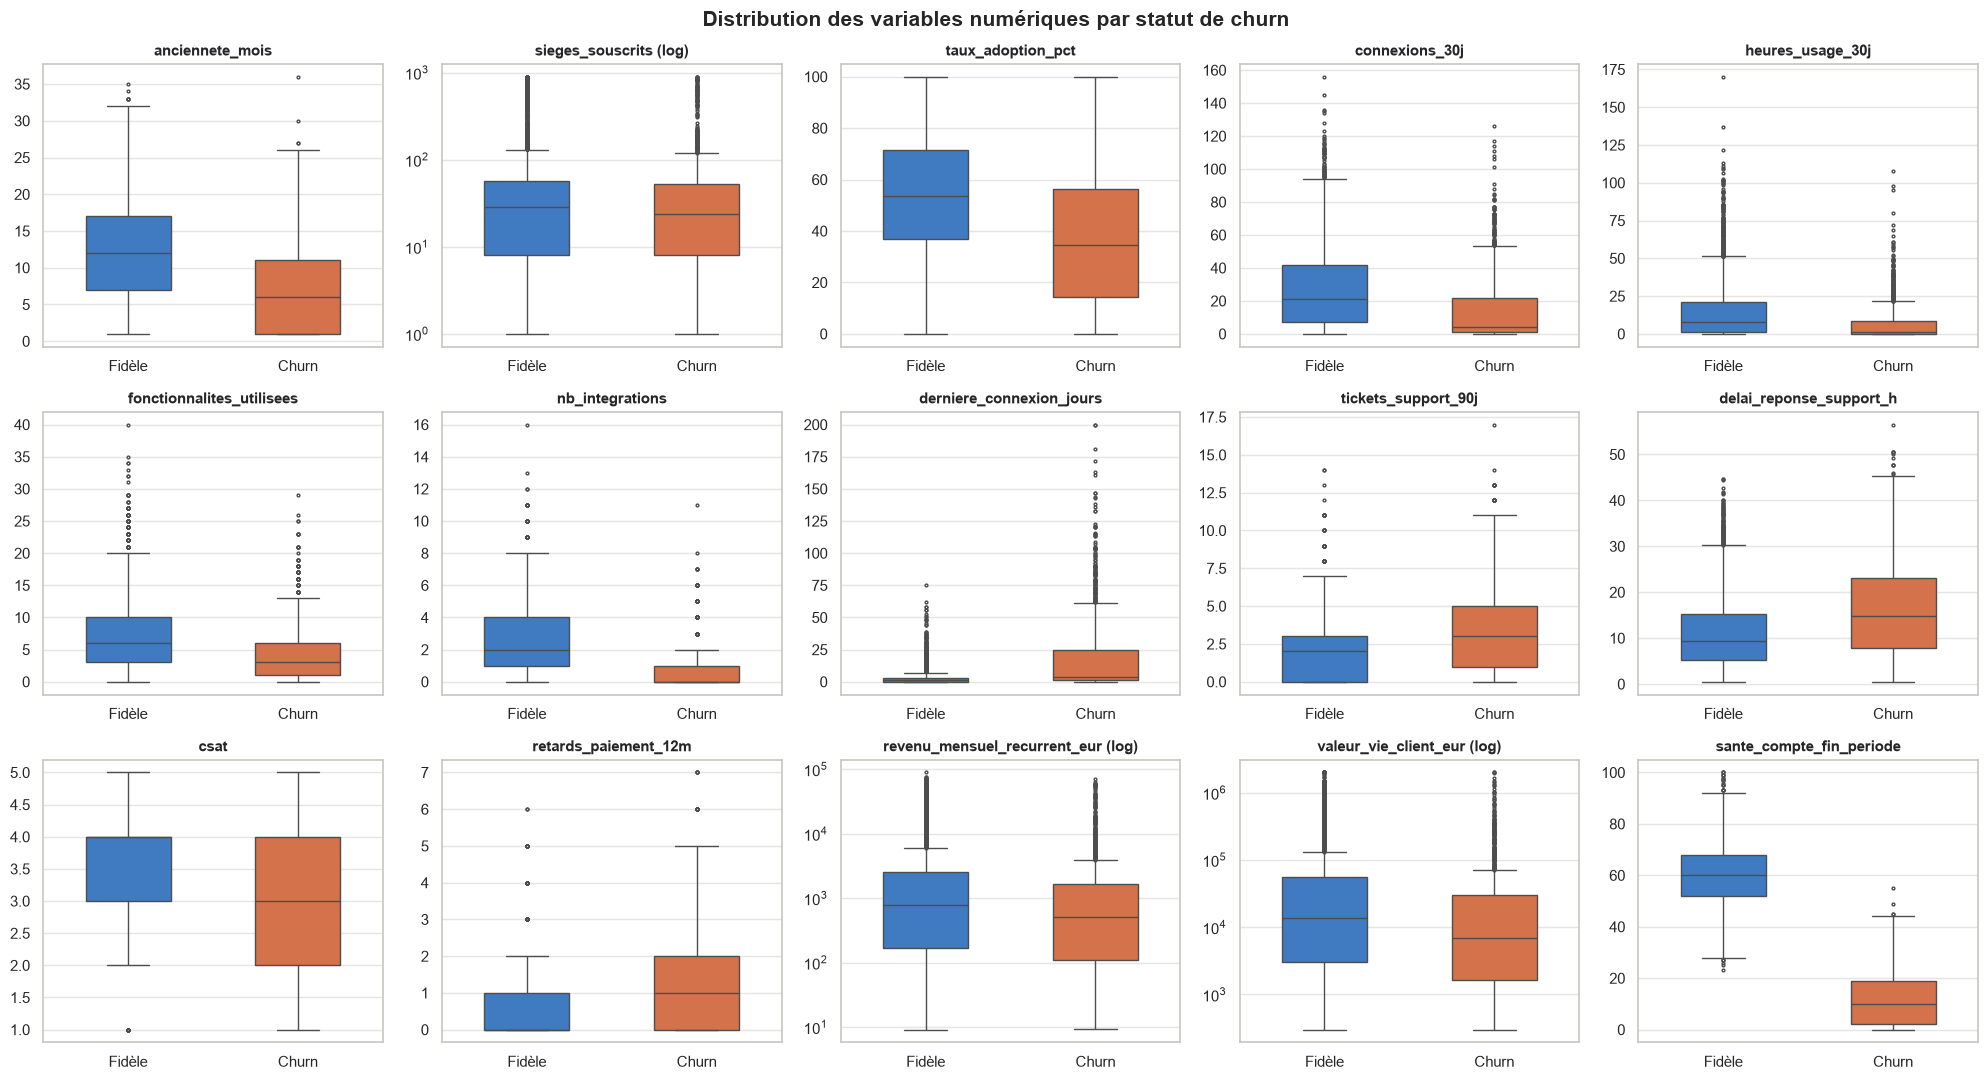

In [14]:
num_eda = ["anciennete_mois", "sieges_souscrits", "taux_adoption_pct", "connexions_30j", "heures_usage_30j",
           "fonctionnalites_utilisees", "nb_integrations", "derniere_connexion_jours", "tickets_support_90j",
           "delai_reponse_support_h", "csat", "retards_paiement_12m", "revenu_mensuel_recurrent_eur",
           "valeur_vie_client_eur", "sante_compte_fin_periode"]
log_scale = {"sieges_souscrits", "revenu_mensuel_recurrent_eur", "valeur_vie_client_eur"}

fig, axes = plt.subplots(3, 5, figsize=(20, 11))
for ax, col in zip(axes.flat, num_eda):
    sns.boxplot(data=df, x="churn", y=col, hue="churn", palette=PAL_CHURN, ax=ax, legend=False,
                width=.5, fliersize=2, linewidth=1)
    if col in log_scale:
        ax.set_yscale("log")
    ax.set_title(col + (" (log)" if col in log_scale else ""), fontsize=11)
    ax.set_xlabel(""); ax.set_ylabel(""); ax.set_xticks([0, 1], ["Fidèle", "Churn"])
fig.suptitle("Distribution des variables numériques par statut de churn", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

**Interprétation :**
- **H1 (engagement) confirmée** : les churners ont un taux d'adoption, des connexions, des heures d'usage et des fonctionnalités utilisées plus faibles, et une **dernière connexion plus ancienne**.
- **H2 (friction support) confirmée** : plus de tickets, délai de réponse plus long, CSAT plus bas chez les churners.
- **H3 (paiement) confirmée** : les retards de paiement sont nettement plus fréquents chez les churners.
- **H4 (ancrage) confirmée** : les churners sont plus récents et ont moins d'intégrations tierces.
- Les sièges et le MRR diffèrent peu : la **taille du compte** en elle-même prédit peu le churn.
- ⚠️ **`sante_compte_fin_periode` sépare presque parfaitement les deux classes** : les boîtes ne se chevauchent quasiment pas. Aucun indicateur réel ne devrait être aussi net → **suspicion forte de fuite**, analysée au §6.5.
- La CLV est plus faible chez les churners : logique, car elle intègre la durée de vie réelle → confirme qu'elle ne doit pas servir à prédire le churn.

### 6.4 Pouvoir discriminant univarié de chaque variable numérique

**Pourquoi l'AUC univariée ?** Pour classer les variables par pouvoir discriminant avec une mesure **indépendante de l'échelle** et robuste aux valeurs extrêmes (elle ne dépend que du rang). Une AUC de 0,5 = aucun pouvoir ; on affiche `|AUC − 0,5|` pour traiter de la même façon les relations positives et négatives. C'est aussi le **détecteur de fuite** le plus simple : une variable seule avec une AUC proche de 1 est suspecte.

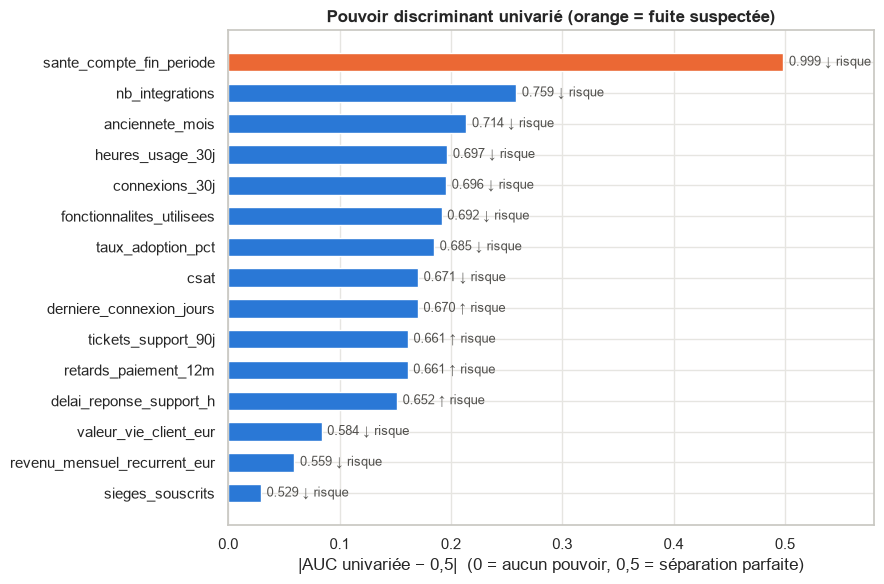

In [15]:
from sklearn.metrics import roc_auc_score

auc_uni = {}
for col in num_eda:
    m = df[col].notna()
    auc_uni[col] = roc_auc_score(df.loc[m, "churn"], df.loc[m, col])
auc_uni = pd.Series(auc_uni).to_frame("AUC")
auc_uni["force = |AUC − 0,5|"] = (auc_uni["AUC"] - 0.5).abs()
auc_uni["sens"] = np.where(auc_uni["AUC"] > 0.5, "↑ risque", "↓ risque")
auc_uni = auc_uni.sort_values("force = |AUC − 0,5|")

fig, ax = plt.subplots(figsize=(9, 6))
colors = [C_CHURN if i == "sante_compte_fin_periode" else C_OK for i in auc_uni.index]
ax.barh(auc_uni.index, auc_uni["force = |AUC − 0,5|"], color=colors, height=.6)
for i, (v, s) in enumerate(zip(auc_uni["force = |AUC − 0,5|"], auc_uni["sens"])):
    ax.text(v + .005, i, f"{v + .5:.3f} {s}", va="center", fontsize=9, color="#52514e")
ax.set_xlabel("|AUC univariée − 0,5|  (0 = aucun pouvoir, 0,5 = séparation parfaite)")
ax.set_title("Pouvoir discriminant univarié (orange = fuite suspectée)")
ax.set_xlim(0, .58); plt.tight_layout(); plt.show()

**Interprétation** : en dehors de `sante_compte_fin_periode`, **aucune variable seule ne dépasse une AUC de ~0,76** (intégrations, ancienneté, dernière connexion, retards, tickets, délai support). C'est conforme à l'énoncé (« aucune variable ne donne seule la réponse ») : la performance viendra de la **combinaison** des signaux.

### 6.5 Piège de fuite : `sante_compte_fin_periode`

**Pourquoi creuser cette variable ?** Son nom indique qu'elle est calculée **en fin de période**, c'est-à-dire *au moment ou après* l'échéance où le churn est constaté. Au moment du scoring (avant l'échéance), elle n'existe pas encore. On vérifie la relation avec le churn par tranche de score.

In [16]:
bins = [-1, 0, 20, 40, 50, 60, 80, 100]
t = df.groupby(pd.cut(df["sante_compte_fin_periode"], bins), observed=True)["churn"].agg(["size", "mean"])
t.columns = ["nb_comptes", "taux_churn"]
display(t.style.format({"taux_churn": "{:.1%}"}))
print(f"AUC de sante_compte_fin_periode seule : {auc_uni.loc['sante_compte_fin_periode', 'AUC']:.4f} "
      f"(soit {1 - auc_uni.loc['sante_compte_fin_periode', 'AUC']:.4f} en sens inverse)")

,nb_comptes,taux_churn
sante_compte_fin_periode,,
"(-1, 0]",294,100.0%
"(0, 20]",824,100.0%
"(20, 40]",450,60.9%
"(40, 50]",626,1.1%
"(50, 60]",1098,0.1%
"(60, 80]",1526,0.0%
"(80, 100]",182,0.0%


AUC de sante_compte_fin_periode seule : 0.0014 (soit 0.9986 en sens inverse)


**Conclusion — fuite de données avérée** :
- Score ≤ 20 → **100 %** de churn ; score > 50 → **~0 %** de churn. La variable **encode le résultat**.
- Son AUC seule est de **≈ 0,999** — plus élevée que n'importe quel modèle réaliste.
- Explication métier : un score de santé calculé *après* la résiliation intègre la résiliation elle-même (compte fermé = santé nulle).
- **Décision : exclusion définitive** de `sante_compte_fin_periode` des variables explicatives. Au §8, on montrera ce qui se passerait si on la gardait (AUC « parfaite » mais modèle inutilisable en production).

### 6.6 Variables catégorielles : taux de churn par modalité

**Pourquoi ?** Repérer les catégories porteuses de signal (plan, taille) et les **leurres**. Pour ne pas sur-interpréter des écarts dus au hasard, on accompagne chaque variable d'un **test du χ² d'indépendance** : une p-value élevée signifie que les écarts observés sont compatibles avec l'absence de lien.

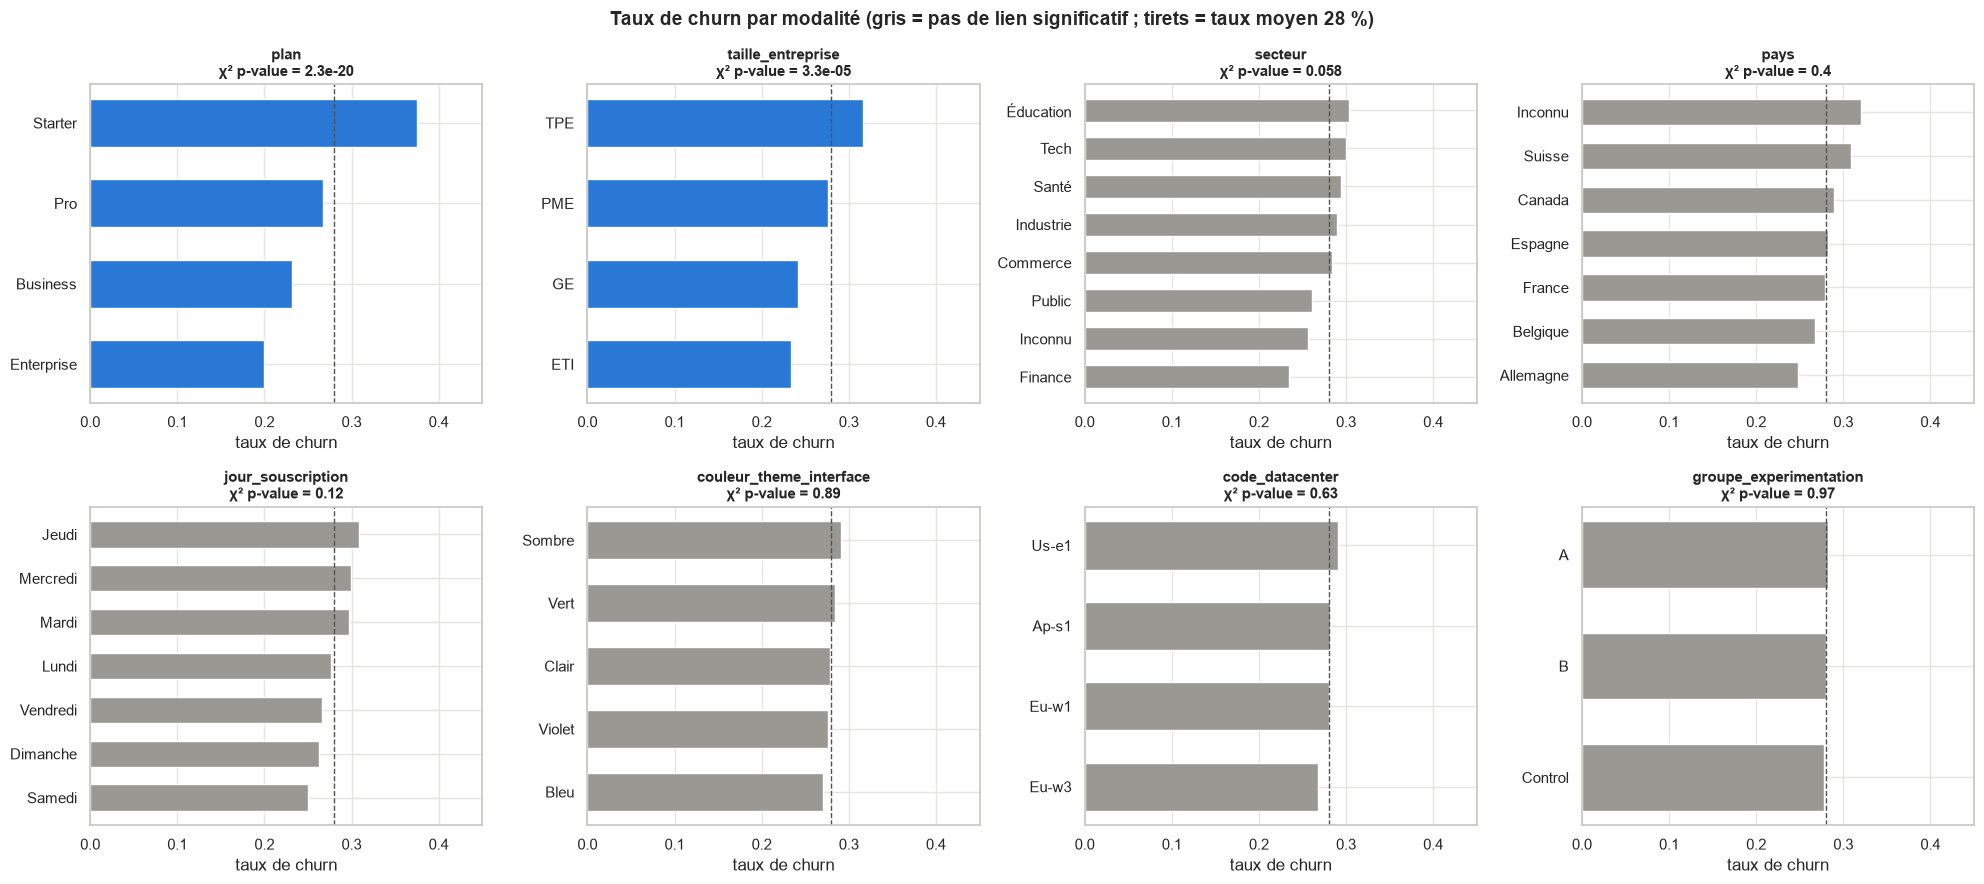

In [17]:
from scipy.stats import chi2_contingency

cat_eda = ["plan", "taille_entreprise", "secteur", "pays",
           "jour_souscription", "couleur_theme_interface", "code_datacenter", "groupe_experimentation"]
base_rate = df["churn"].mean()

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
chi2_res = {}
for ax, col in zip(axes.flat, cat_eda):
    s = df[col].fillna("Inconnu")
    p = chi2_contingency(pd.crosstab(s, df["churn"]))[1]
    chi2_res[col] = p
    rates = df.groupby(s)["churn"].mean().sort_values()
    ax.barh(rates.index, rates.values, color=C_OK if p < 0.01 else C_GREY, height=.6)
    ax.axvline(base_rate, color="#52514e", ls="--", lw=1)
    ax.set_title(f"{col}\nχ² p-value = {p:.2g}", fontsize=11)
    ax.set_xlim(0, .45); ax.set_xlabel("taux de churn")
fig.suptitle("Taux de churn par modalité (gris = pas de lien significatif ; tirets = taux moyen 28 %)",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

**Interprétation :**
- **Signal réel** : `plan` (Starter ≈ 37 % vs Enterprise ≈ 20 %) et `taille_entreprise` (TPE ≈ 32 % vs ETI/GE ≈ 23-24 %) → les petits comptes sur des offres d'entrée de gamme partent plus.
- `secteur` (p ≈ 0,06) et `pays` (p ≈ 0,40) : **pas de lien significatif** en univarié. On les **conserve néanmoins**, pour deux raisons : (1) un mécanisme métier est plausible (cycles budgétaires du secteur public, langue / fuseau du support selon le pays), contrairement aux leurres ; (2) ils sont nécessaires à l'audit d'équité (§12.3). On s'attend à ce que leur poids dans le modèle soit faible — la régularisation L2 le limitera — et ils seront réévalués à chaque ré-entraînement.
- **Leurres identifiés (H5 confirmée)** : `couleur_theme_interface` (p ≈ 0,89), `code_datacenter` (p ≈ 0,63), `groupe_experimentation` (p ≈ 0,97) — taux quasi identiques entre modalités. `jour_souscription` (p ≈ 0,12) présente de petits écarts (samedi ≈ 25 %, jeudi ≈ 31 %) mais **aucun mécanisme métier** ne peut les expliquer : c'est typiquement le genre de fluctuation qu'il ne faut pas sur-interpréter.
- *Différence entre un leurre et une variable faible* : un leurre n'a ni signal statistique **ni** mécanisme métier ; une variable faible (secteur, pays) a un mécanisme plausible mais un effet modeste sur ces données. Leur absence de pouvoir prédictif sera **confirmée en multivarié** par l'importance par permutation (§9).

#### Le commentaire CSM
**Pourquoi l'examiner à part ?** C'est un texte libre avec seulement 13 phrases types. On regarde si certaines phrases « donnent la réponse ».

In [18]:
cc = df.groupby(df["commentaire_csm"].fillna("(vide)"))["churn"].agg(["size", "mean"]).sort_values("mean")
cc.columns = ["nb_comptes", "taux_churn"]
cc.style.format({"taux_churn": "{:.1%}"})

,nb_comptes,taux_churn
commentaire_csm,,
Client très satisfait et actif.,212,1.4%
"Compte engagé, ambassadeur potentiel.",195,1.5%
RAS.,339,20.4%
Compte dans la moyenne.,296,21.6%
Suivi standard.,312,24.0%
(vide),2773,27.4%
Faible adoption des sièges.,147,41.5%
"Multiples tickets ouverts, friction élevée.",44,43.2%
Déploiement interne limité.,129,44.2%


**Interprétation** : certaines phrases sont quasi déterministes (« Usage en forte baisse ce trimestre » → 100 % de churn ; « Compte peu actif, relance nécessaire » → 97 %). Cela suggère que le commentaire est parfois rédigé **en connaissance de cause** (après des signaux de départ, voire après l'annonce). Comme on ne connaît pas sa date de rédaction, il présente un **risque de fuite partielle**. Il est de plus absent dans 55 % des cas et peut contenir des données personnelles. **Décision : exclu** du modèle. (En production, un commentaire horodaté et structuré en catégories pourrait devenir une variable légitime.)

### 6.7 Corrélations entre variables numériques

**Pourquoi ?** Détecter la **redondance** (colinéarité) : elle ne nuit pas à la performance d'un modèle d'arbres, mais rend instables les coefficients d'une régression logistique et « dilue » l'importance des variables. On utilise la corrélation de **Spearman** (sur les rangs) car beaucoup de variables sont asymétriques et les relations pas forcément linéaires.

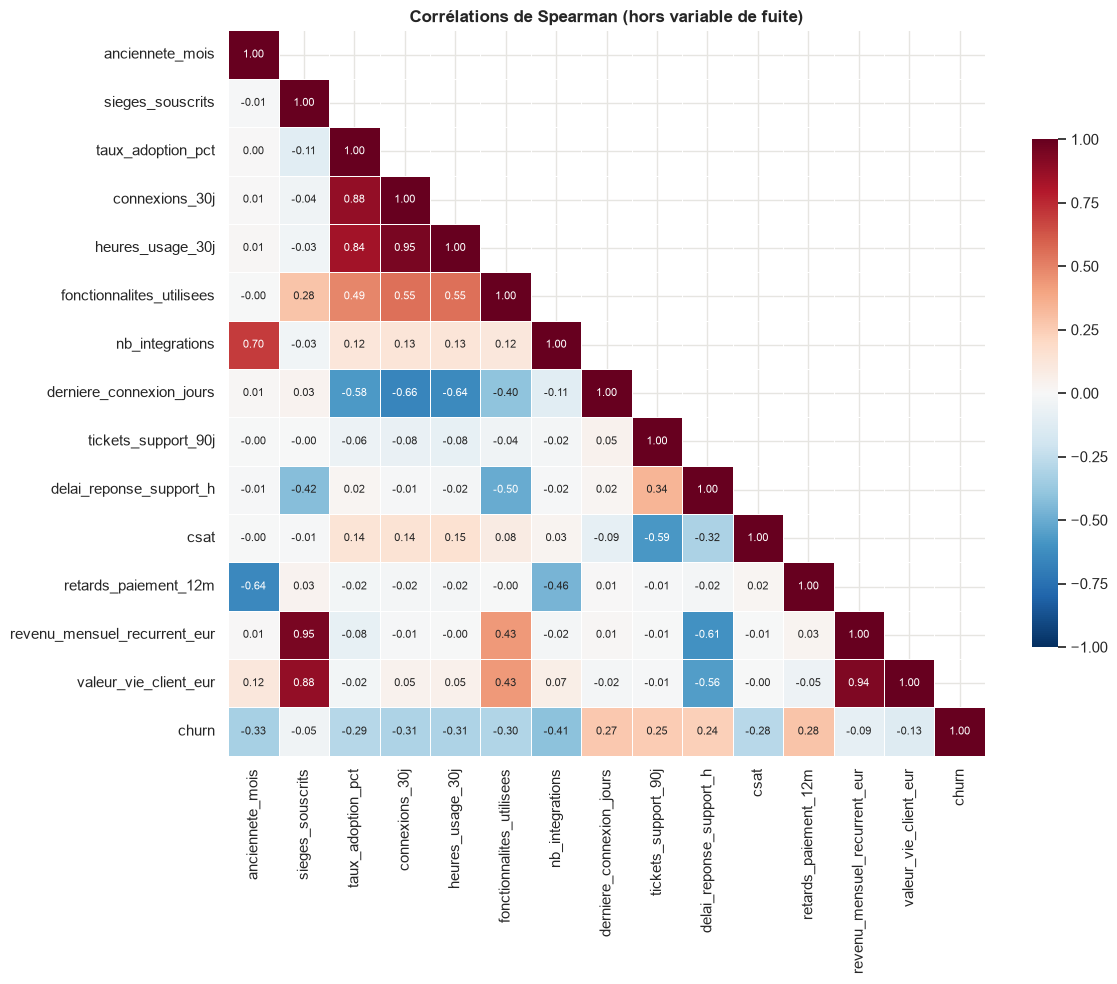

In [19]:
corr_cols = [c for c in num_eda if c not in ("sante_compte_fin_periode",)] + ["churn"]
corr = df[corr_cols].corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
            annot_kws={"size": 8}, linewidths=.5, cbar_kws={"shrink": .7}, ax=ax)
ax.set_title("Corrélations de Spearman (hors variable de fuite)")
plt.tight_layout(); plt.show()

**Interprétation :**
- **Blocs redondants** : `sieges_souscrits` / `revenu_mensuel_recurrent_eur` / `valeur_vie_client_eur` (taille du compte) ; `taux_adoption_pct` / `connexions_30j` / `heures_usage_30j` (engagement) ; `anciennete_mois` / `nb_integrations` / `retards_paiement_12m`.
- Les corrélations restent < 0,95 : pas de doublon strict à supprimer, mais on utilisera une **régularisation** (pénalité L2) dans la régression logistique pour stabiliser les coefficients, et l'**importance par permutation** sera lue par blocs plutôt que variable par variable.
- La corrélation CLV / MRR (≈ 0,8+) montre que la CLV est surtout pilotée par la taille du compte — utile pour la régression du §12.

### 📓 Journal de bord — EDA
- **Constat clé** : fuite de données avérée sur `sante_compte_fin_periode` (AUC 0,999) → exclue. Fuite partielle probable sur `commentaire_csm` → exclu.
- **Constat** : 4 leurres (thème, datacenter, groupe A/B, jour de souscription) → écartés après confirmation multivariée.
- **Constat** : manquants essentiellement aléatoires → imputation simple ; mais `taux_adoption_pct` et MRR sont **reconstituables** exactement / approximativement via d'autres colonnes et le catalogue.
- **Essai abandonné** : parsing des dates avec `format="mixed", dayfirst=True` → 18 % de dates fausses (jour/mois inversés sur le format ISO). Remplacé par un parsing format par format, validé à 100 % par `jour_souscription`.
- **Difficulté** : distinguer un vrai signal faible (secteur, pays) d'un leurre (jour de semaine) → combinaison test statistique + plausibilité métier + confirmation multivariée.

## 🟦 7. Préparation des données (nettoyage, manquants, transformations, features) — journal de bord [C3]

### 7.1 Imputations métier déterministes et feature engineering

**Principe : ne faire hors pipeline que ce qui n'apprend rien des données.** Les opérations ci-dessous sont des **règles fixes** (formules, jointure catalogue) : elles donnent le même résultat qu'on les applique sur 1 ligne ou 5 000, donc elles ne créent aucune fuite train → test. Les opérations qui *apprennent* (médianes, standardisation, encodage) sont placées dans le `Pipeline` scikit-learn (§7.3).

**Imputations métier (plus précises qu'une médiane) :**
- `taux_adoption_pct` manquant → recalculé par `actifs / sièges × 100` (relation exacte vérifiée au §6.1).
- `revenu_mensuel_recurrent_eur` manquant → estimé par `sièges × prix catalogue` (relation vérifiée à ±50 %, bien meilleure que la médiane globale sur une plage de 9 € à 89 k€).

**Nouvelles variables (et pourquoi) :**

| Variable | Formule | Justification métier |
|---|---|---|
| `ratio_fonctionnalites` | utilisées / incluses dans le plan | Mesure la *profondeur* d'usage indépendamment du plan (8 fonctionnalités utilisées = 100 % d'un Starter mais 20 % d'un Enterprise). |
| `heures_par_utilisateur` | heures 30 j / actifs | Intensité d'usage par personne (les heures totales sont mécaniquement liées au nombre d'utilisateurs). |
| `ecart_sla_support_h` | délai réponse − SLA du plan | Un délai de 10 h est excellent pour un Starter (SLA 24 h) mais une rupture de contrat pour un Enterprise (SLA 3 h). |
| `log_mrr` | log(1 + MRR) | Le MRR s'étale sur 4 ordres de grandeur ; le log rend la relation exploitable par un modèle linéaire. |
| `sieges_inactifs` | sièges − actifs | Licences payées et non utilisées = « gaspillage » perçu par le client, argument de résiliation. |

In [20]:
def add_features(d: pd.DataFrame) -> pd.DataFrame:
    # Règles déterministes : imputations métier + variables dérivées (aucun apprentissage -> pas de fuite)
    d = d.copy()
    d["taux_adoption_pct"] = d["taux_adoption_pct"].fillna(
        (d["utilisateurs_actifs"] / d["sieges_souscrits"] * 100).round(1))
    d["revenu_mensuel_recurrent_eur"] = d["revenu_mensuel_recurrent_eur"].fillna(
        d["sieges_souscrits"] * d["prix_mensuel_par_siege_eur"])
    d["ratio_fonctionnalites"] = d["fonctionnalites_utilisees"] / d["fonctionnalites_incluses"]
    d["heures_par_utilisateur"] = np.where(d["utilisateurs_actifs"] > 0,
                                           d["heures_usage_30j"] / d["utilisateurs_actifs"].clip(lower=1), 0.0)
    d.loc[d["heures_usage_30j"].isna(), "heures_par_utilisateur"] = np.nan
    d["ecart_sla_support_h"] = d["delai_reponse_support_h"] - d["sla_reponse_h"]
    d["log_mrr"] = np.log1p(d["revenu_mensuel_recurrent_eur"])
    d["sieges_inactifs"] = d["sieges_souscrits"] - d["utilisateurs_actifs"]
    return d


df = add_features(df)
print("Manquants restants après imputations métier :")
print(df[["taux_adoption_pct", "revenu_mensuel_recurrent_eur", "heures_usage_30j",
          "delai_reponse_support_h", "csat"]].isna().sum().to_string())

Manquants restants après imputations métier :
taux_adoption_pct                 0
revenu_mensuel_recurrent_eur      0
heures_usage_30j                300
delai_reponse_support_h         500
csat                            400


**Lecture** : `taux_adoption_pct` et le MRR n'ont plus aucun manquant. Les manquants restants (heures d'usage, délai support, CSAT, retards, intégrations, secteur, pays) seront imputés dans le pipeline.

### 7.2 Sélection des variables : ce qui entre dans le modèle, et pourquoi

**Pourquoi une liste explicite plutôt que « toutes les colonnes sauf la cible » ?** C'est la meilleure protection contre la fuite : toute nouvelle colonne ajoutée à la source ne rentre pas silencieusement dans le modèle. Chaque exclusion est tracée avec sa raison.

In [21]:
TARGET = "churn"
TARGET_REG = "valeur_vie_client_eur"

NUM_FEATURES = ["anciennete_mois", "sieges_souscrits", "utilisateurs_actifs", "taux_adoption_pct",
                "connexions_30j", "heures_usage_30j", "fonctionnalites_utilisees", "nb_integrations",
                "derniere_connexion_jours", "tickets_support_90j", "delai_reponse_support_h", "csat",
                "retards_paiement_12m", "log_mrr",
                "ratio_fonctionnalites", "heures_par_utilisateur", "ecart_sla_support_h", "sieges_inactifs"]
CAT_FEATURES = ["plan", "taille_entreprise", "secteur", "pays"]
DECOYS = ["couleur_theme_interface", "code_datacenter", "groupe_experimentation", "jour_souscription"]
LEAK = "sante_compte_fin_periode"

EXCLUDED = {
    "client_id": "identifiant (aucun sens prédictif) ; remplacé par un pseudonyme dans Gold",
    "sante_compte_fin_periode": "FUITE : mesurée en fin de période, après la décision",
    "commentaire_csm": "fuite partielle probable + texte libre (RGPD) + 55 % manquant",
    "valeur_vie_client_eur": "cible secondaire, connue a posteriori",
    "date_souscription": "redondante avec anciennete_mois (photo unique) ; risque d'effet calendaire",
    "fonctionnalites_total / catalogue": "déterminés par le plan (redondants) ; utilisés via les ratios",
    "revenu_mensuel_recurrent_eur": "remplacé par log_mrr",
    **{c: "LEURRE : aucun lien avec le churn (χ², permutation)" for c in DECOYS},
}
print(f"{len(NUM_FEATURES)} variables numériques + {len(CAT_FEATURES)} catégorielles retenues\n")
pd.Series(EXCLUDED, name="raison de l'exclusion").to_frame()

18 variables numériques + 4 catégorielles retenues



,raison de l'exclusion
client_id,identifiant (aucun sens prédictif) ; remplacé ...
sante_compte_fin_periode,"FUITE : mesurée en fin de période, après la dé..."
commentaire_csm,fuite partielle probable + texte libre (RGPD) ...
valeur_vie_client_eur,"cible secondaire, connue a posteriori"
date_souscription,redondante avec anciennete_mois (photo unique)...
fonctionnalites_total / catalogue,déterminés par le plan (redondants) ; utilisés...
revenu_mensuel_recurrent_eur,remplacé par log_mrr
couleur_theme_interface,"LEURRE : aucun lien avec le churn (χ², permuta..."
code_datacenter,"LEURRE : aucun lien avec le churn (χ², permuta..."
groupe_experimentation,"LEURRE : aucun lien avec le churn (χ², permuta..."


### 7.2 bis Couche Gold : table de variables prête pour le modèle

**Qu'est-ce qui entre dans Gold ?** Exactement ce dont les modèles ont besoin, et rien d'autre :
- `pseudo_id` : un **pseudonyme** du compte, à la place de `client_id` (voir ci-dessous) ;
- les **22 variables retenues** (18 numériques, dont les 5 variables dérivées, et 4 catégorielles), après imputations métier ;
- les **deux cibles** : `churn` (classification) et `valeur_vie_client_eur` (régression).

**Ce qui n'y entre pas** : la variable de fuite, les leurres, le commentaire CSM, la date de souscription, etc. (liste et raisons au §7.2). Retirer ces colonnes **physiquement** de la table d'entraînement est plus sûr qu'une simple liste de colonnes à ignorer.

**Pourquoi les imputations *apprises* (médiane) ne sont pas faites dans Gold ?** Elles dépendent des données d'entraînement : les calculer sur toute la table ferait fuiter de l'information du test vers le train. Elles restent dans le pipeline scikit-learn (§7.4). Gold ne contient que des transformations **déterministes**.

**Identifiant pseudonymisé.** Gold ne contient **que** le pseudonyme `pseudo_id` créé dans Silver (§6.1 bis), jamais `client_id`. Une personne qui n'a accès qu'à Gold ne peut pas savoir à quel compte correspond une ligne.

Un fichier `_meta.json` décrit la table : variables, cibles, exclusions justifiées, taux de churn, lien vers Silver (empreinte) et empreinte propre, enregistrée dans MLflow avec le modèle (§10.1 bis).

In [22]:
GOLD_COLS = ["pseudo_id"] + NUM_FEATURES + CAT_FEATURES + [TARGET, TARGET_REG]   # pseudo_id vient de Silver
gold_path = GOLD_DIR / "features_churn.parquet"
gold_df = df[GOLD_COLS]
gold_df.to_parquet(gold_path, index=False)

gold_meta = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "source_silver": {"file": str(silver_path), "sha256": silver_quality["sha256"]},
    "lignes": int(len(df)), "taux_churn": round(float(df[TARGET].mean()), 4),
    "identifiant": "pseudo_id (HMAC-SHA256 de client_id, clé secrète hors données)", "cibles": [TARGET, TARGET_REG],
    "variables_numeriques": NUM_FEATURES, "variables_categorielles": CAT_FEATURES,
    "exclusions": EXCLUDED,
    "sha256": sha256_file(gold_path),
}
(GOLD_DIR / "_meta.json").write_text(json.dumps(gold_meta, indent=2, ensure_ascii=False))
print(f"Gold : {gold_path} — {len(df)} lignes × {len(GOLD_COLS)} colonnes "
      f"({len(NUM_FEATURES) + len(CAT_FEATURES)} variables + pseudonyme + 2 cibles)")
print("Colonnes exclues présentes dans Gold :", [c for c in [LEAK, *DECOYS, "commentaire_csm", "client_id"] if c in GOLD_COLS] or "aucune ✅")
print("Première ligne de Gold :", gold_df["pseudo_id"].iloc[0], "(le client_id n'y figure pas)")

Gold : data/gold/features_churn.parquet — 5000 lignes × 25 colonnes (22 variables + pseudonyme + 2 cibles)
Colonnes exclues présentes dans Gold : aucune ✅
Première ligne de Gold : PSE-3a126ec3c867c05a (le client_id n'y figure pas)


### 7.3 Découpage train / test

**Choix :**
- **80 % / 20 %** : 1 000 comptes en test donnent environ 280 churners, assez pour une estimation stable des métriques ; 4 000 en train pour apprendre et faire de la validation croisée.
- **Stratifié sur `churn`** : même proportion de churners (28 %) dans les deux jeux, pour que les métriques soient comparables.
- **Les données viennent de la couche Gold** (relue depuis le fichier Parquet), comme le ferait un job d'entraînement en production.
- **Le test est mis de côté et n'est utilisé qu'une seule fois**, à la toute fin (§9.4), pour évaluer le modèle final. Toutes les comparaisons de modèles et le choix du seuil se font **en validation croisée sur le train**. Sinon, on « optimiserait sur le test » et la performance annoncée serait optimiste.
- **Pourquoi pas un découpage temporel ?** Ce serait l'idéal en production (entraîner sur le passé, tester sur le futur), mais les données sont une photographie unique à une date d'observation : il n'y a pas de dimension temporelle exploitable pour le churn. Ce point est noté comme limite (§13 : en production, on validera sur la cohorte du mois suivant).

In [23]:
from sklearn.model_selection import train_test_split

def read_gold(path):
    # Parquet relit le texte avec le type chaîne natif de pandas ; on revient au type générique + NaN
    # pour que le pipeline se comporte exactement comme pendant le développement
    g = pd.read_parquet(path)
    g[CAT_FEATURES] = g[CAT_FEATURES].astype(object).where(g[CAT_FEATURES].notna(), np.nan)
    return g


gold = read_gold(gold_path)
assert (gold["pseudo_id"].values == silver["pseudo_id"].values).all()   # jointure directe sur pseudo_id : mêmes comptes, même ordre

# Leurres et fuite : absents de Gold, rattachés depuis Silver UNIQUEMENT pour les démonstrations (§8.3, §8.4, §9.6)
DIAG_COLS = DECOYS + [LEAK]
X = gold[NUM_FEATURES + CAT_FEATURES].join(silver[DIAG_COLS])
y = gold[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(f"Train : {X_train.shape[0]} comptes, churn {y_train.mean():.1%}")
print(f"Test  : {X_test.shape[0]} comptes, churn {y_test.mean():.1%}")

Train : 4000 comptes, churn 28.0%
Test  : 1000 comptes, churn 28.0%


*(Note : les leurres et la variable de fuite ne sont **pas** dans Gold. On les rattache depuis Silver, par `pseudo_id` (mêmes comptes, même ordre, vérifié par un `assert`), **uniquement** pour démontrer leur effet au §8 et au §9.6. Chaque pipeline sélectionne explicitement ses colonnes via le `ColumnTransformer`, donc elles ne sont jamais utilisées par le modèle final.)*

### 7.4 Pipeline de prétraitement

**Pourquoi un `Pipeline` + `ColumnTransformer` ?**
1. **Anti-fuite** : l'imputeur (médiane) et le standardiseur sont ajustés **uniquement sur les plis d'entraînement** à chaque itération de validation croisée ; le test n'influence jamais ces paramètres.
2. **Reproductibilité en production** : le même objet sérialisé applique exactement les mêmes transformations aux nouvelles données.

**Choix des transformations :**
- **Numériques** : imputation par la **médiane** (robuste aux valeurs extrêmes, contrairement à la moyenne ; justifiée car les manquants sont aléatoires, §6.2), puis **standardisation** (nécessaire à la régression logistique régularisée pour que la pénalité traite toutes les variables équitablement ; sans effet sur les arbres).
- **Catégorielles** : imputation par une modalité **`Inconnu`** (plutôt que la modalité la plus fréquente, qui inventerait une information — par ex. 54 % des comptes sont en France, affecter les inconnus à la France biaiserait la variable), puis **one-hot encoding** avec `handle_unknown="ignore"` pour qu'une modalité nouvelle en production ne fasse pas planter le scoring.
- Faible cardinalité (≤ 8 modalités) → le one-hot ne crée qu'une vingtaine de colonnes, pas besoin d'encodage par la cible (qui serait lui-même une source de fuite s'il était mal fait).

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


def make_preprocessor(num_cols, cat_cols):
    num_pipe = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
    cat_pipe = Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="Inconnu")),
                         ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
    transformers = [("num", num_pipe, list(num_cols))]
    if cat_cols:
        transformers.append(("cat", cat_pipe, list(cat_cols)))
    return ColumnTransformer(transformers, verbose_feature_names_out=False)


prep = make_preprocessor(NUM_FEATURES, CAT_FEATURES).fit(X_train)
print(f"{len(prep.get_feature_names_out())} colonnes après prétraitement")

41 colonnes après prétraitement


### 📓 Journal de bord — Préparation
- **Décision** : séparer strictement les transformations *déterministes* (hors pipeline, réutilisées en production) et *apprises* (dans le pipeline) → aucune fuite train/test possible.
- **Décision** : imputations métier pour `taux_adoption_pct` (exacte) et MRR (via catalogue) ; médiane / `Inconnu` pour le reste.
- **Décision** : 5 variables créées, dont 2 grâce à la jointure catalogue (`ratio_fonctionnalites`, `ecart_sla_support_h`).
- **Décision** : 22 variables en entrée ; 11 exclusions tracées et justifiées.
- **Décision** : pseudonyme HMAC-SHA256 à clé secrète créé dès Silver (un SHA-256 simple serait réversible par force brute, les identifiants étant séquentiels) ; Gold ne contient que le pseudonyme. Silver, qui porte la correspondance, est une zone restreinte. Pas d'anonymisation complète, disproportionnée pour un usage interne et coûteuse en précision.
- **Décision** : couches Silver (nettoyée, sans imputation) et Gold (22 variables + cibles, sans fuite ni leurre) matérialisées en Parquet ; l'entraînement lit Gold. Les imputations apprises restent dans le pipeline pour éviter la fuite train → test.
- **Essai abandonné** : imputer les catégorielles par le mode (France, PME…) → abandonné car cela fabrique une information fausse pour 4-5 % des comptes.

## 🟦 8. Choix du modèle et démarche scientifique (baseline, modèles, comparaison) — journal de bord [C4]

### 8.0 Panorama des familles d'algorithmes et des solutions du marché

**Pourquoi ce panorama ?** Avant de comparer des modèles, on justifie **lesquels** comparer. Le problème est une classification binaire supervisée sur données tabulaires de taille moyenne (4 000 lignes d'entraînement, 22 variables), avec trois exigences : des probabilités fiables, une explication par compte, un coût faible.

| Famille | Exemples | Forces | Contraintes pour ce cas | Verdict |
|---|---|---|---|---|
| **Modèles linéaires** | Régression logistique régularisée | Probabilités bien calibrées, coefficients lisibles, explication par compte immédiate, très rapide et sobre | Les relations non linéaires doivent être créées à la main (log, ratios : §7.1) | ✅ Testé, **retenu** |
| **Arbres et forêts** | Arbre de décision, Random Forest | Capturent non-linéarités et interactions, peu de préparation | Probabilités moins bien calibrées, explication indirecte (permutation, SHAP), modèle plus lourd | ✅ Testé |
| **Boosting** | HistGradientBoosting, XGBoost, LightGBM | Souvent le plus performant sur données tabulaires | Nombreux hyperparamètres, recherche coûteuse en calcul, risque de sur-apprentissage sur 4 000 lignes | ✅ Testé (2 implémentations, §8.4 et §9.1 bis) |
| **SVM** | SVC à noyau RBF | Frontières non linéaires | Pas de probabilités natives (calibration supplémentaire), coût d'entraînement qui croît vite avec le volume, peu explicable | ❌ Écarté |
| **k plus proches voisins** | KNN | Simple, sans phase d'entraînement | Sensible à l'échelle et au nombre de colonnes (41 après encodage), lent à l'inférence, aucune explication par compte | ❌ Écarté |
| **Bayes naïf** | GaussianNB | Très rapide | Suppose des variables indépendantes, ce qui est faux ici (§6.7) ; probabilités mal calibrées | ❌ Écarté |
| **Réseaux de neurones** | Perceptron multicouche | Très flexibles ; référence pour l'image, le texte, le son | Sur 4 000 lignes tabulaires, rarement meilleurs que le boosting ; nombreux réglages ; boîte noire ; plus énergivores | ❌ Écarté |
| **Modèles de survie** | Cox, forêts de survie | Prédisent **quand** un client partira | Nécessitent des délais observés ; les données sont une photographie unique | Piste d'amélioration (§13.5) |
| **Non supervisé** | k-means, clustering | Segmentation des clients | Ne prédit pas la cible | Hors besoin |

**Solutions « sur l'étagère » : faut-il développer un modèle ?**

| Option | Exemples | Atouts | Limites pour ce cas |
|---|---|---|---|
| Prédiction intégrée au CRM | Salesforce Einstein Prediction Builder | Intégration native dans l'outil des CSM, sans code | Licence supplémentaire ; contrôle limité des variables (risque de fuite, comme `sante_compte_fin_periode`) et du seuil métier ; explication moins détaillée |
| Plateformes de Customer Success | Gainsight, ChurnZero, Totango | « Health scores » prêts à l'emploi, gestion des actions CSM | Scores souvent fondés sur des **règles pondérées**, proches de notre baseline métier (AUC ≈ 0,80, contre 0,89 pour le modèle) ; coût par utilisateur ; nouvel outil à adopter |
| AutoML cloud | Vertex AI AutoML, Azure Automated ML, SageMaker Autopilot | Teste automatiquement de nombreux modèles | Données envoyées chez un fournisseur cloud (localisation, transferts hors UE) ; modèles souvent complexes et peu explicables ; coût de calcul élevé pour un gain improbable (§9.1 bis : la recherche Optuna n'a pas battu la logistique) |
| **Bibliothèques open source** | scikit-learn, XGBoost, MLflow, FastAPI | Gratuites, standard, maîtrise complète | Demandent des compétences internes |

**Conclusion** : on utilise des **composants sur l'étagère** (bibliothèques open source), mais pas de **solution clé en main**. Les raisons : le volume est faible et un modèle simple est le plus performant ; il faut un contrôle complet des variables (fuite, leurres), du seuil métier et des explications ; les données restent dans le SI de l'entreprise ; le coût est quasi nul. **À réévaluer** si l'entreprise utilise déjà Gainsight ou Einstein : leur score serait alors évalué comme challenger, avec le même protocole.

### 8.1 Protocole de comparaison

**Métriques retenues :**
- **ROC-AUC** (exigée) : probabilité que le modèle classe un churner au-dessus d'un fidèle. Indépendante du seuil, elle mesure la qualité du **classement**, ce dont les CSM ont besoin pour prioriser.
- **PR-AUC (Average Precision)** : résume le compromis précision / rappel. Plus exigeante que l'AUC en classe minoritaire, et plus proche de l'usage (« parmi les comptes que je contacte, combien partent vraiment ? »). Sa valeur de référence est le taux de churn (0,28), pas 0,5.
- **Brier score** (secondaire) : qualité des *probabilités* (calibration). Utile car on communiquera des probabilités aux CSM.

**Traçabilité** : la fonction `evaluate` enregistre chaque évaluation comme un run MLflow (paramètres, liste des variables, métriques moyennes et écarts-types, temps d'entraînement). On pourra ainsi retrouver et comparer toutes les expériences, y compris celles qui ont été écartées.

**Validation croisée stratifiée à 5 plis** sur le train : chaque modèle est entraîné 5 fois sur 80 % du train et évalué sur les 20 % restants ; on rapporte la **moyenne et l'écart-type**. L'écart-type permet de juger si une différence entre deux modèles est réelle ou due au hasard du découpage.

**Candidats (au moins deux familles, exigence de l'énoncé) :**

| Modèle | Famille | Pourquoi le tester |
|---|---|---|
| `DummyClassifier` | Baseline | Plancher : prédit le taux moyen pour tous. Tout modèle doit faire mieux. |
| Règle métier simple | Baseline « métier » | Ce que ferait un CSM sans IA : score = retards + tickets + inactivité. Mesure la valeur ajoutée réelle du ML. |
| Régression logistique | Linéaire | Rapide, **explicable** (coefficients), probabilités bien calibrées. |
| Random Forest | Ensemble d'arbres (bagging) | Capte les non-linéarités et interactions, robuste, peu de réglages. |
| HistGradientBoosting | Ensemble d'arbres (boosting) | Souvent le plus performant sur données tabulaires ; gère nativement les NaN. |

In [25]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = {"roc_auc": "roc_auc", "pr_auc": "average_precision", "brier": "neg_brier_score"}


def evaluate(name, estimator, num_cols=NUM_FEATURES, cat_cols=CAT_FEATURES, phase="comparaison"):
    pipe = Pipeline([("prep", make_preprocessor(num_cols, cat_cols)), ("model", estimator)])
    r = cross_validate(pipe, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=-1)
    res = {"modèle": name,
           "ROC-AUC": r["test_roc_auc"].mean(), "± AUC": r["test_roc_auc"].std(),
           "PR-AUC": r["test_pr_auc"].mean(), "± PR": r["test_pr_auc"].std(),
           "Brier": -r["test_brier"].mean()}
    # Traçabilité : un run MLflow par évaluation
    log_run(name, tags={"phase": phase, "algorithme": type(estimator).__name__},
            params={"n_features_num": len(num_cols), "n_features_cat": len(cat_cols),
                    "features": ", ".join(list(num_cols) + list(cat_cols)),
                    **{k: v for k, v in estimator.get_params().items() if v is not None}},
            metrics={"cv_roc_auc_mean": res["ROC-AUC"], "cv_roc_auc_std": res["± AUC"],
                     "cv_pr_auc_mean": res["PR-AUC"], "cv_pr_auc_std": res["± PR"], "cv_brier": res["Brier"],
                     "fit_time_s": r["fit_time"].sum()})
    return res

### 8.2 Baselines

**Baseline « métier »** : on construit une règle que le métier pourrait appliquer sans modèle — additionner des signaux d'alerte standardisés (retards de paiement, tickets, jours depuis la dernière connexion, moins le CSAT). On l'évalue directement par son AUC sur les plis de validation (pas d'apprentissage). Si le modèle ML ne la bat pas nettement, il ne vaut pas le coût de son industrialisation.

In [26]:
def business_rule_score(d):
    # Somme de signaux d'alerte standardisés par rang (0-1) : ce qu'un CSM ferait « à la main »
    r = lambda s: s.rank(pct=True).fillna(0.5)
    return r(d["retards_paiement_12m"]) + r(d["tickets_support_90j"]) + r(d["derniere_connexion_jours"]) - r(d["csat"])

from sklearn.metrics import average_precision_score, brier_score_loss
rule_auc, rule_pr = [], []
for _, val_idx in CV.split(X_train, y_train):
    s = business_rule_score(X_train.iloc[val_idx])
    rule_auc.append(roc_auc_score(y_train.iloc[val_idx], s))
    rule_pr.append(average_precision_score(y_train.iloc[val_idx], s))

log_run("Baseline règle métier", tags={"phase": "baseline", "algorithme": "règle"},
        metrics={"cv_roc_auc_mean": np.mean(rule_auc), "cv_roc_auc_std": np.std(rule_auc),
                 "cv_pr_auc_mean": np.mean(rule_pr), "cv_pr_auc_std": np.std(rule_pr)})
results = [evaluate("Baseline naïve (Dummy)", DummyClassifier(strategy="prior"), phase="baseline"),
           {"modèle": "Baseline règle métier", "ROC-AUC": np.mean(rule_auc), "± AUC": np.std(rule_auc),
            "PR-AUC": np.mean(rule_pr), "± PR": np.std(rule_pr), "Brier": np.nan}]
pd.DataFrame(results).set_index("modèle").round(3)

,ROC-AUC,± AUC,PR-AUC,± PR,Brier
modèle,,,,,
Baseline naïve (Dummy),0.500,0.000,0.280,0.000,0.202
Baseline règle métier,0.797,0.014,0.627,0.024,NaN


**Lecture** : la baseline naïve a une AUC de 0,50 et une PR-AUC de 0,28 (= taux de churn), comme attendu. La règle métier fait déjà **nettement mieux** (AUC ≈ 0,80, PR-AUC ≈ 0,63) : la barre à franchir pour le ML est donc cette règle, pas le hasard.

### 8.3 Démonstration du piège de fuite

**Pourquoi le montrer ?** L'énoncé demande de repérer la fuite ; la démonstration chiffrée est l'argument le plus convaincant. On entraîne la même régression logistique (a) avec la **seule** variable `sante_compte_fin_periode`, (b) avec toutes les variables légitimes **plus** celle-ci.

In [27]:
leak_results = [
    evaluate("⚠️ Logistique — sante_fin_periode SEULE", LogisticRegression(max_iter=2000), [LEAK], [], phase="demo_fuite"),
    evaluate("⚠️ Logistique — variables + sante_fin_periode", LogisticRegression(max_iter=2000),
             NUM_FEATURES + [LEAK], CAT_FEATURES, phase="demo_fuite"),
]
pd.DataFrame(leak_results).set_index("modèle").round(4)

,ROC-AUC,± AUC,PR-AUC,± PR,Brier
modèle,,,,,
⚠️ Logistique — sante_fin_periode SEULE,0.9985,0.0006,0.9966,0.0010,0.0111
⚠️ Logistique — variables + sante_fin_periode,0.9994,0.0005,0.9989,0.0008,0.0057


**Lecture** : avec la variable de fuite, l'AUC atteint **≈ 0,999** — une seule variable fait mieux que tout modèle construit à partir de 22 signaux réels. C'est exactement le symptôme décrit dans l'énoncé : **une performance quasi parfaite signale une fuite**. Un tel modèle serait inutilisable en production, car au moment du scoring (avant l'échéance) le score de santé de *fin* de période n'existe pas. Cette variable est définitivement exclue.

### 8.4 Comparaison des familles de modèles (sans fuite)

**Réglages initiaux (avant optimisation) :** hyperparamètres raisonnables par défaut, pour une comparaison équitable :
- Logistique : `max_iter=2000` pour garantir la convergence.
- Random Forest : 400 arbres, `min_samples_leaf=5` pour limiter le sur-apprentissage sur 3 200 lignes par pli.
- HistGradientBoosting : paramètres par défaut de scikit-learn.

On teste aussi la logistique **avec les leurres** pour mesurer leur effet. Le bloc est mesuré par CodeCarbon (`carbon_phase`) ; chaque modèle est tracé dans MLflow par `evaluate`.

In [28]:
with carbon_phase("Comparaison des modèles (4 modèles × CV 5 plis)"):
    model_results = [
        evaluate("Régression logistique", LogisticRegression(max_iter=2000)),
        evaluate("Régression logistique + leurres", LogisticRegression(max_iter=2000),
                 NUM_FEATURES, CAT_FEATURES + DECOYS),
        evaluate("Random Forest", RandomForestClassifier(n_estimators=400, min_samples_leaf=5,
                                                         n_jobs=-1, random_state=RANDOM_STATE)),
        evaluate("HistGradientBoosting", HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]
comparison = pd.DataFrame(results + model_results).set_index("modèle")
comparison.round(3)

,ROC-AUC,± AUC,PR-AUC,± PR,Brier
modèle,,,,,
Baseline naïve (Dummy),0.500,0.000,0.280,0.000,0.202
Baseline règle métier,0.797,0.014,0.627,0.024,NaN
Régression logistique,0.891,0.010,0.792,0.021,0.114
Régression logistique + leurres,0.889,0.010,0.789,0.021,0.115
Random Forest,0.881,0.010,0.770,0.018,0.121
HistGradientBoosting,0.878,0.007,0.765,0.016,0.123


**Visualisation de la comparaison.** On trace les moyennes CV **avec leur écart-type** en barres d'erreur : c'est ce qui permet de juger si un écart entre deux modèles dépasse le bruit du découpage. Les lignes pointillées rappellent les références (hasard pour l'AUC, taux de churn pour la PR-AUC). La baseline naïve est retirée du graphique car elle écraserait l'échelle ; la règle métier est en gris pour la distinguer des modèles ML.

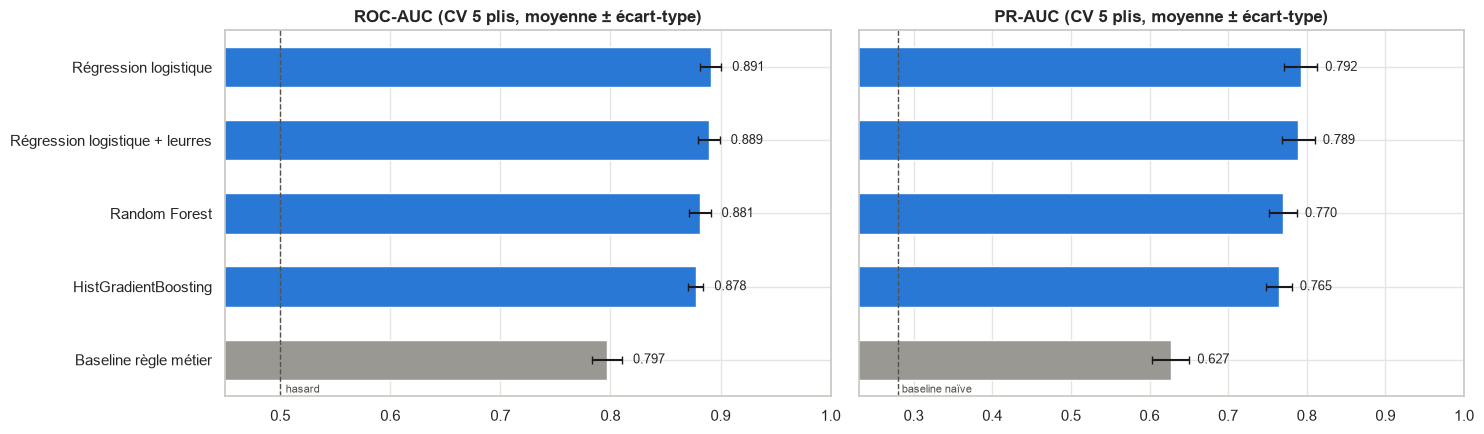

In [29]:
plot_df = comparison.drop(index=["Baseline naïve (Dummy)"]).sort_values("ROC-AUC")
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharey=True)
for ax, m, err, ref in [(axes[0], "ROC-AUC", "± AUC", 0.5), (axes[1], "PR-AUC", "± PR", y_train.mean())]:
    colors = [C_GREY if "règle" in i else C_OK for i in plot_df.index]
    ax.barh(plot_df.index, plot_df[m], xerr=plot_df[err], color=colors, height=.55, capsize=3)
    ax.axvline(ref, color="#52514e", ls="--", lw=1)
    for i, (v, e) in enumerate(zip(plot_df[m], plot_df[err])):
        ax.text(v + e + .01, i, f"{v:.3f}", va="center", fontsize=9)
    ax.set_xlim(ref - .05 if m == "PR-AUC" else .45, 1); ax.set_title(f"{m} (CV 5 plis, moyenne ± écart-type)")
axes[1].text(y_train.mean() + .005, -.45, "baseline naïve", fontsize=8, color="#52514e")
axes[0].text(.505, -.45, "hasard", fontsize=8, color="#52514e")
plt.tight_layout(); plt.show()

**Interprétation :**
- Les trois familles battent **largement** les deux baselines : environ +0,09 d'AUC et +0,16 de PR-AUC par rapport à la règle métier → le ML apporte une vraie valeur.
- **La régression logistique est la meilleure** (AUC ≈ 0,891, PR-AUC ≈ 0,79), devant la Random Forest (0,881) et le boosting (0,878). Les écarts sont de l'ordre d'un écart-type : les modèles d'arbres **n'apportent rien** en échange de leur complexité. Explication : les relations churn ↔ variables sont essentiellement **monotones et additives** (plus de retards → plus de risque, etc.) ; un modèle linéaire les capte parfaitement, et les arbres paient leur flexibilité en variance.
- **Ajouter les leurres dégrade légèrement** la logistique (bruit supplémentaire) → confirmation qu'ils doivent être exclus.
- Le Brier score le plus bas est aussi celui de la logistique → ses **probabilités sont les plus fiables**, important pour les communiquer aux CSM.

**Décision : modèle candidat = régression logistique**, avec le boosting comme challenger optimisé au §9 pour s'assurer que l'écart ne vient pas d'un mauvais réglage.

### 8.5 Robustesse : et si une source de données manquait ?

**Pourquoi ce test ?** En production, les variables viennent de 4 systèmes différents (§3.2). Si l'un d'eux tombe en panne ou n'est pas encore raccordé, faut-il arrêter le scoring ? Pour en décider **sur des chiffres**, on ré-évalue la régression logistique (même protocole : validation croisée 5 plis sur le train) en retirant **toutes les variables d'une source à la fois**. Les variables dérivées sont retirées avec leur source (par ex. `ecart_sla_support_h` avec le support).

Le contrat et le catalogue ne sont pas testés : ils forment le socle bloquant (§3.4), sans eux aucun score n'est produit.


In [30]:
SOURCES = {
    "Usage produit (logs)": ["utilisateurs_actifs", "taux_adoption_pct", "connexions_30j", "heures_usage_30j",
                             "fonctionnalites_utilisees", "nb_integrations", "derniere_connexion_jours",
                             "ratio_fonctionnalites", "heures_par_utilisateur", "sieges_inactifs"],
    "Support (ticketing)": ["tickets_support_90j", "delai_reponse_support_h", "csat", "ecart_sla_support_h"],
    "Paiement (facturation)": ["retards_paiement_12m"],
    "Profil de l'entreprise (CRM)": ["secteur", "pays", "taille_entreprise"],
}

full = comparison.loc["Régression logistique"]
robust = [{"source indisponible": "Aucune (modèle complet)", "variables retirées": 0,
           "ROC-AUC": full["ROC-AUC"], "PR-AUC": full["PR-AUC"]}]
for source, cols in SOURCES.items():
    r = evaluate(f"Logistique sans {source}", LogisticRegression(max_iter=2000),
                 [c for c in NUM_FEATURES if c not in cols], [c for c in CAT_FEATURES if c not in cols],
                 phase="robustesse_source")
    robust.append({"source indisponible": source, "variables retirées": len(cols),
                   "ROC-AUC": r["ROC-AUC"], "PR-AUC": r["PR-AUC"]})

robust = pd.DataFrame(robust).set_index("source indisponible")
robust["Δ AUC"] = robust["ROC-AUC"] - full["ROC-AUC"]
robust["bat la règle métier ?"] = np.where(robust["ROC-AUC"] > np.mean(rule_auc), "oui", "non")
robust.round(3)

,variables retirées,ROC-AUC,PR-AUC,Δ AUC,bat la règle métier ?
source indisponible,,,,,
Aucune (modèle complet),0,0.891,0.792,0.000,oui
Usage produit (logs),10,0.806,0.648,-0.085,oui
Support (ticketing),4,0.843,0.714,-0.048,oui
Paiement (facturation),1,0.884,0.780,-0.007,oui
Profil de l'entreprise (CRM),3,0.892,0.794,0.001,oui


**Interprétation :**
- **L'usage produit est la source la plus critique** : sans elle, l'AUC perd 0,085. C'est cohérent avec l'EDA (§6.4) : la dernière connexion, les intégrations et l'adoption font partie des signaux les plus forts. Le modèle bat encore de justesse la règle métier, qui elle-même a besoin de la dernière connexion, donc de cette source.
- **Le support** est la deuxième source importante (−0,048).
- **Le paiement** ne pèse presque rien une fois les autres signaux présents (−0,007), bien que les retards soient discriminants seuls : leur information recoupe en partie celle de l'usage et du support.
- **Le profil de l'entreprise (secteur, pays, taille) n'apporte rien** (+0,001, dans le bruit). C'est une information utile pour la conformité : ces variables pourraient être **retirées du modèle** au nom de la minimisation des données (§4.3), sans perte de performance. Elles restent utiles pour **auditer l'équité par segment** (§12.3), ce qui ne nécessite pas de les donner au modèle. Piste notée au §13.
- Ces chiffres fondent le **plan de repli** décrit au §3.4.

### 8.6 Essais de feature engineering : classes ou valeurs brutes ? jeu réduit ?

**Pourquoi ces essais ?** Le §7.1 a créé des variables dérivées. Deux autres pistes classiques restent à tester plutôt qu'à supposer :
1. **Passer certaines variables en classes** (discrétisation) : remplacer l'ancienneté, la dernière connexion ou le nombre de tickets par des tranches (5 classes de même effectif). Un modèle linéaire peut ainsi capter des **effets de seuil** (par ex. « au-delà de 30 jours sans connexion, le risque bondit ») au lieu d'une pente unique. Le prix à payer : plus de colonnes et une perte d'information à l'intérieur de chaque classe.
2. **Réduire le jeu de variables** :
   - `sieges_inactifs` vaut **exactement** `sieges_souscrits − utilisateurs_actifs` : c'est une combinaison linéaire de deux autres variables, donc redondante pour un modèle linéaire. Elle avait été créée pour la lisibilité métier des facteurs explicatifs ;
   - le profil de l'entreprise (secteur, pays, taille) n'apporte rien selon le §8.5.

Même protocole que le §8.4 : régression logistique, validation croisée 5 plis sur le train, chaque essai tracé dans MLflow. **Règle de décision fixée avant l'essai** : on ne change le modèle que si le gain dépasse le bruit (l'écart-type entre plis).

In [31]:
from sklearn.preprocessing import KBinsDiscretizer

BINNED = ["anciennete_mois", "derniere_connexion_jours", "tickets_support_90j"]
REDUNDANT = ["sieges_inactifs"]                      # = sieges_souscrits − utilisateurs_actifs (combinaison exacte)
FIRMO = ["secteur", "pays", "taille_entreprise"]
NUM_REDUCED = [c for c in NUM_FEATURES if c not in REDUNDANT]
CAT_REDUCED = [c for c in CAT_FEATURES if c not in FIRMO]


def make_preprocessor_binned(num_cols, cat_cols, binned):
    # Variables de `binned` découpées en 5 classes de même effectif (one-hot), les autres inchangées
    base = make_preprocessor([c for c in num_cols if c not in binned], cat_cols)
    bins = Pipeline([("impute", SimpleImputer(strategy="median")),
                     ("bins", KBinsDiscretizer(n_bins=5, encode="onehot-dense", strategy="quantile"))])
    return ColumnTransformer(base.transformers + [("bin", bins, list(binned))], verbose_feature_names_out=False)


variants = {
    "Actuel (22 variables, valeurs brutes)": make_preprocessor(NUM_FEATURES, CAT_FEATURES),
    "3 variables en classes": make_preprocessor_binned(NUM_FEATURES, CAT_FEATURES, BINNED),
    "Toutes les numériques en classes": make_preprocessor_binned(NUM_FEATURES, CAT_FEATURES, NUM_FEATURES),
    f"Jeu réduit ({len(NUM_REDUCED) + len(CAT_REDUCED)} variables)": make_preprocessor(NUM_REDUCED, CAT_REDUCED),
}
fe_rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")                   # avertissements de KBinsDiscretizer sur les classes de bord
    for name, prep_v in variants.items():
        pipe = Pipeline([("prep", prep_v), ("model", LogisticRegression(max_iter=2000))])
        r = cross_validate(pipe, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=-1)
        n_cols = prep_v.fit(X_train).transform(X_train.head()).shape[1]
        fe_rows.append({"variante": name, "colonnes en entrée": n_cols,
                        "ROC-AUC": r["test_roc_auc"].mean(), "± AUC": r["test_roc_auc"].std(),
                        "PR-AUC": r["test_pr_auc"].mean(), "Brier": -r["test_brier"].mean()})
        log_run(f"Feature engineering — {name}", tags={"phase": "feature_engineering"},
                params={"n_colonnes": n_cols},
                metrics={"cv_roc_auc_mean": fe_rows[-1]["ROC-AUC"], "cv_pr_auc_mean": fe_rows[-1]["PR-AUC"]})

fe = pd.DataFrame(fe_rows).set_index("variante")
fe["Δ AUC"] = fe["ROC-AUC"] - fe["ROC-AUC"].iloc[0]
fe.round(4)

,colonnes en entrée,ROC-AUC,± AUC,PR-AUC,Brier,Δ AUC
variante,,,,,,
"Actuel (22 variables, valeurs brutes)",41,0.8910,0.0096,0.7923,0.1139,0.0000
3 variables en classes,51,0.8799,0.0103,0.7587,0.1212,-0.0111
Toutes les numériques en classes,105,0.8747,0.0095,0.7547,0.1236,-0.0163
Jeu réduit (18 variables),21,0.8920,0.0084,0.7942,0.1133,0.0010


**Interprétation :**
- **Passer en classes dégrade le modèle** : −0,011 d'AUC avec 3 variables, −0,016 avec toutes, au-delà du bruit (± 0,01), avec 10 à 64 colonnes de plus. Les relations sont **monotones et régulières** (§6.3) : une pente unique les décrit mieux que des paliers, et le découpage fait perdre l'information à l'intérieur de chaque classe. La discrétisation serait utile face à des effets de seuil marqués ou à des valeurs extrêmes, ce qui n'est pas le cas ici (le MRR, très étalé, est déjà traité par le log). **Essai abandonné.**
- **Le jeu réduit est équivalent** au modèle complet (+0,001 d'AUC, dans le bruit) avec **deux fois moins de colonnes** (21 au lieu de 41). Retirer la variable redondante et le profil de l'entreprise ne coûte rien.
- **Décision** : selon la règle fixée avant l'essai, il n'y a **pas de gain net**, donc le modèle à 22 variables reste celui qui est finalisé au §9. Le jeu réduit est plus simple et plus sobre en données : il est ré-entraîné comme **challenger** au §13.2 bis, ce qui illustre le cycle de promotion. `sieges_inactifs` est conservée dans le modèle actuel pour la lisibilité des facteurs (« licences inutilisées »), la régularisation L2 gérant la redondance.

### 📓 Journal de bord — Choix du modèle
- **Décision** : ROC-AUC (classement) + PR-AUC (classe minoritaire) + Brier (calibration) ; l'accuracy est écartée car trompeuse à 28 % de positifs.
- **Décision** : baseline métier ajoutée en plus de la baseline naïve pour mesurer la valeur *réelle* du ML.
- **Constat** : fuite démontrée (AUC 0,999) → exclue.
- **Constat** : la logistique égale ou bat les modèles d'arbres → on privilégie la simplicité et l'explicabilité (principe de parcimonie).
- **Essai abandonné** : sur-échantillonnage SMOTE — non retenu : le déséquilibre est modéré, l'AUC n'est pas sensible au déséquilibre, et le seuil est ajusté explicitement au §9 ; SMOTE aurait en plus dégradé la calibration des probabilités.
- **Décision** : robustesse mesurée source par source (§8.5) ; elle fonde le plan de repli du §3.4.
- **Essai abandonné** : discrétisation en classes (§8.6), qui dégrade le modèle.
- **Constat** : jeu réduit à 18 variables équivalent au modèle complet (§8.6) ; testé comme challenger au §13.2 bis plutôt que de remplacer le modèle sans gain.


## 🟦 9. Entraînement, validation et ajustement (sélection du modèle final) — journal de bord [C5]

### 9.1 Optimisation des hyperparamètres

**Choix de la méthode : `GridSearchCV`** (recherche exhaustive) car l'espace est petit ; pour le boosting, grille resserrée sur les paramètres les plus influents. L'optimisation se fait **en validation croisée sur le train uniquement**, critère = ROC-AUC (qualité du classement, indépendante du seuil — le seuil est choisi séparément en §9.3).

**Hyperparamètres de la logistique :**
- `C` = inverse de la force de régularisation L2. Petit `C` → coefficients plus contraints (moins de sur-apprentissage, plus stable face aux variables corrélées vues au §6.7). On explore sur une échelle logarithmique.
- `class_weight` : `None` vs `"balanced"` (sur-pondère les churners). Testé plutôt que supposé.

**Hyperparamètres du boosting (challenger)** : taux d'apprentissage, profondeur, nombre d'itérations, régularisation L2 — un boosting plus lent et moins profond est généralement plus robuste sur 4 000 lignes.

**Suivi** : chaque recherche est mesurée séparément par CodeCarbon, pour comparer le coût énergétique des deux familles (§12.5). Le meilleur réglage et le tableau complet des combinaisons testées sont enregistrés dans MLflow.

In [32]:
from sklearn.model_selection import GridSearchCV

logit_pipe = Pipeline([("prep", make_preprocessor(NUM_FEATURES, CAT_FEATURES)),
                       ("model", LogisticRegression(max_iter=5000))])
logit_grid = GridSearchCV(logit_pipe,
                          {"model__C": [0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10],
                           "model__class_weight": [None, "balanced"]},
                          cv=CV, scoring="roc_auc", n_jobs=-1)
with carbon_phase("Optimisation — régression logistique (16 combinaisons × 5 plis)"):
    logit_grid.fit(X_train, y_train)

hgb_pipe = Pipeline([("prep", make_preprocessor(NUM_FEATURES, CAT_FEATURES)),
                     ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))])
hgb_grid = GridSearchCV(hgb_pipe,
                        {"model__learning_rate": [0.03, 0.1],
                         "model__max_depth": [2, 3, None],
                         "model__max_iter": [150, 300],
                         "model__l2_regularization": [0.0, 1.0]},
                        cv=CV, scoring="roc_auc", n_jobs=-1)
with carbon_phase("Optimisation — gradient boosting (24 combinaisons × 5 plis)"):
    hgb_grid.fit(X_train, y_train)

# Traçabilité MLflow : meilleur réglage + tableau complet de la recherche (artefact CSV)
for label, grid in [("logistique", logit_grid), ("gradient_boosting", hgb_grid)]:
    csv = MODEL_DIR / f"gridsearch_{label}.csv"
    pd.DataFrame(grid.cv_results_).drop(columns="params").to_csv(csv, index=False)
    log_run(f"GridSearch — {label}", tags={"phase": "optimisation"},
            params={k.split("__")[1]: v for k, v in grid.best_params_.items()},
            metrics={"cv_roc_auc_best": grid.best_score_,
                     "n_combinaisons": len(grid.cv_results_["params"])}, artifacts=[csv])

print(f"Logistique  — meilleurs paramètres : {logit_grid.best_params_}  | AUC CV = {logit_grid.best_score_:.4f}")
print(f"Boosting    — meilleurs paramètres : {hgb_grid.best_params_}  | AUC CV = {hgb_grid.best_score_:.4f}")

Logistique  — meilleurs paramètres : {'model__C': 0.03, 'model__class_weight': None}  | AUC CV = 0.8922
Boosting    — meilleurs paramètres : {'model__l2_regularization': 1.0, 'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__max_iter': 300}  | AUC CV = 0.8859


**Lecture** :
- Pour la logistique, une régularisation **assez forte** est retenue (petit `C`) : cohérent avec les blocs de variables corrélées. `class_weight` n'améliore pas l'AUC (attendu : l'AUC ne dépend que du classement) — on garde `None`, qui conserve des probabilités **calibrées** ; la gestion du déséquilibre passe par le seuil.
- Le boosting optimisé progresse (arbres peu profonds, apprentissage lent), mais **reste sous la logistique** (0,886 contre 0,892). Reste à vérifier que ce n'est pas dû à une grille trop étroite : c'est l'objet du §9.1 bis.

### 9.1 bis Challenger XGBoost optimisé avec Optuna

**Pourquoi ce challenger ?** La grille du boosting scikit-learn ne testait que 24 combinaisons de 4 paramètres. On pourrait objecter qu'un boosting **mieux réglé** battrait la logistique. Pour lever ce doute, on optimise **XGBoost** (la bibliothèque de boosting la plus utilisée sur données tabulaires) avec **Optuna**, sur un espace bien plus large.

**Pourquoi Optuna plutôt qu'une grille ?**
- XGBoost a une dizaine d'hyperparamètres, dont plusieurs **continus** (taux d'apprentissage, régularisations). Une grille exhaustive sur 9 paramètres exploserait (plus de 10 000 combinaisons même avec 3 valeurs par paramètre).
- Optuna utilise l'échantillonneur **TPE** (*Tree-structured Parzen Estimator*) : il apprend des essais précédents et concentre les suivants sur les zones prometteuses, au lieu de tout tester.
- Il **élague** (*pruning*) les essais peu prometteurs : après chaque pli de validation croisée, si la moyenne partielle est sous la médiane des essais précédents au même stade, l'essai est arrêté. On économise du calcul (et de l'énergie, mesurée par CodeCarbon).

**Réglages et justification :**
| Choix | Valeur | Justification |
|---|---|---|
| Nombre d'essais | 60 | Suffisant pour que TPE converge sur 9 paramètres ; ~2-3 min de calcul. |
| Critère | ROC-AUC moyenne en CV 5 plis, **mêmes plis** que la grille | Comparaison équitable avec la logistique et le boosting scikit-learn. |
| Échantillonneur | `TPESampler(seed=42)` | Reproductible : même suite d'essais à chaque exécution. |
| Élagage | `MedianPruner` (10 premiers essais complets, élagage à partir du 2ᵉ pli) | Laisse à TPE une base d'essais complets avant d'arrêter des essais. |
| Prétraitement | Le même pipeline que les autres modèles | Seul l'algorithme change, pas la préparation. |

**Espace de recherche :** nombre d'arbres (100-800), taux d'apprentissage (0,01-0,3, échelle log), profondeur (2-6), poids minimal par feuille, sous-échantillonnage des lignes et des colonnes, régularisations L1 / L2 et `gamma` (gain minimal pour créer une branche). Les bornes privilégient des modèles **réguliers** (peu profonds, régularisés), adaptés à 4 000 lignes.

**Traçabilité** : l'étude est un run MLflow parent `Optuna — XGBoost` ; **chaque essai** est un run enfant (paramètres, AUC, état complet / élagué).

In [33]:
try:
    import optuna
    import xgboost as xgb
    OPTUNA_OK = True
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except ImportError:
    OPTUNA_OK = False

N_TRIALS = 60


def xgb_pipeline(params):
    return Pipeline([("prep", make_preprocessor(NUM_FEATURES, CAT_FEATURES)),
                     ("model", xgb.XGBClassifier(**params, eval_metric="logloss", n_jobs=-1,
                                                 random_state=RANDOM_STATE))])


def log_trial(trial, params, scores, state):
    # Un run MLflow enfant par essai Optuna (sous le run parent de l'étude)
    if MLFLOW_OK:
        with mlflow.start_run(run_name=f"essai {trial.number:02d}", nested=True):
            mlflow.set_tags({"phase": "optuna_xgboost", "etat": state})
            mlflow.log_params(params)
            mlflow.log_metrics({"cv_roc_auc": float(np.mean(scores)), "n_plis_evalues": len(scores)})


def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "min_child_weight": trial.suggest_float("min_child_weight", 1, 20, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "gamma": trial.suggest_float("gamma", 0, 5),
    }
    scores = []
    for k, (tr, va) in enumerate(CV.split(X_train, y_train)):
        pipe = xgb_pipeline(params).fit(X_train.iloc[tr], y_train.iloc[tr])
        scores.append(roc_auc_score(y_train.iloc[va], pipe.predict_proba(X_train.iloc[va])[:, 1]))
        trial.report(float(np.mean(scores)), k)          # moyenne partielle après chaque pli
        if trial.should_prune():                          # sous la médiane des essais précédents -> arrêt
            log_trial(trial, params, scores, "élagué")
            raise optuna.TrialPruned()
    log_trial(trial, params, scores, "complet")
    return float(np.mean(scores))


print("Optuna", optuna.__version__, "| XGBoost", xgb.__version__) if OPTUNA_OK else print("optuna / xgboost non installés")

Optuna 5.0.0 | XGBoost 3.4.1


**Lancement de l'étude.** L'ordre des blocs `with` compte : la mesure CodeCarbon englobe le run MLflow parent, pour que l'enregistrement des émissions (lui-même un run MLflow) n'ait lieu qu'une fois le run parent fermé. À la fin, on enregistre dans le run parent le meilleur réglage, le nombre d'essais complets / élagués et le tableau de tous les essais (CSV).

In [34]:
from contextlib import nullcontext

if OPTUNA_OK:
    study = optuna.create_study(direction="maximize", study_name="xgboost_churn",
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
                                pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=1))
    with carbon_phase(f"Optimisation — XGBoost + Optuna ({N_TRIALS} essais × 5 plis)"):
        with (mlflow.start_run(run_name="Optuna — XGBoost") if MLFLOW_OK else nullcontext()):
            study.optimize(objective, n_trials=N_TRIALS)
            trials_df = study.trials_dataframe(attrs=("number", "value", "state", "params", "duration"))
            trials_csv = MODEL_DIR / "optuna_xgboost_trials.csv"
            trials_df.to_csv(trials_csv, index=False)
            n_pruned = int((trials_df["state"] == "PRUNED").sum())
            if MLFLOW_OK:
                mlflow.set_tags({"phase": "optimisation", "algorithme": "XGBClassifier + Optuna TPE"})
                mlflow.log_params(study.best_params)
                mlflow.log_metrics({"cv_roc_auc_best": study.best_value, "n_essais": len(study.trials),
                                    "n_essais_elagues": n_pruned})
                mlflow.log_artifact(str(trials_csv))

    print(f"Essais : {len(study.trials)} dont {n_pruned} élagués ({n_pruned / len(study.trials):.0%})")
    print(f"Meilleur essai n°{study.best_trial.number} — AUC CV = {study.best_value:.4f}")
    display(pd.Series(study.best_params, name="meilleur réglage").to_frame().round(4))

Essais : 60 dont 14 élagués (23%)
Meilleur essai n°9 — AUC CV = 0.8873


,meilleur réglage
n_estimators,550.0000
learning_rate,0.0308
max_depth,2.0000
min_child_weight,2.5386
subsample,0.7301
colsample_bytree,0.8648
reg_lambda,0.3550
reg_alpha,3.5388
gamma,2.3611


**Visualiser la convergence.** Deux questions : (1) Optuna a-t-il **convergé**, c'est-à-dire la meilleure AUC a-t-elle cessé de progresser avant la fin des 60 essais ? Si elle montait encore, il faudrait plus d'essais. (2) Le meilleur XGBoost **atteint-il la logistique** ? On trace chaque essai complet, la meilleure valeur cumulée, et l'AUC de la logistique en référence. À droite, l'**importance des hyperparamètres** (méthode fANOVA d'Optuna) montre lesquels ont vraiment influencé le score.

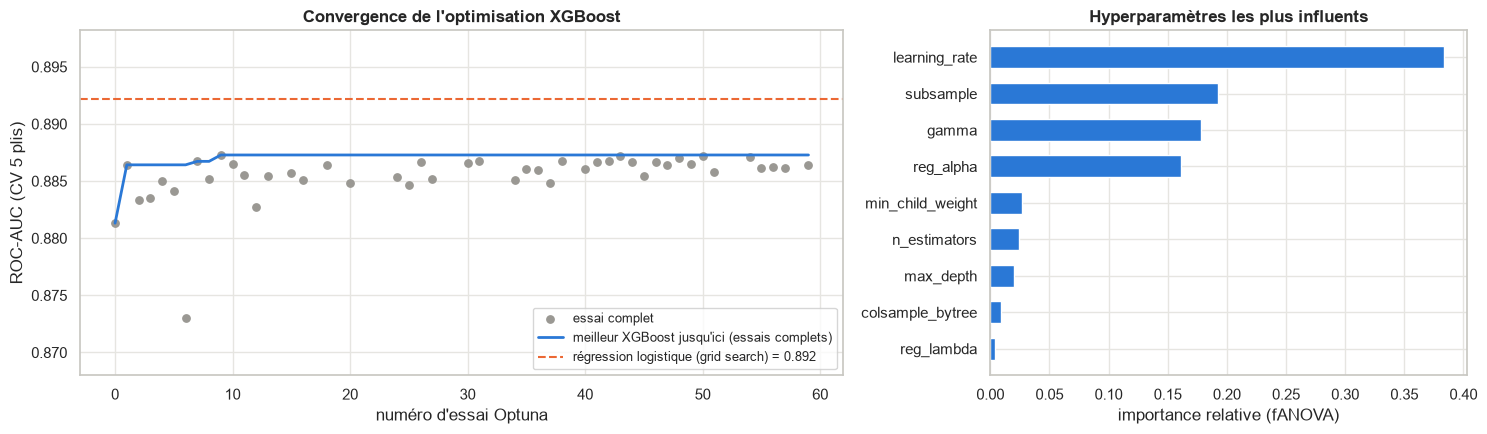

In [35]:
if OPTUNA_OK:
    done = trials_df[trials_df["state"] == "COMPLETE"]
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [1.6, 1]})
    ax = axes[0]
    ax.scatter(done["number"], done["value"], s=28, color=C_GREY, label="essai complet")
    complete_values = trials_df["value"].where(trials_df["state"] == "COMPLETE")  # un essai élagué n'a qu'un score partiel
    ax.plot(trials_df["number"], complete_values.fillna(-np.inf).cummax().replace(-np.inf, np.nan),
            color=C_OK, lw=2, label="meilleur XGBoost jusqu'ici (essais complets)")
    ax.axhline(logit_grid.best_score_, color=C_CHURN, ls="--", lw=1.5,
               label=f"régression logistique (grid search) = {logit_grid.best_score_:.3f}")
    ax.set_ylim(max(done["value"].min() - .005, .86), logit_grid.best_score_ + .006)
    ax.set_xlabel("numéro d'essai Optuna"); ax.set_ylabel("ROC-AUC (CV 5 plis)")
    ax.set_title("Convergence de l'optimisation XGBoost"); ax.legend(loc="lower right", fontsize=9)

    imp_hp = pd.Series(optuna.importance.get_param_importances(
        study, evaluator=optuna.importance.FanovaImportanceEvaluator(seed=RANDOM_STATE))).sort_values()
    axes[1].barh(imp_hp.index, imp_hp.values, color=C_OK, height=.6)
    axes[1].set_xlabel("importance relative (fANOVA)"); axes[1].set_title("Hyperparamètres les plus influents")
    plt.tight_layout(); plt.show()

**Comparaison finale des modèles optimisés.** L'AUC du meilleur essai Optuna est un maximum parmi 60 : elle est légèrement **optimiste** (on a choisi le meilleur parmi beaucoup de tirages). Pour comparer équitablement, on ré-évalue chaque modèle optimisé avec la même fonction `evaluate` (mêmes plis, mêmes métriques : AUC, PR-AUC, Brier). Chaque évaluation est aussi tracée dans MLflow.

In [36]:
best_C = logit_grid.best_params_["model__C"]
final_cmp = [evaluate(f"Logistique (grid search, C = {best_C})", LogisticRegression(C=best_C, max_iter=5000),
                      phase="comparaison_finale"),
             evaluate("HistGradientBoosting (grid search)",
                      HistGradientBoostingClassifier(random_state=RANDOM_STATE,
                                                     **{k.split("__")[1]: v for k, v in hgb_grid.best_params_.items()}),
                      phase="comparaison_finale")]
if OPTUNA_OK:
    final_cmp.append(evaluate("XGBoost (Optuna, 60 essais)",
                              xgb.XGBClassifier(**study.best_params, eval_metric="logloss", n_jobs=-1,
                                                random_state=RANDOM_STATE), phase="comparaison_finale"))
final_cmp = pd.DataFrame(final_cmp).set_index("modèle")
final_cmp.round(4)

,ROC-AUC,± AUC,PR-AUC,± PR,Brier
modèle,,,,,
"Logistique (grid search, C = 0.03)",0.8922,0.0090,0.7936,0.0197,0.1133
HistGradientBoosting (grid search),0.8859,0.0077,0.7793,0.0166,0.1172
"XGBoost (Optuna, 60 essais)",0.8873,0.0072,0.7804,0.0167,0.1161


**Lecture :**
- XGBoost optimisé par Optuna (60 essais, dont une partie élaguée) atteint une AUC d'environ **0,887**, au niveau du boosting scikit-learn mais **toujours sous la régression logistique (0,892)**, sur l'AUC comme sur la PR-AUC et le Brier score.
- La courbe de convergence montre que le meilleur essai est trouvé tôt (n° 9) et n'est plus dépassé ensuite : ajouter des essais ne changerait pas la conclusion. Environ un quart des essais ont été élagués avant la fin de leur validation croisée, ce qui a économisé du calcul.
- Les hyperparamètres les plus influents sont le taux d'apprentissage, le sous-échantillonnage et les régularisations (`gamma`, `reg_alpha`) ; la profondeur et le nombre d'arbres comptent peu.
- Le meilleur réglage est un modèle **très contraint** (arbres de profondeur 2, apprentissage lent, forte régularisation) : Optuna pousse XGBoost vers un modèle presque additif, c'est-à-dire vers ce que fait déjà la logistique. C'est une confirmation indirecte que la relation churn ↔ variables est essentiellement **additive et monotone**.
- Coût : l'étude Optuna est de loin la phase la plus longue et la plus énergivore du notebook (§12.5), pour un modèle moins bon.

**Décision finale : régression logistique régularisée.** Arguments : (1) meilleure performance, y compris face à un XGBoost optimisé par Optuna, (2) coefficients directement interprétables pour les CSM, (3) probabilités calibrées, (4) entraînement et scoring instantanés et sobres, (5) aucune dépendance lourde pour le déploiement (XGBoost et Optuna ne sont pas nécessaires à l'API). XGBoost + Optuna reste le **challenger désigné** pour les ré-entraînements futurs (§13), si l'ajout d'un historique d'usage fait apparaître des effets non linéaires.

### 9.2 Stabilité et sur-apprentissage

**Pourquoi ?** Un bon score moyen peut cacher un modèle instable ou sur-appris. On compare le score sur les plis d'**entraînement** et de **validation** : un grand écart signalerait du sur-apprentissage. On trace aussi une **courbe d'apprentissage** : si le score de validation plafonne déjà avec 50 % des données, ajouter des données n'apportera pas beaucoup.

AUC train : 0.8968 ± 0.0023
AUC valid : 0.8922 ± 0.0090   (écart = 0.0046)


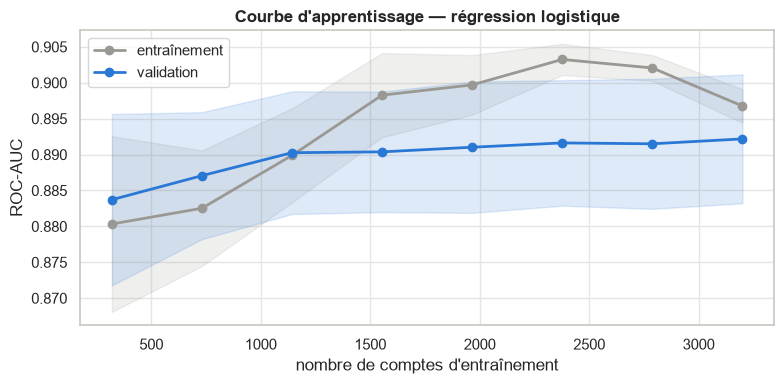

In [37]:
from sklearn.model_selection import learning_curve

best_logit = logit_grid.best_estimator_
r = cross_validate(best_logit, X_train, y_train, cv=CV, scoring="roc_auc", return_train_score=True)
print(f"AUC train : {r['train_score'].mean():.4f} ± {r['train_score'].std():.4f}")
print(f"AUC valid : {r['test_score'].mean():.4f} ± {r['test_score'].std():.4f}   (écart = {r['train_score'].mean() - r['test_score'].mean():.4f})")

sizes, tr_sc, va_sc = learning_curve(best_logit, X_train, y_train, cv=CV, scoring="roc_auc",
                                     train_sizes=np.linspace(.1, 1, 8), n_jobs=-1)
fig, ax = plt.subplots(figsize=(8, 4))
for sc, lab, c in [(tr_sc, "entraînement", C_GREY), (va_sc, "validation", C_OK)]:
    ax.plot(sizes, sc.mean(1), "o-", color=c, lw=2, ms=6, label=lab)
    ax.fill_between(sizes, sc.mean(1) - sc.std(1), sc.mean(1) + sc.std(1), color=c, alpha=.15)
ax.set_xlabel("nombre de comptes d'entraînement"); ax.set_ylabel("ROC-AUC")
ax.set_title("Courbe d'apprentissage — régression logistique"); ax.legend(); plt.tight_layout(); plt.show()

**Lecture** : l'écart train / validation est **très faible** (< 0,01) et l'écart-type entre plis aussi → modèle **stable et non sur-appris**. La courbe d'apprentissage est presque plate au-delà de ~2 000 comptes : la performance est limitée par l'**information contenue dans les variables**, pas par le volume. Pour progresser, il faudra de **nouvelles sources** (historique d'usage, §3.3) plutôt que plus de lignes.

### 9.3 Choix du seuil de décision métier

**Pourquoi ne pas garder le seuil par défaut de 0,5 ?** Le seuil 0,5 suppose qu'un faux négatif et un faux positif coûtent autant. Or ce n'est pas le cas ici.

**Hypothèses de coût (à valider avec la direction CS) :**
- **Coût d'un faux positif** `C_FP = 300 €` : ~3 h de CSM (appel, analyse, plan d'action) + éventuel geste commercial inutile.
- **Coût d'un faux négatif** `C_FN = 1 500 €` : perte évitable. Avec un MRR médian ≈ 680 €, 12 mois de revenu ≈ 8 000 € ; en supposant qu'une action de rétention réussit dans ~20-25 % des cas, le manque à gagner moyen d'un churner non contacté est d'environ 1 500-2 000 €. On retient l'hypothèse **prudente** de 1 500 €.
- → **Un FN coûte 5 fois plus qu'un FP.** Pour des probabilités calibrées, le seuil optimal théorique est `C_FP / (C_FP + C_FN) = 1/6 ≈ 0,17`.

**Méthode :** on calcule des **prédictions hors-plis** (*out-of-fold*) sur le train avec `cross_val_predict` : chaque compte reçoit une probabilité prédite par un modèle qui ne l'a **pas vu**. On balaye ensuite tous les seuils et on retient celui qui **minimise le coût total**, sous la **contrainte métier de rappel ≥ 0,80**. Le test n'intervient pas dans ce choix.

In [38]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

C_FP, C_FN = 300, 1500
MIN_RECALL = 0.80

oof_proba = cross_val_predict(best_logit, X_train, y_train, cv=CV, method="predict_proba")[:, 1]


def threshold_table(y_true, proba, thresholds):
    rows = []
    for t in thresholds:
        pred = (proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
        rows.append({"seuil": t, "rappel": tp / (tp + fn), "précision": tp / max(tp + fp, 1),
                     "% comptes signalés": pred.mean(), "FP": fp, "FN": fn,
                     "coût total (€)": fp * C_FP + fn * C_FN})
    return pd.DataFrame(rows)


thr = threshold_table(y_train, oof_proba, np.round(np.arange(0.05, 0.91, 0.01), 2))
eligible = thr[thr["rappel"] >= MIN_RECALL]
THRESHOLD = float(eligible.loc[eligible["coût total (€)"].idxmin(), "seuil"])

ref = pd.DataFrame([
    {"stratégie": "Ne contacter personne", "coût total (€)": y_train.sum() * C_FN},
    {"stratégie": "Contacter tout le monde", "coût total (€)": (1 - y_train).sum() * C_FP},
    {"stratégie": "Seuil par défaut 0,5", "coût total (€)": thr.loc[thr.seuil == 0.5, "coût total (€)"].item()},
    {"stratégie": f"Seuil métier retenu {THRESHOLD:.2f}", "coût total (€)": thr.loc[thr.seuil == THRESHOLD, "coût total (€)"].item()},
])
print(f"Seuil retenu : {THRESHOLD:.2f}  (théorique si probabilités calibrées : {C_FP / (C_FP + C_FN):.2f})\n")
display(ref.style.format({"coût total (€)": "{:,.0f}"}).hide(axis="index"))
thr[thr.seuil.isin([0.1, 0.15, THRESHOLD, 0.2, 0.25, 0.3, 0.4, 0.5])].style.format(
    {"rappel": "{:.2f}", "précision": "{:.2f}", "% comptes signalés": "{:.0%}", "coût total (€)": "{:,.0f}"}).hide(axis="index")

Seuil retenu : 0.18  (théorique si probabilités calibrées : 0.17)



stratégie,coût total (€)
Ne contacter personne,"1,680,000"
Contacter tout le monde,"864,000"
"Seuil par défaut 0,5","734,400"
Seuil métier retenu 0.18,"440,700"


seuil,rappel,précision,% comptes signalés,FP,FN,coût total (€)
0.100000,0.96,0.44,61%,1356,46,"475,800"
0.150000,0.92,0.49,52%,1054,92,"454,200"
0.180000,0.90,0.53,48%,909,112,"440,700"
0.200000,0.88,0.55,45%,823,132,"444,900"
0.250000,0.84,0.59,40%,657,183,"471,600"
0.300000,0.79,0.63,35%,520,238,"513,000"
0.400000,0.69,0.71,27%,315,344,"610,500"
0.500000,0.60,0.78,21%,188,452,"734,400"


**Visualisation du compromis.** Le tableau donne quelques points ; la courbe montre **toute** la forme du coût en fonction du seuil. On veut vérifier que l'optimum n'est pas un pic isolé (fragile) mais un creux large (robuste). Le second graphique montre ce que chaque seuil implique pour les équipes : rappel, précision et **part du portefeuille signalée** (charge de travail CSM).

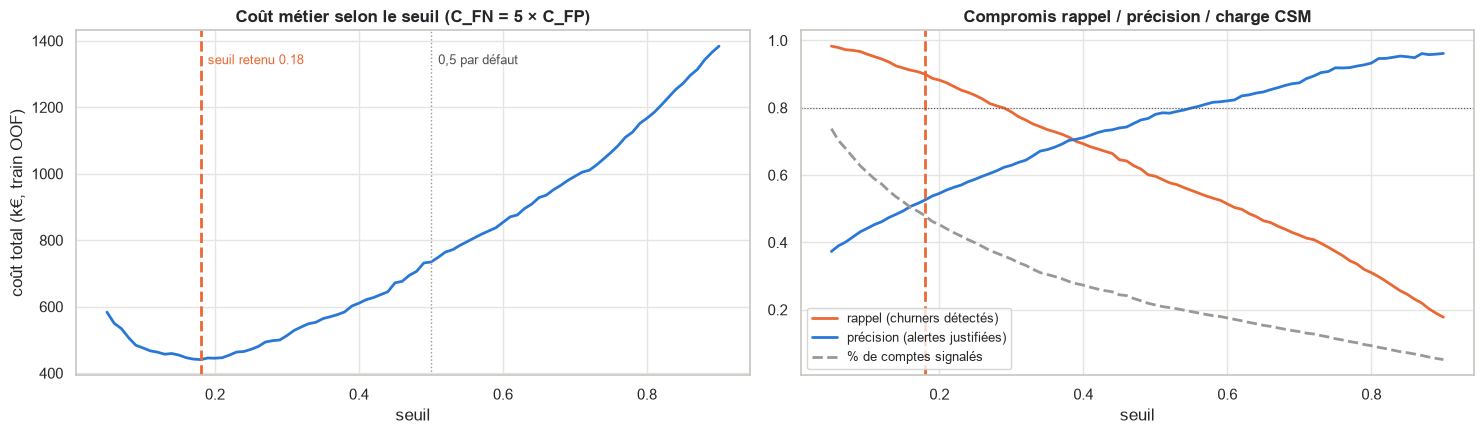

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
ax = axes[0]
ax.plot(thr["seuil"], thr["coût total (€)"] / 1000, color=C_OK, lw=2)
ax.axvline(THRESHOLD, color=C_CHURN, lw=2, ls="--"); ax.axvline(0.5, color=C_GREY, lw=1, ls=":")
ax.text(THRESHOLD + .01, ax.get_ylim()[1] * .95, f"seuil retenu {THRESHOLD:.2f}", color=C_CHURN, fontsize=9, va="top")
ax.text(0.51, ax.get_ylim()[1] * .95, "0,5 par défaut", color="#52514e", fontsize=9, va="top")
ax.set_xlabel("seuil"); ax.set_ylabel("coût total (k€, train OOF)"); ax.set_title("Coût métier selon le seuil (C_FN = 5 × C_FP)")

ax = axes[1]
ax.plot(thr["seuil"], thr["rappel"], color=C_CHURN, lw=2, label="rappel (churners détectés)")
ax.plot(thr["seuil"], thr["précision"], color=C_OK, lw=2, label="précision (alertes justifiées)")
ax.plot(thr["seuil"], thr["% comptes signalés"], color=C_GREY, lw=2, ls="--", label="% de comptes signalés")
ax.axvline(THRESHOLD, color=C_CHURN, lw=2, ls="--"); ax.axhline(MIN_RECALL, color="#52514e", lw=.8, ls=":")
ax.set_xlabel("seuil"); ax.set_title("Compromis rappel / précision / charge CSM"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Lecture et justification du seuil :**
- Le seuil de 0,5 laisserait passer **40 % des churners** (rappel 0,60) : c'est, parmi les stratégies avec modèle, la plus coûteuse (≈ 734 k€ sur le train).
- Le seuil retenu **0,18** — quasiment égal au seuil théorique 0,17, ce qui confirme que les probabilités sont bien calibrées — **détecte 90 % des churners** (hors-plis) avec une précision de 0,53. Le coût tombe à ≈ 441 k€ : **−40 %** par rapport au seuil 0,5, **−49 %** par rapport à « contacter tout le monde » et **−74 %** par rapport à « ne rien faire ».
- La contrainte de rappel ≥ 0,80 n'est pas active ici : l'optimum de coût la satisfait déjà largement.
- **Point d'attention — charge CSM** : ce seuil signale ~48 % du portefeuille. C'est cohérent avec un churn de 28 % et un FN 5× plus coûteux, mais cela suppose que toutes les alertes ne mobilisent pas un CSM. D'où les **niveaux de risque** du §10 : « élevé » → suivi individuel par un CSM ; « modéré » → actions à l'échelle (e-mail d'onboarding, webinaire, relance automatisée validée par le CSM).
- La courbe de coût est **plate autour de l'optimum** (0,15 → 454 k€, 0,20 → 445 k€) : un seuil légèrement différent change peu le coût. Si la capacité CSM est plus contrainte, remonter le seuil à 0,25-0,30 réduit le volume signalé à 35-40 % pour un surcoût de 7 à 16 %.

#### Sensibilité aux hypothèses de coût
**Pourquoi ?** Les coûts sont des hypothèses. On vérifie comment le seuil optimal (sans contrainte de rappel) évolue si le ratio C_FN / C_FP change : si le seuil change peu dans une plage raisonnable, la recommandation est robuste.

In [40]:
sens = []
for ratio in [2, 3, 5, 8, 12]:
    cost = thr["FP"] * 1 + thr["FN"] * ratio
    t = thr.loc[cost.idxmin()]
    sens.append({"ratio C_FN / C_FP": ratio, "seuil optimal": t["seuil"], "rappel": t["rappel"],
                 "précision": t["précision"], "% signalés": t["% comptes signalés"]})
pd.DataFrame(sens).style.format({"seuil optimal": "{:.2f}", "rappel": "{:.2f}", "précision": "{:.2f}",
                                 "% signalés": "{:.0%}"}).hide(axis="index")

ratio C_FN / C_FP,seuil optimal,rappel,précision,% signalés
2,0.38,0.71,0.70,28%
3,0.24,0.85,0.58,41%
5,0.18,0.90,0.53,48%
8,0.11,0.95,0.45,59%
12,0.09,0.97,0.43,63%


**Lecture** : pour des ratios de 3 à 8 (fourchette plausible), le seuil optimal reste entre **0,11 et 0,24** et le rappel entre **0,85 et 0,95**. Seul un ratio très faible (2:1, c'est-à-dire des actions de rétention presque aussi chères que la perte d'un client) ferait basculer vers un seuil plus élevé (0,38). Le choix est robuste ; il sera **recalibré** avec les vrais coûts une fois le premier trimestre de campagnes mesuré (§13).

### 9.4 Entraînement final et évaluation unique sur le jeu de test

**Pourquoi réentraîner sur tout le train ?** Le `GridSearchCV` a déjà réentraîné le meilleur modèle sur les 4 000 comptes du train (`refit=True`). On l'évalue maintenant **une seule fois** sur le test, jamais vu. Les chiffres obtenus sont l'estimation honnête de la performance en production.

In [41]:
final_model = logit_grid.best_estimator_
proba_test = final_model.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= THRESHOLD).astype(int)

test_metrics = {
    "ROC-AUC": roc_auc_score(y_test, proba_test),
    "PR-AUC": average_precision_score(y_test, proba_test),
    "Brier": brier_score_loss(y_test, proba_test),
    f"Rappel @ {THRESHOLD:.2f}": recall_score(y_test, pred_test),
    f"Précision @ {THRESHOLD:.2f}": precision_score(y_test, pred_test),
    f"F1 @ {THRESHOLD:.2f}": f1_score(y_test, pred_test),
    "% comptes signalés": pred_test.mean(),
}
pd.Series(test_metrics, name="test (1 000 comptes)").round(3).to_frame()

,test (1 000 comptes)
ROC-AUC,0.882
PR-AUC,0.762
Brier,0.121
Rappel @ 0.18,0.886
Précision @ 0.18,0.531
F1 @ 0.18,0.664
% comptes signalés,0.467


**Lecture** : les scores sur le test sont **proches de ceux de la validation croisée** (écart ≈ 0,01) → pas de sur-optimisation, l'estimation est fiable. Le rappel reste au-dessus de la contrainte de 0,80.

### 9.5 Courbes ROC, précision-rappel et matrice de confusion

**Pourquoi ces trois vues ?**
- **ROC** (exigée) : qualité du classement sur tous les seuils, comparée à la diagonale du hasard.
- **Précision-Rappel** : plus parlante en classe minoritaire ; la ligne horizontale = baseline naïve (28 %).
- **Matrice de confusion** au seuil retenu : ce que le CSM verra concrètement (combien d'alertes justifiées, combien de churners manqués).

On superpose la baseline métier sur ROC et PR pour visualiser la valeur ajoutée du modèle.

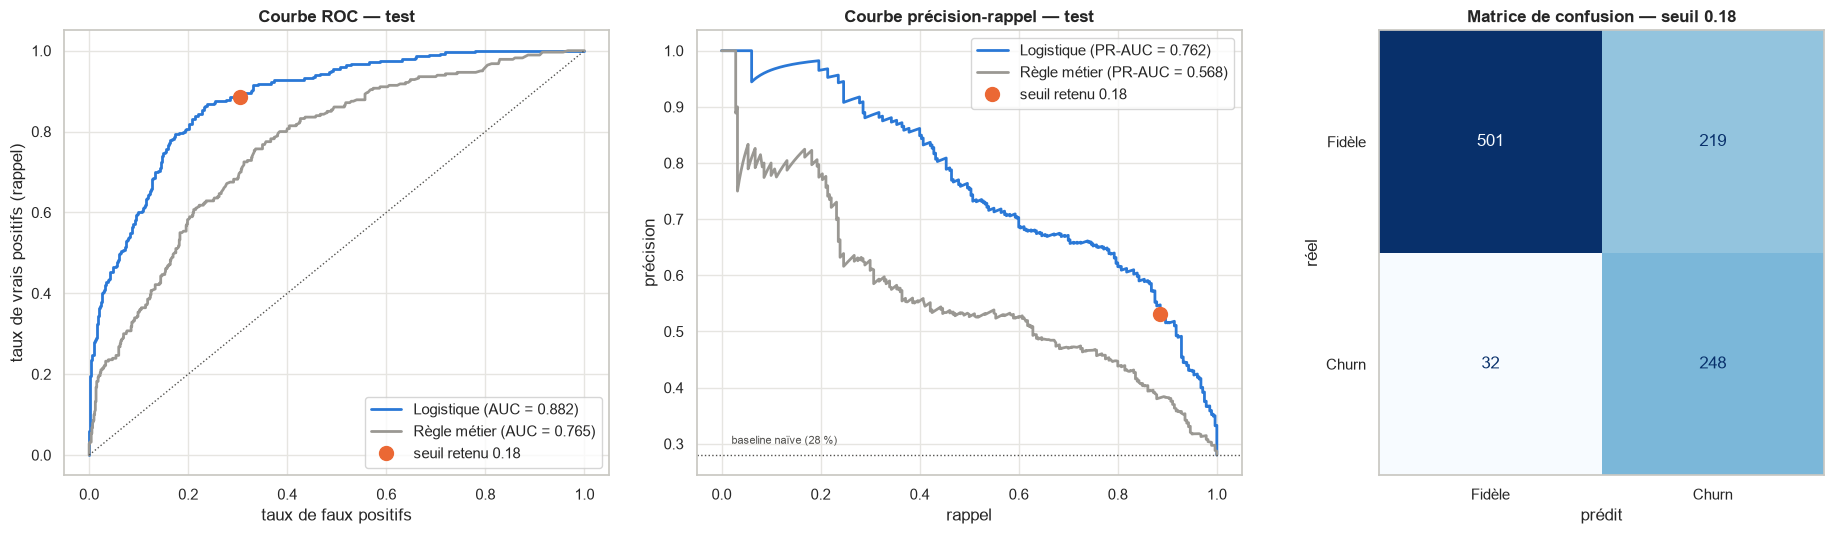

In [42]:
from sklearn.metrics import roc_curve, precision_recall_curve, ConfusionMatrixDisplay

rule_test = business_rule_score(X_test)
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

ax = axes[0]
for s, lab, c in [(proba_test, "Logistique", C_OK), (rule_test, "Règle métier", C_GREY)]:
    fpr, tpr, _ = roc_curve(y_test, s)
    ax.plot(fpr, tpr, color=c, lw=2, label=f"{lab} (AUC = {roc_auc_score(y_test, s):.3f})")
fpr_t = ((pred_test == 1) & (y_test == 0)).sum() / (y_test == 0).sum()
ax.plot(fpr_t, recall_score(y_test, pred_test), "o", color=C_CHURN, ms=10, label=f"seuil retenu {THRESHOLD:.2f}")
ax.plot([0, 1], [0, 1], ls=":", color="#52514e", lw=1)
ax.set_xlabel("taux de faux positifs"); ax.set_ylabel("taux de vrais positifs (rappel)")
ax.set_title("Courbe ROC — test"); ax.legend(loc="lower right")

ax = axes[1]
for s, lab, c in [(proba_test, "Logistique", C_OK), (rule_test, "Règle métier", C_GREY)]:
    p, r_, _ = precision_recall_curve(y_test, s)
    ax.plot(r_, p, color=c, lw=2, label=f"{lab} (PR-AUC = {average_precision_score(y_test, s):.3f})")
ax.plot(recall_score(y_test, pred_test), precision_score(y_test, pred_test), "o", color=C_CHURN, ms=10,
        label=f"seuil retenu {THRESHOLD:.2f}")
ax.axhline(y_test.mean(), ls=":", color="#52514e", lw=1)
ax.text(.02, y_test.mean() + .02, "baseline naïve (28 %)", fontsize=8, color="#52514e")
ax.set_xlabel("rappel"); ax.set_ylabel("précision"); ax.set_title("Courbe précision-rappel — test"); ax.legend()

ConfusionMatrixDisplay.from_predictions(y_test, pred_test, display_labels=["Fidèle", "Churn"],
                                        cmap="Blues", colorbar=False, ax=axes[2])
axes[2].set_title(f"Matrice de confusion — seuil {THRESHOLD:.2f}"); axes[2].grid(False)
axes[2].set_xlabel("prédit"); axes[2].set_ylabel("réel")
plt.tight_layout(); plt.show()

**Interprétation :**
- **ROC** : le modèle domine la règle métier sur toute la courbe. Le point orange montre le compromis choisi : ~89 % des churners détectés pour ~30 % des fidèles signalés à tort.
- **PR** : la précision reste bien au-dessus de la baseline de 28 % jusqu'à des rappels élevés ; au seuil retenu, **environ une alerte sur deux est un vrai churner** (précision 0,53) — acceptable car le coût d'une alerte inutile est 5 fois moindre que celui d'un churner manqué.
- **Matrice** : il reste une trentaine de churners non détectés. Ce sont des comptes dont les signaux observables (usage, support, paiement) ne sont pas dégradés : leur départ relève probablement de causes absentes des données (rachat, coupe budgétaire, concurrent), ce qui plaide pour enrichir les sources (§3.3).

#### Calibration des probabilités
**Pourquoi ?** On affichera « 65 % de risque » aux CSM : il faut que, parmi les comptes à 65 %, environ 65 % partent réellement. La courbe de calibration compare probabilité prédite et fréquence observée par tranche.

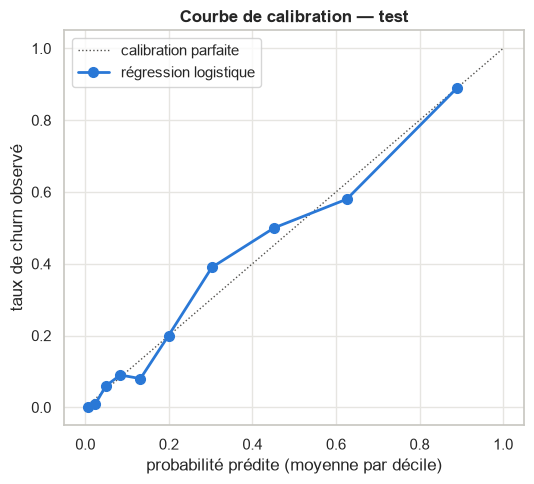

In [43]:
from sklearn.calibration import calibration_curve

frac_pos, mean_pred = calibration_curve(y_test, proba_test, n_bins=10, strategy="quantile")
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 1], [0, 1], ls=":", color="#52514e", lw=1, label="calibration parfaite")
ax.plot(mean_pred, frac_pos, "o-", color=C_OK, lw=2, ms=7, label="régression logistique")
ax.set_xlabel("probabilité prédite (moyenne par décile)"); ax.set_ylabel("taux de churn observé")
ax.set_title("Courbe de calibration — test"); ax.legend(); plt.tight_layout(); plt.show()

**Lecture** : les points suivent la diagonale → les probabilités sont **fiables** et peuvent être communiquées telles quelles. Pas besoin d'étape de recalibration (Platt / isotonique) — un avantage direct du choix de la logistique sans pondération de classes.

### 9.6 Explicabilité : quels facteurs pilotent le risque ?

**Deux lectures complémentaires :**
1. **Coefficients de la logistique** (sur variables standardisées) : sens et force de l'effet de chaque variable, *toutes choses égales par ailleurs*. Directement communicables : « un écart-type de retards de paiement en plus multiplie la cote de churn par exp(β) ».
2. **Importance par permutation** (exigée) : on mélange aléatoirement une colonne dans le test et on mesure la perte d'AUC. Méthode **agnostique du modèle** et calculée **sur des données non vues**, donc elle mesure l'utilité réelle d'une variable pour la prédiction. On la calcule sur un modèle entraîné **avec les leurres** pour montrer objectivement qu'ils n'apportent rien.

⚠️ *Précaution de lecture* : avec des variables corrélées (blocs identifiés au §6.7), la permutation d'une variable seule sous-estime son importance car une autre variable du bloc « compense ». On lit donc les importances **par blocs**, et on ne conclut jamais à une causalité.

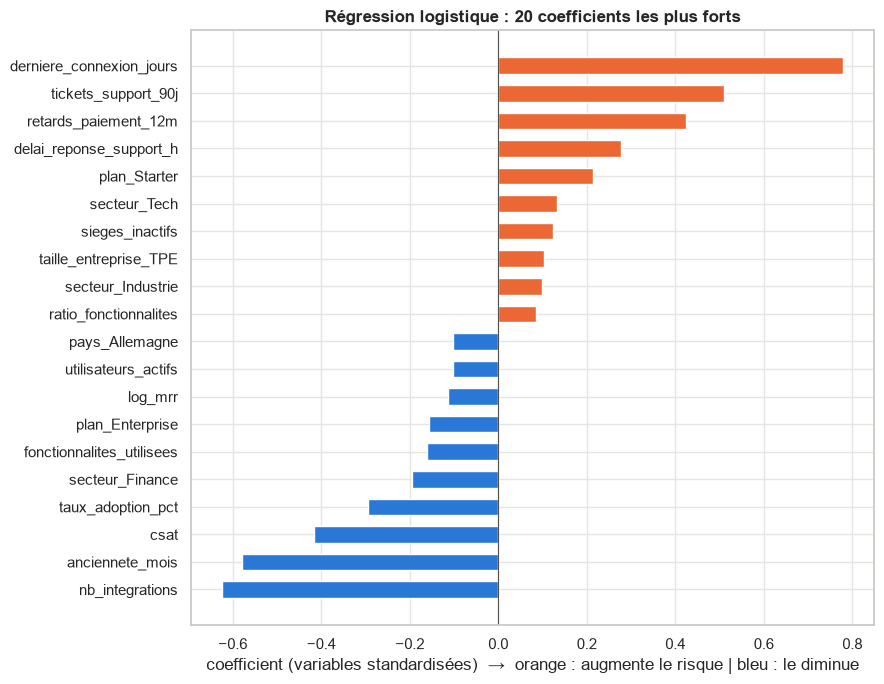

In [44]:
coef = pd.Series(final_model.named_steps["model"].coef_[0],
                 index=final_model.named_steps["prep"].get_feature_names_out()).sort_values()
top = pd.concat([coef.head(10), coef.tail(10)])
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top.index, top.values, color=[C_CHURN if v > 0 else C_OK for v in top.values], height=.6)
ax.axvline(0, color="#52514e", lw=.8)
ax.set_xlabel("coefficient (variables standardisées)  →  orange : augmente le risque | bleu : le diminue")
ax.set_title("Régression logistique : 20 coefficients les plus forts"); plt.tight_layout(); plt.show()

**Importance par permutation — mise en œuvre.** On ré-entraîne un modèle *de diagnostic* avec les mêmes hyperparamètres **plus les 4 leurres**, puis on permute chaque colonne **brute** (avant one-hot, pour qu'une variable catégorielle soit évaluée comme un tout) sur le **test**. 30 répétitions donnent une moyenne et un écart-type : une importance inférieure à son écart-type est indiscernable de zéro. Ce modèle de diagnostic sert uniquement à l'analyse ; il n'est pas déployé.

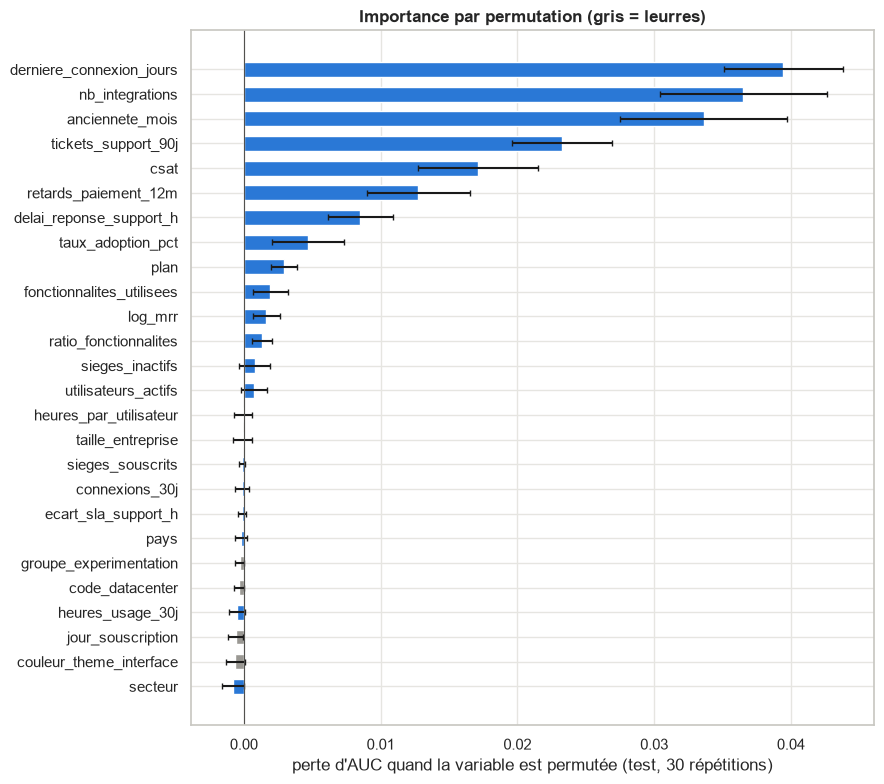

,importance,std
couleur_theme_interface,-0.0006,0.0007
code_datacenter,-0.0004,0.0004
groupe_experimentation,-0.0003,0.0003
jour_souscription,-0.0006,0.0006


In [45]:
from sklearn.inspection import permutation_importance

diag_model = Pipeline([("prep", make_preprocessor(NUM_FEATURES, CAT_FEATURES + DECOYS)),
                       ("model", LogisticRegression(max_iter=5000, **{k.split("__")[1]: v for k, v in logit_grid.best_params_.items()}))])
diag_model.fit(X_train, y_train)
cols_diag = NUM_FEATURES + CAT_FEATURES + DECOYS
perm = permutation_importance(diag_model, X_test[cols_diag], y_test, scoring="roc_auc",
                              n_repeats=30, random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.DataFrame({"importance": perm.importances_mean, "std": perm.importances_std},
                   index=cols_diag).sort_values("importance")

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(imp.index, imp["importance"], xerr=imp["std"], color=[C_GREY if c in DECOYS else C_OK for c in imp.index],
        height=.6, capsize=2)
ax.axvline(0, color="#52514e", lw=.8)
ax.set_xlabel("perte d'AUC quand la variable est permutée (test, 30 répétitions)")
ax.set_title("Importance par permutation (gris = leurres)"); plt.tight_layout(); plt.show()
imp.loc[DECOYS].round(4)

**Interprétation :**
- **Facteurs de risque principaux** (cohérents entre coefficients et permutation) :
  1. **Engagement** : dernière connexion ancienne (1er facteur en permutation et en coefficient), faible taux d'adoption.
  2. **Ancrage** : peu d'intégrations tierces et faible ancienneté (effets protecteurs les plus forts ; un client intégré à son SI a un coût de sortie élevé).
  3. **Friction support** : nombre de tickets, CSAT bas, délai de réponse long.
  4. **Santé financière** : retards de paiement.
- Le **plan** (Starter plus risqué) et la **taille** jouent un rôle secondaire, en grande partie expliqué par l'usage ; `secteur` et `pays` ont un poids faible, comme attendu au §6.6. Les variables construites (`ratio_fonctionnalites`, `ecart_sla_support_h`, `sieges_inactifs`) apportent peu en plus des variables brutes — honnêtement, le feature engineering n'améliore pas l'AUC ici (0,891 avec ou sans), mais il fournit des libellés plus parlants pour les CSM.
- **Les 4 leurres ont une importance nulle** (compatible avec 0 compte tenu de l'écart-type) → confirmation multivariée de leur exclusion. On **ne sur-interprète pas** les petites valeurs positives ou négatives : elles sont du bruit de permutation.
- Ces facteurs sont **actionnables** par les CSM : relance d'usage / formation (engagement), escalade support (friction), accompagnement à l'intégration (ancrage), point avec la finance (paiement).
- ⚠️ Ce sont des **associations**, pas des causes : augmenter artificiellement les intégrations d'un client ne garantit pas sa rétention. Seul un A/B test des actions de rétention permettrait de mesurer un effet causal (§13).

### 📓 Journal de bord — Entraînement
- **Décision** : régression logistique L2 (`C` optimisé par CV), sans pondération de classes → probabilités calibrées.
- **Décision** : seuil métier choisi sur prédictions hors-plis (pas sur le test) : minimisation du coût (C_FN = 5 × C_FP) sous contrainte rappel ≥ 0,80.
- **Constat** : pas de sur-apprentissage, performance test ≈ CV.
- **Constat** : leurres confirmés nuls par permutation.
- **Essai abandonné** : boosting optimisé — ne dépasse pas la logistique, ni avec la grille de 24 combinaisons (HistGradientBoosting), ni avec XGBoost optimisé par Optuna (60 essais TPE avec élagage). Conservé comme challenger pour les ré-entraînements futurs (si l'historique d'usage apporte des non-linéarités).
- **Décision** : grid search pour la logistique (1 paramètre utile, espace petit), Optuna pour XGBoost (9 paramètres dont plusieurs continus).

## 🟦 10. Implémentation et mise en exploitation (déploiement, exemple d'usage) — journal de bord [C6]

### 10.1 Sérialisation du modèle et de ses métadonnées

**Choix de `joblib`** : format standard pour les objets scikit-learn (efficace sur les tableaux numpy). On sérialise **le pipeline complet** (prétraitement + modèle) — et non le modèle seul — pour qu'il soit impossible d'appliquer en production un prétraitement différent de celui de l'entraînement.

**Pourquoi un fichier de métadonnées JSON à côté ?** Traçabilité (C9) : version, date, variables attendues, seuil, métriques de test, hypothèses de coût, version de scikit-learn (un modèle joblib n'est garanti que pour la même version). Ce fichier est aussi joint au modèle dans le registre MLflow (cellule suivante).

⚠️ *Sécurité* : un fichier joblib/pickle peut exécuter du code au chargement → ne charger que des modèles provenant du registre interne (checksum vérifié).

In [46]:
import joblib, hashlib
from datetime import datetime

MODEL_VERSION = "1.0.0"
model_path = MODEL_DIR / f"churn_model_v{MODEL_VERSION}.joblib"
joblib.dump(final_model, model_path)

metadata = {
    "model_name": "churn_saas_logistic",
    "version": MODEL_VERSION,
    "trained_at": datetime.now().isoformat(timespec="seconds"),
    "sklearn_version": sklearn.__version__,
    "algorithm": "LogisticRegression (L2)",
    "hyperparameters": {k.split("__")[1]: v for k, v in logit_grid.best_params_.items()},
    "features_numeric": NUM_FEATURES,
    "features_categorical": CAT_FEATURES,
    "excluded_features": EXCLUDED,
    "decision_threshold": THRESHOLD,
    "cost_assumptions_eur": {"false_positive": C_FP, "false_negative": C_FN},
    "train_size": int(len(X_train)), "train_churn_rate": float(y_train.mean()),
    "test_metrics": {k: round(float(v), 4) for k, v in test_metrics.items()},
    "sha256": hashlib.sha256(model_path.read_bytes()).hexdigest(),
}
(MODEL_DIR / f"churn_model_v{MODEL_VERSION}.json").write_text(json.dumps(metadata, indent=2, ensure_ascii=False))
print("Modèle     :", model_path, f"({model_path.stat().st_size / 1024:.0f} Ko)")
print("Métadonnées:", MODEL_DIR / f"churn_model_v{MODEL_VERSION}.json")

Modèle     : models/churn_model_v1.0.0.joblib (7 Ko)
Métadonnées: models/churn_model_v1.0.0.json


### 10.1 bis Enregistrement dans le registre de modèles MLflow

**Pourquoi en plus du fichier joblib ?** Le fichier joblib suffit pour ce notebook, mais en production plusieurs versions du modèle coexistent (champion en production, challenger en test, anciennes versions pour un retour arrière). Le **registre MLflow** gère ce cycle de vie :
- le run `Modèle final` regroupe hyperparamètres, seuil, hypothèses de coût, métriques de test et fichiers de métadonnées ;
- il enregistre aussi la **lignée des données** : la table Gold d'entraînement (dataset MLflow), les empreintes SHA-256 des couches Bronze, Silver et Gold, et leurs rapports. On peut ainsi prouver avec quelles données exactes un modèle a été entraîné ;
- le modèle est enregistré sous le nom `churn_saas_logistic` avec une **signature** (colonnes et types attendus en entrée). MLflow peut ainsi refuser une entrée mal formée ;
- l'**alias `champion`** désigne la version en production. Le job de scoring charge toujours `models:/churn_saas_logistic@champion`. Promouvoir un nouveau modèle ou revenir en arrière revient à **déplacer l'alias**, sans toucher au code de scoring.

**Format de sérialisation** : MLflow enregistre les modèles scikit-learn au format **skops**. Contrairement à pickle / joblib, skops n'exécute pas de code arbitraire au chargement : il n'accepte que les types déclarés comme sûrs. Notre pipeline utilise un seul type hors liste par défaut, `numpy.dtype` (le paramètre `dtype` de l'encodeur one-hot) ; on le déclare explicitement via `skops_trusted_types`. C'est une réponse directe au risque de sécurité signalé au §10.1.

**Contrôle** : on recharge le modèle depuis le registre et on vérifie que ses prédictions sont **identiques** à celles du modèle en mémoire. Sinon, la sérialisation aurait altéré le modèle.

*Note* : chaque exécution complète du notebook crée une nouvelle version dans le registre. C'est voulu : c'est l'historique qu'on veut garder en production.

In [47]:
FEATURES = NUM_FEATURES + CAT_FEATURES
FINAL_RUN_ID = None
if MLFLOW_OK:
    from mlflow import MlflowClient
    X_sig = X_train[FEATURES].astype({c: "float64" for c in NUM_FEATURES}).astype({c: "object" for c in CAT_FEATURES})
    with mlflow.start_run(run_name=f"Modèle final v{MODEL_VERSION}") as run:
        FINAL_RUN_ID = run.info.run_id
        mlflow.set_tags({"phase": "modele_final", "algorithme": "LogisticRegression", "statut": "champion"})
        mlflow.log_params({**metadata["hyperparameters"], "threshold": THRESHOLD, "cost_fp_eur": C_FP,
                           "cost_fn_eur": C_FN, "min_recall": MIN_RECALL, "n_train": len(X_train),
                           "features": ", ".join(FEATURES)})
        mlflow.log_metrics({"cv_roc_auc": logit_grid.best_score_,
                            "test_roc_auc": test_metrics["ROC-AUC"], "test_pr_auc": test_metrics["PR-AUC"],
                            "test_brier": test_metrics["Brier"],
                            "test_recall_at_threshold": test_metrics[f"Rappel @ {THRESHOLD:.2f}"],
                            "test_precision_at_threshold": test_metrics[f"Précision @ {THRESHOLD:.2f}"],
                            "test_share_flagged": test_metrics["% comptes signalés"]})
        mlflow.log_artifact(str(MODEL_DIR / f"churn_model_v{MODEL_VERSION}.json"))
        # Lignée des données : table Gold d'entraînement + rapports des couches Bronze / Silver / Gold
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            mlflow.log_input(mlflow.data.from_pandas(gold, source=str(gold_path), name="gold_features_churn",
                                                     targets=TARGET), context="training")
        mlflow.log_params({"data_gold_sha256": gold_meta["sha256"], "data_silver_sha256": silver_quality["sha256"],
                           "data_bronze_sha256": ingestion["files"]["churn_saas_complet.csv"]["sha256"]})
        for f in [BRONZE_DIR / "_ingestion.json", SILVER_DIR / "_qualite.json", GOLD_DIR / "_meta.json"]:
            mlflow.log_artifact(str(f), artifact_path="donnees")
        mlflow.sklearn.log_model(final_model, name="model", registered_model_name=REGISTERED_MODEL,
                                 signature=infer_signature(X_sig, final_model.predict_proba(X_train[FEATURES])[:, 1]),
                                 input_example=X_sig.head(3), skops_trusted_types=["numpy.dtype"])

    client = MlflowClient()
    latest = max(int(v.version) for v in client.search_model_versions(f"name='{REGISTERED_MODEL}'"))
    client.set_registered_model_alias(REGISTERED_MODEL, "champion", str(latest))
    registry_model = mlflow.sklearn.load_model(f"models:/{REGISTERED_MODEL}@champion")
    same = np.allclose(registry_model.predict_proba(X_test[FEATURES])[:, 1], proba_test)
    print(f"Run MLflow        : {FINAL_RUN_ID}")
    print(f"Registre          : {REGISTERED_MODEL} — version {latest} — alias 'champion'")
    print(f"Prédictions registre == modèle en mémoire : {same}")
else:
    print("MLflow non installé : le modèle est uniquement sauvegardé en joblib (§10.1).")

Run MLflow        : b692406b316b4cd5a207a1c265db6e0a
Registre          : churn_saas_logistic — version 10 — alias 'champion'
Prédictions registre == modèle en mémoire : True


Registered model 'churn_saas_logistic' already exists. Creating a new version of this model...
Created version '10' of model 'churn_saas_logistic'.


### 10.2 Fonction de scoring de bout en bout

**Pourquoi une fonction unique `score_accounts` ?** En production, le scoring part des **données brutes** exportées des systèmes sources (avec leurs défauts de format). La fonction enchaîne exactement les mêmes étapes qu'à l'entraînement : `parse_raw` → jointure catalogue → `add_features` → pipeline. Elle renvoie, pour chaque compte :
- la **probabilité** de churn et le **niveau de risque** (élevé / modéré / faible) ;
- les **3 principaux facteurs** qui augmentent le risque *pour ce compte* (contribution = coefficient × valeur standardisée) — c'est ce qui permet au CSM de savoir **quoi dire** au client ;
- le **MRR** du compte, pour prioriser à risque égal les comptes les plus importants.

Les libellés des facteurs sont traduits en langage métier : un CSM ne doit pas lire `num__derniere_connexion_jours`.

**Pourquoi passer le catalogue en paramètre** (au lieu d'utiliser la variable `cat` du notebook) ? Pour que la fonction ne dépende d'aucune variable globale : elle peut ainsi être copiée telle quelle dans le module de l'API (§10.4) et testée isolément.

In [48]:
FACTOR_LABELS = {
    "anciennete_mois": "compte récent", "nb_integrations": "peu d'intégrations",
    "retards_paiement_12m": "retards de paiement", "derniere_connexion_jours": "inactif depuis longtemps",
    "tickets_support_90j": "nombreux tickets support", "delai_reponse_support_h": "réponses support lentes",
    "ecart_sla_support_h": "SLA support dépassé", "csat": "satisfaction faible",
    "taux_adoption_pct": "faible adoption des sièges", "connexions_30j": "peu de connexions",
    "heures_usage_30j": "usage faible", "fonctionnalites_utilisees": "peu de fonctionnalités utilisées",
    "ratio_fonctionnalites": "faible profondeur d'usage", "heures_par_utilisateur": "usage par utilisateur faible",
    "utilisateurs_actifs": "peu d'utilisateurs actifs", "sieges_inactifs": "licences inutilisées",
    "sieges_souscrits": "nombre de sièges", "log_mrr": "niveau de MRR",
}


def load_model(version=MODEL_VERSION):
    meta = json.loads((MODEL_DIR / f"churn_model_v{version}.json").read_text())
    path = MODEL_DIR / f"churn_model_v{version}.joblib"
    assert hashlib.sha256(path.read_bytes()).hexdigest() == meta["sha256"], "checksum invalide"
    return joblib.load(path), meta


def score_accounts(raw_accounts: pd.DataFrame, model, meta, catalogue: pd.DataFrame, top_k=3) -> pd.DataFrame:
    d = parse_raw(raw_accounts).drop_duplicates()
    d = add_features(d.merge(catalogue, on="plan", how="left"))
    Xs = d[meta["features_numeric"] + meta["features_categorical"]]
    proba = model.predict_proba(Xs)[:, 1]

    # Contributions individuelles : coefficient × valeur transformée (lecture locale du modèle linéaire)
    prep, lr = model.named_steps["prep"], model.named_steps["model"]
    names = prep.get_feature_names_out()
    contrib = pd.DataFrame(prep.transform(Xs) * lr.coef_[0], columns=names, index=d.index)
    num_contrib = contrib[[n for n in names if n in FACTOR_LABELS]]
    reasons = num_contrib.apply(lambda r: ", ".join(FACTOR_LABELS[c] for c in r.nlargest(top_k).index if r[c] > 0), axis=1)

    t = meta["decision_threshold"]
    out = pd.DataFrame({
        "client_id": d["client_id"].values,
        "proba_churn": proba.round(3),
        "a_risque": proba >= t,
        "niveau": pd.cut(proba, [-0.01, t, max(0.6, t + 0.2), 1.0], labels=["faible", "modéré", "élevé"]),
        "facteurs_principaux": reasons.values,
        "mrr_eur": d["revenu_mensuel_recurrent_eur"].round(0).values,
    })
    out["mrr_a_risque_eur"] = (out["proba_churn"] * out["mrr_eur"]).round(0)
    return out.sort_values(["a_risque", "mrr_a_risque_eur"], ascending=False).reset_index(drop=True)

### 10.3 Exemple d'usage : scoring d'un lot mensuel

**Pourquoi l'échantillon de 50 lignes ?** Il a exactement le format brut d'un export source (virgules, `€`, casse…) : c'est un bon test d'intégration de la chaîne complète. (Rappel : ces comptes font partie du jeu d'origine — l'exemple illustre le *format de sortie*, pas une évaluation de performance.)

La liste est triée par **« MRR à risque »** = probabilité × MRR : à probabilité égale, un compte Enterprise à 20 k€/mois passe avant un Starter à 40 €/mois. C'est la liste que recevrait le CRM.

In [49]:
model, meta = load_model()
batch = score_accounts(sample_raw, model, meta, cat)
print(f"{len(batch)} comptes scorés — {batch['a_risque'].sum()} signalés à risque "
      f"(MRR total à risque : {batch.loc[batch.a_risque, 'mrr_eur'].sum():,.0f} €)\n")
batch.head(12)

50 comptes scorés — 25 signalés à risque (MRR total à risque : 56,608 €)



,client_id,proba_churn,a_risque,niveau,facteurs_principaux,mrr_eur,mrr_a_risque_eur
0,CLI-000847,0.905,True,élevé,"inactif depuis longtemps, compte récent, peu d...",6605.0,5978.0
1,CLI-000782,0.519,True,modéré,"nombreux tickets support, compte récent, faibl...",8657.0,4493.0
2,CLI-002189,0.898,True,élevé,"inactif depuis longtemps, peu d'intégrations, ...",4438.0,3985.0
3,CLI-004519,0.466,True,modéré,"retards de paiement, compte récent, peu d'inté...",7294.0,3399.0
4,CLI-000283,0.314,True,modéré,"nombreux tickets support, satisfaction faible,...",6932.0,2177.0
5,CLI-003394,0.405,True,modéré,"retards de paiement, compte récent, peu d'inté...",4753.0,1925.0
6,CLI-004120,0.289,True,modéré,"nombreux tickets support, retards de paiement,...",5380.0,1555.0
7,CLI-004313,0.994,True,élevé,"inactif depuis longtemps, nombreux tickets sup...",1104.0,1097.0
8,CLI-002779,0.645,True,élevé,"retards de paiement, compte récent, peu d'inté...",1262.0,814.0
9,CLI-000319,0.249,True,modéré,"retards de paiement, compte récent, peu d'inté...",2656.0,661.0


### 10.4 API de scoring (FastAPI)

**Pourquoi une API en plus du batch ?** Le batch mensuel couvre le besoin principal. L'API permet en plus à un CSM de **re-scorer un compte à la demande** depuis le CRM (par exemple après un appel client).

**Choix des outils — ceux du jalon M25 de la formation :**
- **FastAPI** : validation automatique des entrées par **Pydantic** (types, bornes), documentation Swagger générée (`/docs`), injection de dépendances qui rend l'API testable.
- **uvicorn** : serveur ASGI qui exécute l'application FastAPI.

**Principes de conception appliqués (et pourquoi) :**

| Principe | Mise en œuvre | Justification |
|---|---|---|
| Modèle chargé **une seule fois** | `lifespan` FastAPI + `ModelBundle` (modèle, métadonnées, catalogue) | Charger le fichier à chaque requête rendrait l'API lente ; on paie le coût au démarrage uniquement. |
| Checksum vérifié au chargement | SHA-256 comparé aux métadonnées | Refuser de servir un fichier modèle altéré ou incomplet. |
| **Liveness ≠ readiness** | `GET /health` : le processus répond ; `GET /ready` : le modèle est chargé (sinon **503**) | Deux questions différentes pour l'orchestrateur : faut-il redémarrer le service (health) ? peut-on lui envoyer du trafic (ready) ? |
| **Authentification** | En-tête `X-API-Key`, sinon **401** ; clé lue dans la variable d'environnement `CHURN_API_KEY` | Les scores sont des données commerciales : seul le CRM doit pouvoir appeler l'API. La clé n'est jamais écrite dans le code. |
| **Validation au bord** | Schéma Pydantic : bornes (CSAT 1-5, adoption 0-100 %…), 1 à 1 000 comptes par appel ; plan inconnu du catalogue → **422** | Une donnée aberrante est rejetée avec un message clair **avant** d'atteindre le modèle. La limite de 1 000 comptes évite les requêtes démesurées. |
| Traçabilité | En-tête `X-Request-ID` renvoyé (généré si absent) ; version du modèle et seuil dans chaque réponse | Relier une réponse aux logs, et savoir quel modèle a produit quel score. |
| **Même code qu'à l'entraînement** | Module `api/churn_scoring.py` généré à partir des fonctions du notebook | Aucune divergence entre la préparation des données à l'entraînement et en production. |

**Comment le module de scoring est produit.** Plutôt que de recopier à la main les fonctions de préparation (risque d'écart), on écrit `api/churn_scoring.py` à partir du **code source des fonctions du notebook** (`inspect.getsource`) et des constantes utilisées. Si une fonction change dans le notebook, le module de l'API change avec elle à la prochaine exécution.

In [50]:
import inspect

# --- 1. Module de scoring partagé : exactement les fonctions utilisées dans ce notebook ---
module_src = "# Fonctions de préparation et de scoring — générées depuis Churn_SaaS_IA.ipynb (ne pas éditer à la main).\n"
module_src += "import numpy as np\nimport pandas as pd\n\n"
for const in ["NUM_COLS", "CAT_NORMALIZE", "DATE_FORMATS", "FACTOR_LABELS"]:
    module_src += f"{const} = {globals()[const]!r}\n"
for fn in [to_number, normalize_cat, parse_dates, parse_raw, add_features, score_accounts]:
    module_src += "\n\n" + inspect.getsource(fn)
(API_DIR / "__init__.py").write_text("")
(API_DIR / "churn_scoring.py").write_text(module_src)

# --- 2. Application FastAPI ---
api_code = '''
# API de scoring churn (FastAPI).
# Lancer depuis la racine du projet :
#     CHURN_API_KEY=ma-cle uvicorn api.app:app --port 8000
# Documentation interactive : http://127.0.0.1:8000/docs
import hashlib
import json
import os
import uuid
from contextlib import asynccontextmanager
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Optional

import joblib
import pandas as pd
from fastapi import Depends, FastAPI, Header, HTTPException, Request, status
from pydantic import BaseModel, Field

from api.churn_scoring import normalize_cat, score_accounts

MODEL_DIR = Path(os.getenv("CHURN_MODEL_DIR", "models"))
MODEL_VERSION = os.getenv("CHURN_MODEL_VERSION", "1.0.0")
CATALOGUE_PATH = Path(os.getenv("CHURN_CATALOGUE", "catalogue_plans.csv"))
API_KEY = os.getenv("CHURN_API_KEY", "dev-key")  # à fournir en production, jamais dans le code


@dataclass
class ModelBundle:
    # Tout ce qu'une prédiction nécessite, chargé une fois au démarrage
    model: Any
    meta: dict
    catalogue: pd.DataFrame


_BUNDLE: Optional[ModelBundle] = None


def load_bundle() -> ModelBundle:
    meta = json.loads((MODEL_DIR / f"churn_model_v{MODEL_VERSION}.json").read_text())
    path = MODEL_DIR / f"churn_model_v{MODEL_VERSION}.joblib"
    if hashlib.sha256(path.read_bytes()).hexdigest() != meta["sha256"]:
        raise ValueError("checksum du modèle invalide")
    catalogue = pd.read_csv(CATALOGUE_PATH, encoding="utf-8-sig")
    catalogue["plan"] = normalize_cat(catalogue["plan"])
    catalogue["support_dedie"] = (catalogue["support_dedie"].str.strip().str.lower() == "oui").astype(int)
    return ModelBundle(model=joblib.load(path), meta=meta, catalogue=catalogue)


@asynccontextmanager
async def lifespan(app: FastAPI):
    global _BUNDLE
    try:
        _BUNDLE = load_bundle()
    except (FileNotFoundError, ValueError, KeyError):
        _BUNDLE = None  # l'API démarre quand même : /ready répondra 503
    yield


app = FastAPI(title="Churn scoring API", version=MODEL_VERSION, lifespan=lifespan)


@app.middleware("http")
async def add_request_id(request: Request, call_next):
    request_id = request.headers.get("X-Request-ID", str(uuid.uuid4()))
    response = await call_next(request)
    response.headers["X-Request-ID"] = request_id
    return response


def get_bundle() -> Optional[ModelBundle]:
    return _BUNDLE


def require_api_key(x_api_key: Optional[str] = Header(None, alias="X-API-Key")) -> None:
    if x_api_key is None or x_api_key != API_KEY:
        raise HTTPException(status_code=status.HTTP_401_UNAUTHORIZED, detail="Clé API absente ou invalide")


class Account(BaseModel):
    client_id: str = Field(..., examples=["CLI-000123"])
    plan: str = Field(..., examples=["Pro"])
    secteur: Optional[str] = None
    pays: Optional[str] = None
    taille_entreprise: str = Field(..., examples=["PME"])
    anciennete_mois: int = Field(..., ge=0, le=240)
    sieges_souscrits: int = Field(..., ge=1)
    utilisateurs_actifs: int = Field(..., ge=0)
    taux_adoption_pct: Optional[float] = Field(None, ge=0, le=100)
    connexions_30j: int = Field(..., ge=0)
    heures_usage_30j: Optional[float] = Field(None, ge=0)
    fonctionnalites_utilisees: int = Field(..., ge=0)
    nb_integrations: Optional[int] = Field(None, ge=0)
    derniere_connexion_jours: int = Field(..., ge=0)
    tickets_support_90j: int = Field(..., ge=0)
    delai_reponse_support_h: Optional[float] = Field(None, ge=0)
    csat: Optional[int] = Field(None, ge=1, le=5)
    retards_paiement_12m: Optional[int] = Field(None, ge=0)
    revenu_mensuel_recurrent_eur: Optional[float] = Field(None, ge=0)


class ScoreRequest(BaseModel):
    accounts: list[Account] = Field(..., min_length=1, max_length=1000)


class AccountScore(BaseModel):
    client_id: str
    proba_churn: float = Field(..., ge=0, le=1)
    a_risque: bool
    niveau: str
    facteurs_principaux: str
    mrr_eur: Optional[float]
    mrr_a_risque_eur: Optional[float]


class ScoreResponse(BaseModel):
    model_version: str
    threshold: float
    results: list[AccountScore]


@app.get("/health")
def health() -> dict:
    return {"status": "ok"}


@app.get("/ready")
def ready(bundle: Optional[ModelBundle] = Depends(get_bundle)) -> dict:
    if bundle is None:
        raise HTTPException(status_code=503, detail="Modèle non chargé")
    return {"status": "ready", "model_version": bundle.meta["version"]}


@app.post("/score", response_model=ScoreResponse, dependencies=[Depends(require_api_key)])
def score(payload: ScoreRequest, bundle: Optional[ModelBundle] = Depends(get_bundle)) -> ScoreResponse:
    if bundle is None:
        raise HTTPException(status_code=503, detail="Modèle non chargé")
    df = pd.DataFrame([a.model_dump() for a in payload.accounts]).astype("string")
    unknown = set(normalize_cat(df["plan"])) - set(bundle.catalogue["plan"])
    if unknown:
        raise HTTPException(status_code=422, detail=f"Plan inconnu du catalogue : {sorted(unknown)}")
    res = score_accounts(df, bundle.model, bundle.meta, bundle.catalogue)
    res = res.astype({"niveau": str}).astype(object).where(res.notna(), None)
    return ScoreResponse(model_version=bundle.meta["version"], threshold=bundle.meta["decision_threshold"],
                         results=res.to_dict(orient="records"))
'''
(API_DIR / "app.py").write_text(api_code.strip() + "\n")
for f in ["__init__.py", "churn_scoring.py", "app.py"]:
    print(f"{API_DIR / f}  ({(API_DIR / f).stat().st_size / 1024:.1f} Ko)")

api/__init__.py  (0.0 Ko)
api/churn_scoring.py  (5.6 Ko)
api/app.py  (5.2 Ko)


**Tests de l'API sans lancer de serveur.** `TestClient` de FastAPI simule des requêtes HTTP en mémoire ; utilisé dans un bloc `with`, il déclenche aussi le `lifespan`, donc le vrai chargement du modèle depuis `models/`. On vérifie chaque comportement attendu, avec son code HTTP :

| Cas testé | Code attendu |
|---|---|
| `/health` | 200 |
| `/ready` avec modèle chargé | 200 + version |
| `/score` sans clé, puis avec une mauvaise clé | 401 |
| `/score` avec une entrée hors bornes (CSAT = 9) | 422 |
| `/score` avec seulement les champs obligatoires (secteur, pays, CSAT… absents) | 200 |
| `/score` avec un plan inconnu du catalogue | 422 |
| `/score` valide | 200, **scores identiques au batch** du §10.3 |
| Modèle non chargé (simulé par `dependency_overrides`) : `/ready` puis `/score` | 503 |
| En-tête `X-Request-ID` | renvoyé à l'identique |

La clé utilisée ici est une clé de démonstration, injectée par variable d'environnement comme en production.

In [51]:
try:
    import importlib
    sys.dont_write_bytecode = True  # pas de __pycache__ dans api/
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        from fastapi.testclient import TestClient
    os.environ["CHURN_API_KEY"] = "cle-demo-notebook"
    if str(Path.cwd()) not in sys.path:
        sys.path.insert(0, str(Path.cwd()))
    import api.churn_scoring, api.app
    importlib.reload(api.churn_scoring); api_app = importlib.reload(api.app)

    KEY = {"X-API-Key": "cle-demo-notebook"}
    payload_df = parse_raw(sample_raw.head(3)).drop(columns=["date_souscription"])
    accounts = payload_df[list(api_app.Account.model_fields)].astype(object).where(payload_df.notna(), None).to_dict("records")

    checks = []
    with TestClient(api_app.app) as client:
        checks.append(("GET /health", 200, client.get("/health").status_code))
        r = client.get("/ready"); checks.append(("GET /ready (modèle chargé)", 200, r.status_code))
        checks.append(("POST /score sans clé", 401, client.post("/score", json={"accounts": accounts}).status_code))
        checks.append(("POST /score mauvaise clé", 401, client.post("/score", json={"accounts": accounts},
                                                                    headers={"X-API-Key": "faux"}).status_code))
        checks.append(("POST /score csat = 9", 422, client.post("/score", json={"accounts": [dict(accounts[0], csat=9)]},
                                                                headers=KEY).status_code))
        minimal = {k: v for k, v in accounts[0].items() if api_app.Account.model_fields[k].is_required()}
        checks.append(("POST /score champs optionnels absents", 200, client.post("/score", json={"accounts": [minimal]},
                                                                                 headers=KEY).status_code))
        checks.append(("POST /score plan inconnu", 422, client.post("/score", json={"accounts": [dict(accounts[0], plan="Gold")]},
                                                                    headers=KEY).status_code))
        r_ok = client.post("/score", json={"accounts": accounts}, headers={**KEY, "X-Request-ID": "demo-42"})
        checks.append(("POST /score valide", 200, r_ok.status_code))
        checks.append(("X-Request-ID renvoyé", "demo-42", r_ok.headers.get("X-Request-ID")))

        api_app.app.dependency_overrides[api_app.get_bundle] = lambda: None   # simule un modèle absent
        checks.append(("GET /ready (modèle absent)", 503, client.get("/ready").status_code))
        checks.append(("POST /score (modèle absent)", 503, client.post("/score", json={"accounts": accounts}, headers=KEY).status_code))
        api_app.app.dependency_overrides.clear()

    api_scores = pd.DataFrame(r_ok.json()["results"]).set_index("client_id")["proba_churn"]
    batch_scores = batch.set_index("client_id").loc[api_scores.index, "proba_churn"]
    checks.append(("Scores API == scores batch", True, bool(np.allclose(api_scores, batch_scores))))

    res = pd.DataFrame(checks, columns=["test", "attendu", "obtenu"])
    res["ok"] = np.where(res["attendu"].astype(str) == res["obtenu"].astype(str), "✅", "❌")
    display(res.style.hide(axis="index"))
    print("Réponse /ready :", r.json())
    print("Extrait de réponse /score :", json.dumps(r_ok.json()["results"][0], ensure_ascii=False))
except ImportError:
    print("FastAPI non installé : `pip install fastapi httpx` pour tester l'API.")

test,attendu,obtenu,ok
GET /health,200,200,✅
GET /ready (modèle chargé),200,200,✅
POST /score sans clé,401,401,✅
POST /score mauvaise clé,401,401,✅
POST /score csat = 9,422,422,✅
POST /score champs optionnels absents,200,200,✅
POST /score plan inconnu,422,422,✅
POST /score valide,200,200,✅
X-Request-ID renvoyé,demo-42,demo-42,✅
GET /ready (modèle absent),503,503,✅


Réponse /ready : {'status': 'ready', 'model_version': '1.0.0'}
Extrait de réponse /score : {"client_id": "CLI-003145", "proba_churn": 0.408, "a_risque": true, "niveau": "modéré", "facteurs_principaux": "retards de paiement, compte récent, faible adoption des sièges", "mrr_eur": 1203.0, "mrr_a_risque_eur": 491.0}


**Lecture** : tous les comportements attendus sont vérifiés, y compris les refus (401, 422, 503). Les probabilités renvoyées par l'API sont identiques à celles du scoring batch : c'est la preuve que l'API et le notebook appliquent exactement la même chaîne de préparation.

**Lancer l'API pour de vrai** (depuis la racine du projet, dans un terminal) :
```bash
CHURN_API_KEY=ma-cle .venv/bin/uvicorn api.app:app --port 8000
curl -fsS http://127.0.0.1:8000/health
curl -fsS http://127.0.0.1:8000/ready
```
Puis ouvrir la documentation interactive Swagger : http://127.0.0.1:8000/docs (bouton *Authorize* pour saisir la clé).

### 10.5 Conteneurisation (Docker)

**Pourquoi un conteneur ?** Pour que l'API tourne à l'identique sur le poste du développeur, en recette et en production : même version de Python, mêmes bibliothèques (scikit-learn doit être **exactement** la version d'entraînement pour relire le modèle), même modèle embarqué.

**Choix pour le `Dockerfile` (dans l'esprit du jalon M27) :**
- image de base **`python:3.12-slim`** : même version de Python que l'entraînement, image légère ;
- dépendances **figées** dans `api/requirements.txt` (générées depuis l'environnement du notebook) et installées **avant** de copier le code, pour profiter du cache Docker ;
- le **modèle et le catalogue sont copiés dans l'image** : l'image est autonome et versionnée avec son modèle ;
- exécution sous un **utilisateur non administrateur** (`appuser`) : limite les dégâts en cas de faille ;
- **`HEALTHCHECK`** sur `/health` : l'orchestrateur sait si le conteneur est vivant ;
- la clé API **n'est pas dans l'image** : elle est fournie au lancement (`-e CHURN_API_KEY=...`) ;
- un `.dockerignore` exclut l'environnement virtuel, les données brutes, MLflow et les notebooks : image plus petite, et aucune donnée client embarquée par erreur.

In [52]:
api_reqs = ["pandas", "numpy", "scikit-learn", "scipy", "joblib", "fastapi", "uvicorn", "pydantic"]
from importlib.metadata import version as pkg_version
(API_DIR / "requirements.txt").write_text("\n".join(f"{p}=={pkg_version(p)}" for p in api_reqs) + "\n")

dockerfile = f'''
FROM python:{sys.version_info.major}.{sys.version_info.minor}-slim

RUN useradd -m -u 10001 appuser
WORKDIR /app

COPY api/requirements.txt ./api/requirements.txt
RUN pip install --no-cache-dir -r api/requirements.txt

COPY api/ ./api/
COPY models/churn_model_v{MODEL_VERSION}.joblib models/churn_model_v{MODEL_VERSION}.json ./models/
COPY catalogue_plans.csv ./

ENV PYTHONUNBUFFERED=1 CHURN_MODEL_DIR=/app/models CHURN_MODEL_VERSION={MODEL_VERSION}
USER appuser
EXPOSE 8000
HEALTHCHECK --interval=30s --timeout=3s --retries=3 \\
  CMD python -c "import urllib.request,sys;sys.exit(0 if urllib.request.urlopen('http://localhost:8000/health').status==200 else 1)"
CMD ["uvicorn", "api.app:app", "--host", "0.0.0.0", "--port", "8000"]
'''
Path("Dockerfile").write_text(dockerfile.strip() + "\n")
Path(".dockerignore").write_text("\n".join([
    ".venv/", "mlruns/", "mlflow.db", "carbone/", "data/", "*.ipynb", "*.pdf", "*.md",
    "churn_saas_complet.csv", "churn_saas_echantillon.csv", "**/__pycache__/", ".git/"]) + "\n")

print(Path("Dockerfile").read_text())
print("api/requirements.txt :", ", ".join((API_DIR / "requirements.txt").read_text().split()))

FROM python:3.12-slim

RUN useradd -m -u 10001 appuser
WORKDIR /app

COPY api/requirements.txt ./api/requirements.txt
RUN pip install --no-cache-dir -r api/requirements.txt

COPY api/ ./api/
COPY models/churn_model_v1.0.0.joblib models/churn_model_v1.0.0.json ./models/
COPY catalogue_plans.csv ./

ENV PYTHONUNBUFFERED=1 CHURN_MODEL_DIR=/app/models CHURN_MODEL_VERSION=1.0.0
USER appuser
EXPOSE 8000
HEALTHCHECK --interval=30s --timeout=3s --retries=3 \
  CMD python -c "import urllib.request,sys;sys.exit(0 if urllib.request.urlopen('http://localhost:8000/health').status==200 else 1)"
CMD ["uvicorn", "api.app:app", "--host", "0.0.0.0", "--port", "8000"]

api/requirements.txt : pandas==3.0.6, numpy==2.5.3, scikit-learn==1.9.1, scipy==1.18.1, joblib==1.6.0, fastapi==0.141.1, uvicorn==0.53.0, pydantic==2.13.5


**Construire et lancer l'image** (Docker doit être démarré) :
```bash
docker build -t churn-api:1.0.0 .
docker run --rm -d --name churn-api -p 8000:8000 -e CHURN_API_KEY=ma-cle churn-api:1.0.0
curl -fsS http://127.0.0.1:8000/ready
docker inspect churn-api --format '{{.Config.User}}'   # doit afficher : appuser
docker stop churn-api
```

### 10.6 Livraison et déploiement continus (CI/CD) et versioning

**Pourquoi ?** Un modèle utile en production doit pouvoir être **modifié sans risque** : chaque changement de code est testé automatiquement, l'image livrée est toujours construite de la même façon, et l'on sait à tout moment **quelle version** du code et du modèle tourne.

**Versioning en place :**

| Objet | Outil | Convention |
|---|---|---|
| Code, notebook, API, tests, pipeline | **Git**, dépôt GitHub `churn-saas-ia` | Une étiquette `vX.Y.Z` par version livrée, alignée sur la version du modèle embarqué |
| Modèle | Fichier `churn_model_v1.0.0.joblib` + registre MLflow (alias `champion` / `challenger`) | Versionnage sémantique (§13.3) : `1.1.0` si ré-entraînement, `2.0.0` si les variables changent |
| Données | Empreintes SHA-256 des couches Bronze, Silver, Gold, enregistrées dans MLflow | Chaque modèle référence les données exactes qui l'ont produit |
| Image Docker | GitHub Container Registry (`ghcr.io`) | Même étiquette que le code (`1.0.0`) + `latest` |

**Pipeline GitHub Actions** (`.github/workflows/ci-cd.yml`) :

| Déclencheur | Étape | Ce qu'elle garantit |
|---|---|---|
| Chaque push ou pull request | **Tests** (`pytest`) : fonctions de préparation (formats de nombres, casse, 3 formats de date, imputations métier) et les 12 comportements de l'API vérifiés au §10.4 | Une régression est détectée **avant** la fusion |
| | **Image Docker** : construction, démarrage du conteneur, vérification de `/health`, `/ready` et de l'utilisateur non administrateur | L'image livrée démarre réellement et charge le modèle |
| Étiquette `vX.Y.Z` | **Publication** : contrôle que l'étiquette correspond à la version du modèle embarqué, puis envoi de l'image sur `ghcr.io` | Livraison continue : chaque version est disponible, identifiable et reproductible |
| | **Déploiement en production**, après **approbation manuelle** (environnement GitHub `production`) | Un humain valide chaque mise en production ; retour arrière = redéployer l'image précédente |

**Choix et justifications :**
- **GitHub Actions** : intégré au dépôt, gratuit pour un dépôt public, aucun serveur à maintenir. Jenkins ou GitLab CI conviendraient aussi ; seul le fichier de pipeline changerait.
- **Les tests reprennent ceux du notebook** (§10.4) dans des fichiers `pytest` : le notebook sert à la démonstration, les fichiers de tests à l'automatisation.
- **Deux cycles de livraison distincts** : le **code** de l'API suit le pipeline ci-dessus ; un **nouveau modèle** issu d'un ré-entraînement suit le cycle champion / challenger du registre MLflow (§13.2), puis est embarqué dans une nouvelle image avec une nouvelle étiquette.
- **Limite assumée** : la plateforme d'hébergement n'est pas imposée par le projet. L'étape de déploiement est donc une commande à remplacer par celle de l'hébergeur retenu (Kubernetes, Azure Container Apps, Cloud Run…). Toutes les étapes précédentes sont réelles et s'exécutent sur GitHub.

**Contrat d'interface de l'API.** FastAPI génère automatiquement la spécification **OpenAPI** de l'API (routes, schémas d'entrée et de sortie, codes d'erreur). La cellule suivante l'exporte dans `api/openapi.json`, versionné avec le code : c'est le document que l'équipe CRM utilise pour intégrer l'API (§11.4).

In [53]:
openapi_path = API_DIR / "openapi.json"
openapi_path.write_text(json.dumps(api_app.app.openapi(), indent=2, ensure_ascii=False))
spec = api_app.app.openapi()
print(f"{openapi_path} — OpenAPI {spec['openapi']}, API « {spec['info']['title']} » v{spec['info']['version']}")
for path, ops in spec["paths"].items():
    for verb, op in ops.items():
        print(f"  {verb.upper():5s} {path:8s} -> réponses {', '.join(sorted(op['responses']))}")

api/openapi.json — OpenAPI 3.1.0, API « Churn scoring API » v1.0.0
  GET   /health  -> réponses 200
  GET   /ready   -> réponses 200
  POST  /score   -> réponses 200, 422


### 📓 Journal de bord — Implémentation
- **Décision** : pipeline complet sérialisé + métadonnées JSON + checksum SHA-256, **et** inscrit au registre MLflow avec signature et alias `champion`.
- **Constat** : le modèle rechargé depuis le registre donne des prédictions identiques au modèle d'origine.
- **Décision** : une seule fonction de scoring, réutilisée par le batch et l'API → aucune divergence entraînement / production (« training-serving skew »). Le module de l'API est généré depuis le code du notebook, et un test vérifie que l'API et le batch donnent les mêmes scores.
- **Décision** : API alignée sur le jalon M25 de la formation — FastAPI + uvicorn, modèle chargé une fois (`lifespan`), `/health` distinct de `/ready` (503), clé API (401), validation Pydantic (422), `X-Request-ID`.
- **Décision** : image Docker autonome (modèle embarqué, dépendances figées, utilisateur non administrateur, healthcheck), clé API fournie au lancement.
- **Décision** : explication locale (top 3 facteurs) livrée avec chaque score, et tri par MRR à risque.
- **Difficulté** : conversion des types entre JSON (API) et pandas (pipeline) — résolue en repassant les entrées API par le même `parse_raw` que les exports bruts.
- **Difficulté** : au premier lancement réel de l'API, une requête sans `secteur` ni `pays` provoquait une erreur 500 : pandas représentait ces absences par `pd.NA`, que scikit-learn ne sait pas traiter. Corrigé en convertissant les manquants en `NaN` classiques dans `to_number` et `normalize_cat`, et un test « champs optionnels absents » a été ajouté.
- **Décision** : dépôt Git public sur GitHub, pipeline GitHub Actions (tests → image → test de démarrage → publication sur étiquette → déploiement après approbation), contrat OpenAPI exporté (§10.6).


## 🟦 11. Architecture cible et contraintes [C7]

### 11.1 Schéma d'architecture (batch mensuel + API à la demande)

```
  SOURCES                     DATA PLATFORM                          ML                          CONSOMMATION
┌──────────────┐        ┌───────────────────────┐        ┌──────────────────────────┐      ┌──────────────────────┐
│ Facturation  │──┐     │  Ingestion (ETL/ELT)  │        │  Registre de modèles     │      │  CRM (Salesforce/    │
│ CRM          │──┼────▶│  + contrôles qualité  │───────▶│  (MLflow) : v1.0.0 prod  │      │  HubSpot) : champ    │
│ Logs produit │──┤     │  (formats, bornes,    │        │  + métadonnées + seuil   │      │  « risque churn »,   │
│ Ticketing    │──┘     │   schéma, doublons)   │        └────────────┬─────────────┘      │  facteurs, MRR       │
└──────────────┘        │         ▼             │                     │                    │  → tâches CSM        │
                        │  Entrepôt (tables de  │        ┌────────────▼─────────────┐      └──────────▲───────────┘
                        │  features mensuelles, │───────▶│ Job de scoring batch     │─────────────────┤
                        │  historisées)         │        │ (1er du mois, Airflow)   │                 │
                        └───────────┬───────────┘        └────────────┬─────────────┘      ┌──────────┴───────────┐
                                    │                                 │                    │ API FastAPI (Docker) │
                                    │                                 ▼                    │ re-score à la demande│
                                    │                    ┌──────────────────────────┐      └──────────────────────┘
                                    └───────────────────▶│ Monitoring : dérive des  │
                                                         │ données, performance     │──▶ alertes / ré-entraînement
                                                         │ réelle (M+1), équité     │
                                                         └──────────────────────────┘
```

### 11.2 Choix d'architecture et justification

| Composant | Choix | Justification |
|---|---|---|
| Mode de scoring | **Batch mensuel** (+ API à la demande) | Le churn se décide à l'échéance mensuelle ; un score temps réel n'apporterait pas d'information et coûterait plus cher. |
| Orchestration | Airflow (ou cron managé) | Planification, reprise sur erreur, traçabilité des exécutions. |
| Stockage des données | Architecture **Bronze / Silver / Gold** (déjà en place localement en Parquet, §5.0), tables Gold mensuelles historisées dans l'entrepôt | Traçabilité jusqu'aux sources ; ré-entraînement sur l'historique ; validations temporelles. |
| Registre de modèles | MLflow — **déjà en place en local** (SQLite, §10.1 bis) ; serveur MLflow partagé en production | Versions, métriques, promotion par alias `champion` / `challenger`, rollback. |
| Empreinte carbone | CodeCarbon dans les jobs d'entraînement et de scoring | Suivi de la consommation dans le temps, arbitrage coût / gain des ré-entraînements. |
| Service | API FastAPI / uvicorn dans un conteneur Docker (§10.4-10.5) | Portabilité, mêmes dépendances en dev et en prod ; `/ready` sert de sonde de disponibilité à l'orchestrateur. |
| Intégration CRM | Écriture des scores dans un champ du compte + création de tâches pour les comptes « élevé » | Le CSM travaille dans son outil habituel : pas de nouvel écran à adopter. |

### 11.3 Contraintes

| Contrainte | Réponse |
|---|---|
| **Volumétrie** | ~5 000 comptes : scoring et entraînement en quelques secondes (mesurés au §12.1 bis) ; pas besoin de calcul distribué. |
| **Latence API** | < 100 ms (modèle linéaire, chargé une seule fois au démarrage ; mesurée au §12.1 bis). |
| **Sécurité API** | Clé `X-API-Key` fournie par variable d'environnement, validation Pydantic, 1 000 comptes maximum par appel ; en production : HTTPS, limitation de débit et taille de requête (jalon M26), clé stockée dans un gestionnaire de secrets. |
| **Coût** | Infrastructure minimale (un job mensuel + un petit conteneur). |
| **Sécurité / RGPD** | Données B2B, table d'entraînement pseudonymisée (clé dans un gestionnaire de secrets), accès restreint par rôle, chiffrement au repos, journalisation des accès, pas de texte libre, durée de conservation des scores limitée. |
| **Qualité des données** | Contrôles à l'ingestion (schéma, bornes, formats, doublons) ; un lot qui échoue n'est pas scoré (on garde les scores du mois précédent + alerte). |
| **Explicabilité** | Facteurs principaux fournis avec chaque score (exigence d'adoption par les CSM). |
| **Dépendances** | Versions figées (`requirements.txt`, annexe §15) ; le modèle n'est chargé qu'avec la version de scikit-learn d'entraînement. |

### 11.4 Besoins d'intégration

| Système | Sens du flux | Contenu | Format / protocole | Fréquence | Authentification | En cas d'erreur | Responsable |
|---|---|---|---|---|---|---|---|
| Facturation / CRM | Source → plateforme data | Plan, sièges, ancienneté, MRR, retards de paiement | Export planifié (CSV / Parquet) ou API, contrat d'interface versionné | Mensuelle | Compte de service en lecture seule | Contrôles de schéma et de bornes à l'ingestion (§6.1) ; scoring reporté si le socle bloquant manque (§3.4) | Sales Ops / Finance |
| Logs produit | Source → plateforme data | Connexions, heures, fonctionnalités, intégrations, **agrégées par compte** | Tables de l'entrepôt de données | Quotidienne, agrégée sur 30 jours | Compte de service | Modèle de secours ou report (§3.4, §8.5) | Product / Data |
| Ticketing | Source → plateforme data | Tickets, délai de réponse, CSAT (champs structurés seulement) | API de l'outil | Quotidienne, agrégée sur 90 jours | Jeton d'API | Modèle de secours (§3.4) | Support |
| Catalogue des plans | Référentiel → scoring et API | Prix, SLA, fonctionnalités par plan | CSV versionné, embarqué dans l'image | À chaque changement tarifaire | — | Plan inconnu → **422** (API) | Finance / Marketing produit |
| Job de scoring batch | Plateforme data → CRM | Probabilité, niveau, 3 facteurs, MRR à risque, version du modèle | Écriture dans un champ du compte + création de tâches (« élevé ») | Le 1er de chaque mois | Compte d'intégration CRM | Relance automatique de l'orchestrateur ; alerte à l'équipe data | Équipe data |
| **API de scoring** | CRM → API | Re-scoring d'un compte à la demande | HTTPS + JSON, contrat **OpenAPI** (`api/openapi.json`, §10.6) ; 1 à 1 000 comptes par appel | À la demande | En-tête `X-API-Key` (clé dans un gestionnaire de secrets) | 401, 422, 503 explicites (§10.4) ; `X-Request-ID` pour tracer un appel | Équipe ML |
| Registre de modèles | Entraînement → scoring | Modèle `champion` et ses métadonnées | MLflow (`models:/churn_saas_logistic@champion`) | À chaque promotion | Accès par rôle | Retour arrière en déplaçant l'alias (§13.2) | Équipe ML |
| Monitoring | Scoring → tableau de bord | Dérive (PSI), performance réelle à M+1, équité | Tables de suivi + alertes | Mensuelle | — | Déclenchement d'un ré-entraînement (§13.2) | Équipe ML |
| Pipeline CI/CD | GitHub → registre d'images → hébergeur | Image Docker de l'API | GitHub Actions, `ghcr.io` | À chaque étiquette `vX.Y.Z` | Jeton GitHub (automatique) | Le déploiement n'a pas lieu si un test échoue | Équipe ML |

**Pré-requis à obtenir avant la mise en production** : les accès aux sources (§3.4), un compte d'intégration CRM avec les droits d'écriture sur le champ « risque churn », un gestionnaire de secrets pour la clé d'API et la clé de pseudonymisation, la plateforme d'hébergement de l'image, et l'approbation des parties prenantes (§4.8).


## 🟦 12. Mesure de performance et impacts (métriques techniques + métier) [C8]

### 12.1 Synthèse des performances techniques (test)

**Pourquoi un tableau récapitulatif ?** Pour comparer d'un coup d'œil, sur le même jeu de test, le modèle final aux deux baselines : c'est la mesure de la **valeur ajoutée** du projet.

In [54]:
def metrics_row(name, score, pred=None):
    row = {"modèle": name, "ROC-AUC": roc_auc_score(y_test, score), "PR-AUC": average_precision_score(y_test, score)}
    if pred is not None:
        row.update({"rappel": recall_score(y_test, pred), "précision": precision_score(y_test, pred)})
    return row

rule_thr = np.quantile(rule_test, 1 - pred_test.mean())  # règle métier au même volume d'alertes
summary = pd.DataFrame([
    metrics_row("Baseline naïve", np.full(len(y_test), y_train.mean())),
    metrics_row("Règle métier (même nb d'alertes)", rule_test, (rule_test >= rule_thr).astype(int)),
    metrics_row(f"Logistique (seuil {THRESHOLD:.2f})", proba_test, pred_test),
]).set_index("modèle")
summary.round(3)

,ROC-AUC,PR-AUC,rappel,précision
modèle,,,,
Baseline naïve,0.500,0.280,NaN,NaN
Règle métier (même nb d'alertes),0.765,0.568,0.768,0.460
Logistique (seuil 0.18),0.882,0.762,0.886,0.531


### 12.1 bis Temps de traitement et d'inférence

**Pourquoi mesurer ?** Les objectifs de temps ont été fixés au §2.4 et repris comme contraintes au §11.3. On les **vérifie** au lieu de les supposer. Chaque mesure est répétée et on garde la **médiane**, moins sensible aux à-coups de la machine.
- **Entraînement** : ré-ajustement complet du pipeline final (prétraitement + régression logistique) sur les 4 000 comptes du train.
- **Scoring batch** : la chaîne complète de production (`score_accounts`) sur les 5 035 lignes brutes, parsing et facteurs explicatifs compris.
- **Inférence d'un compte** : `predict_proba` sur une ligne, puis appel complet de l'API `/score` (validation, préparation, modèle, réponse JSON), via le client de test de FastAPI. Ce client fonctionne en mémoire, sans réseau : en production, il faut ajouter le temps réseau (quelques millisecondes).

In [55]:
import time
from sklearn.base import clone


def median_time(fn, repeat):
    durations = []
    for _ in range(repeat):
        t0 = time.perf_counter(); fn(); durations.append(time.perf_counter() - t0)
    return float(np.median(durations))


one_account = X_test.iloc[[0]]
timings = [
    ("Entraînement du pipeline final (4 000 comptes)", median_time(lambda: clone(final_model).fit(X_train, y_train), 3), 60),
    ("Scoring batch complet (5 035 lignes brutes)", median_time(lambda: score_accounts(raw, model, meta, cat), 3), 10),
    ("Inférence d'un compte (predict_proba)", median_time(lambda: final_model.predict_proba(one_account), 50), 0.1),
]
if "api_app" in globals():
    with TestClient(api_app.app) as client:
        timings.append(("Appel API /score pour 1 compte (en mémoire)",
                        median_time(lambda: client.post("/score", json={"accounts": accounts[:1]}, headers=KEY), 50), 0.1))

perf = pd.DataFrame(timings, columns=["opération", "temps médian (s)", "objectif (s)"]).set_index("opération")
perf["temps médian (ms)"] = perf["temps médian (s)"] * 1000
perf["objectif atteint"] = np.where(perf["temps médian (s)"] < perf["objectif (s)"], "✅", "❌")
log_run("Temps de traitement", tags={"phase": "performance_temps"},
        metrics={f"time_s_{k}": v for k, v in zip(["train", "batch", "predict_one", "api_one"], perf["temps médian (s)"])})
perf[["temps médian (ms)", "objectif (s)", "objectif atteint"]].round(1)

,temps médian (ms),objectif (s),objectif atteint
opération,,,
Entraînement du pipeline final (4 000 comptes),22.8,60.0,✅
Scoring batch complet (5 035 lignes brutes),1240.8,10.0,✅
Inférence d'un compte (predict_proba),2.4,0.1,✅
Appel API /score pour 1 compte (en mémoire),22.3,0.1,✅


**Lecture** : tous les objectifs du §2.4 sont atteints, avec une large marge.
- **Entraînement en quelques dizaines de millisecondes** : on peut ré-entraîner aussi souvent que nécessaire, sans infrastructure dédiée.
- **Scoring batch d'environ 1 s** pour 5 035 lignes. L'essentiel du temps est passé dans la préparation des données brutes (parsing des formats, calcul des facteurs explicatifs), pas dans le modèle.
- **Inférence d'un compte en quelques millisecondes**, et appel complet de l'API autour de 25 ms, loin de l'objectif de 100 ms.
- Les valeurs exactes varient d'une machine et d'une exécution à l'autre ; elles sont enregistrées dans MLflow (run « Temps de traitement »). Avec cette marge, ni GPU ni calcul distribué ne sont nécessaires (§11.3).

**Lecture** : **à volume d'alertes égal** (467 comptes), le modèle détecte 89 % des churners contre 77 % pour la règle métier, avec une meilleure précision (0,53 vs 0,46). C'est l'argument central pour la direction : *avec la même charge de travail CSM, on sauve plus de comptes*.

### 12.2 Impact métier : revenu préservé

**Pourquoi exprimer le résultat en euros ?** Les décideurs raisonnent en revenu, pas en AUC. On simule l'impact sur le jeu de test avec le **MRR réel de chaque compte** et des hypothèses explicites :
- une action de rétention sur un vrai churner réussit avec une probabilité de **25 %** (hypothèse à mesurer par A/B test) ;
- un compte sauvé = **12 mois de MRR** préservés ;
- chaque action coûte **300 €** (C_FP).

On compare trois stratégies à **budget d'actions identique** : ciblage par le modèle, ciblage par la règle métier, ciblage aléatoire.

In [56]:
RETENTION_SUCCESS, HORIZON_MONTHS = 0.25, 12
mrr_test = df.loc[X_test.index, "revenu_mensuel_recurrent_eur"].values
n_actions = int(pred_test.sum())
rng = np.random.default_rng(RANDOM_STATE)

def impact(selected, name):
    tp = selected & (y_test.values == 1)
    saved = RETENTION_SUCCESS * tp.sum()
    revenue = RETENTION_SUCCESS * HORIZON_MONTHS * mrr_test[tp].sum()
    cost = selected.sum() * C_FP
    return {"stratégie": name, "comptes contactés": int(selected.sum()), "churners contactés": int(tp.sum()),
            "comptes sauvés (espérance)": saved, "revenu préservé (€)": revenue,
            "coût des actions (€)": cost, "gain net (€)": revenue - cost}

sel_model = pred_test.astype(bool)
sel_rule = np.zeros(len(y_test), bool); sel_rule[np.argsort(-rule_test.values)[:n_actions]] = True
sel_rand = np.zeros(len(y_test), bool); sel_rand[rng.choice(len(y_test), n_actions, replace=False)] = True
sel_value = np.zeros(len(y_test), bool); sel_value[np.argsort(-(proba_test * mrr_test))[:n_actions]] = True

impact_df = pd.DataFrame([impact(sel_rand, "Aléatoire"), impact(sel_rule, "Règle métier"),
                          impact(sel_model, "Modèle — tri par probabilité"),
                          impact(sel_value, "Modèle — tri par MRR à risque (p × MRR)")]).set_index("stratégie")
impact_df.style.format({"comptes sauvés (espérance)": "{:.0f}", "revenu préservé (€)": "{:,.0f}",
                        "coût des actions (€)": "{:,.0f}", "gain net (€)": "{:,.0f}"})

,comptes contactés,churners contactés,comptes sauvés (espérance),revenu préservé (€),coût des actions (€),gain net (€)
stratégie,,,,,,
Aléatoire,467,138,34,"1,571,595","140,100","1,431,495"
Règle métier,467,215,54,"2,203,949","140,100","2,063,849"
Modèle — tri par probabilité,467,248,62,"2,411,845","140,100","2,271,745"
Modèle — tri par MRR à risque (p × MRR),467,169,42,"2,440,611","140,100","2,300,511"


**Interprétation :**
- À budget égal (467 actions), le modèle contacte **248 vrais churners** contre 215 pour la règle métier et 138 au hasard → **~62 comptes sauvés** en espérance (vs 54 et 34), soit ≈ **+210 k€** de revenu préservé par rapport à la règle métier et ≈ **+840 k€** par rapport au hasard, sur 1 000 comptes.
- Sélectionner par **MRR à risque** (p × MRR) au lieu de la probabilité donne un revenu quasi identique (+1 %) mais **sauve 20 comptes de moins** : le gain sur les grands comptes est compensé par l'abandon de nombreux petits churners. **Décision** : la *sélection* des comptes à risque se fait au seuil de probabilité (plus de comptes sauvés, pas de biais contre les petits clients) ; le MRR à risque sert seulement à **ordonner** la liste pour que les CSM traitent les gros comptes en premier (§10.3).
- Les montants dépendent fortement de l'hypothèse de 25 % de succès et sont dominés par quelques grands comptes : ils doivent être présentés comme un **ordre de grandeur** et confirmés par un test contrôlé.

### 12.3 Équité : performance par segment

**Pourquoi ?** Engagement pris au §4 : vérifier que le modèle ne détecte pas les churners beaucoup moins bien dans certains segments (rappel), et qu'il ne sur-sollicite pas certains segments de clients fidèles (taux de faux positifs). Les segments de moins de 30 comptes dans le test ne sont pas interprétés (trop instables).

In [57]:
seg_df = df.loc[X_test.index, ["taille_entreprise", "plan", "pays"]].fillna("Inconnu").assign(
    y=y_test.values, pred=pred_test, proba=proba_test)

rows = []
for seg in ["taille_entreprise", "plan", "pays"]:
    for val, g in seg_df.groupby(seg):
        if len(g) < 30:
            continue
        neg = g[g.y == 0]
        rows.append({"segment": seg, "modalité": val, "n": len(g), "churn réel": g.y.mean(),
                     "rappel": recall_score(g.y, g.pred) if g.y.sum() else np.nan,
                     "taux FP": neg.pred.mean() if len(neg) else np.nan,
                     "AUC": roc_auc_score(g.y, g.proba) if g.y.nunique() == 2 else np.nan})
fair = pd.DataFrame(rows)
fair.style.format({"churn réel": "{:.0%}", "rappel": "{:.2f}", "taux FP": "{:.2f}", "AUC": "{:.3f}"}).hide(axis="index")

segment,modalité,n,churn réel,rappel,taux FP,AUC
taille_entreprise,ETI,197,21%,0.95,0.16,0.946
taille_entreprise,GE,81,21%,1.00,0.22,0.972
taille_entreprise,PME,396,32%,0.82,0.38,0.834
taille_entreprise,TPE,326,30%,0.92,0.34,0.881
plan,Business,280,23%,0.83,0.28,0.868
plan,Enterprise,104,16%,1.00,0.21,0.948
plan,Pro,345,28%,0.88,0.29,0.881
plan,Starter,271,38%,0.91,0.40,0.858
pays,Allemagne,93,23%,0.86,0.31,0.871
pays,Belgique,95,25%,0.92,0.38,0.857


**Interprétation** :
- Le **rappel** est élevé dans tous les segments (0,82 à 1,00) : aucun segment n'est systématiquement « oublié ». Le plus faible concerne les **PME** (0,82) et le plan **Business** (0,83), qui restent au-dessus de la contrainte de 0,80.
- Le **taux de faux positifs** varie davantage : de 0,16 (ETI) à 0,38 (PME) et 0,40 (Starter). Ces écarts suivent surtout le **taux de churn de base** du segment (le modèle est plus « méfiant » là où l'on part plus). Ce n'est pas une discrimination au sens juridique (on score des entreprises, pas des personnes), mais cela signifie **plus de sollicitations inutiles** pour les PME / Starter. L'écart dépasse le seuil de vigilance de 0,15 fixé au §12.6 → **point de vigilance documenté** : pour ces segments, privilégier des actions légères (contenus d'aide, onboarding automatisé) et suivre l'indicateur dans le monitoring.
- L'**AUC** va de 0,83 (PME, Suisse) à 0,97 (GE) : le classement est un peu moins bon sur les PME, segment le plus nombreux et le plus hétérogène — piste d'amélioration (variables spécifiques, ou modèle dédié si l'écart persiste).
- Les segments pays, hors France, comptent moins de 100 comptes en test : leurs écarts sont à prendre avec prudence.

### 12.4 Cible secondaire : régression de la valeur vie client (CLV)

**Objectif** : estimer la CLV d'un compte pour **enrichir la priorisation** (en complément du MRR). ⚠️ La CLV n'est **jamais** une variable du modèle de churn (elle est calculée a posteriori et dépend du churn).

**Choix méthodologiques :**
- **Variables** : exactement les mêmes que le modèle de churn, disponibles au moment du scoring. On **n'utilise pas `churn`** comme variable : il est inconnu au moment de la prédiction.
- **Cible transformée en log** : la CLV va de 300 € à 2 M€ (distribution très asymétrique, §6.3). Sans log, le modèle serait dominé par quelques très grands comptes et la RMSE n'aurait pas de sens. On entraîne sur `log(CLV)` puis on repasse en euros.
- **Valeurs plafonnées** : on observe des masses à 300 € et 2 000 000 € (bornes de calcul). On les conserve mais on le signale : le modèle ne peut pas prédire au-delà de ces bornes.
- **Modèles comparés** : baseline (moyenne), Ridge (linéaire régularisé), HistGradientBoosting (non linéaire).
- **Métriques** : R² et MAE sur l'échelle log (qualité relative), MAE et **MAE médiane** en euros (l'erreur absolue moyenne est dominée par les grands comptes, la médiane est plus représentative du compte type), RMSE (exigée, très sensible aux grands comptes).
- **Même découpage train/test** que pour le churn, pour éviter toute contamination.

In [58]:
from sklearn.linear_model import RidgeCV
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.ensemble import HistGradientBoostingRegressor

clv = df[TARGET_REG]
print(f"CLV : min {clv.min():,.0f} € | médiane {clv.median():,.0f} € | max {clv.max():,.0f} €")
print(f"Comptes au plancher 300 € : {(clv == 300).sum()} | au plafond 2 M€ : {(clv == 2_000_000).sum()}")

ylog_train, ylog_test = np.log(clv.loc[X_train.index]), np.log(clv.loc[X_test.index])
Xr_train, Xr_test = X_train[NUM_FEATURES + CAT_FEATURES], X_test[NUM_FEATURES + CAT_FEATURES]

reg_models = {
    "Baseline (moyenne)": DummyRegressor(),
    "Ridge (log CLV)": RidgeCV(alphas=np.logspace(-2, 3, 30)),
    "HistGradientBoosting (log CLV)": HistGradientBoostingRegressor(learning_rate=0.05, max_iter=400,
                                                                    random_state=RANDOM_STATE),
}
reg_rows, reg_fitted = [], {}
for name, m in reg_models.items():
    pipe = Pipeline([("prep", make_preprocessor(NUM_FEATURES, CAT_FEATURES)), ("model", m)])
    cv_r2 = cross_validate(pipe, Xr_train, ylog_train, cv=5, scoring="r2")["test_score"].mean()
    pipe.fit(Xr_train, ylog_train); reg_fitted[name] = pipe
    p_log = pipe.predict(Xr_test); p_eur, y_eur = np.exp(p_log), np.exp(ylog_test)
    reg_rows.append({"modèle": name, "R² CV (log)": cv_r2, "R² test (log)": r2_score(ylog_test, p_log),
                     "MAE test (log)": mean_absolute_error(ylog_test, p_log),
                     "R² test (€)": r2_score(y_eur, p_eur), "MAE (€)": mean_absolute_error(y_eur, p_eur),
                     "MAE médiane (€)": np.median(np.abs(y_eur - p_eur)), "RMSE (€)": root_mean_squared_error(y_eur, p_eur)})
reg_res = pd.DataFrame(reg_rows).set_index("modèle")
reg_res.style.format({"R² CV (log)": "{:.3f}", "R² test (log)": "{:.3f}", "MAE test (log)": "{:.3f}",
                      "R² test (€)": "{:.3f}", "MAE (€)": "{:,.0f}", "MAE médiane (€)": "{:,.0f}", "RMSE (€)": "{:,.0f}"})

CLV : min 300 € | médiane 11,204 € | max 2,000,000 €
Comptes au plancher 300 € : 154 | au plafond 2 M€ : 14


,R² CV (log),R² test (log),MAE test (log),R² test (€),MAE (€),MAE médiane (€),RMSE (€)
modèle,,,,,,,
Baseline (moyenne),-0.001,-0.003,1.682,-0.102,"81,805","10,440","244,069"
Ridge (log CLV),0.894,0.897,0.519,0.716,"38,054","4,346","123,840"
HistGradientBoosting (log CLV),0.883,0.889,0.541,0.687,"41,142","4,590","130,099"


**Diagnostic visuel de la régression.** Les métriques agrégées peuvent masquer un biais systématique (par ex. sous-estimation des grands comptes). Le nuage *prédit vs réel* en échelle log montre si les points suivent la diagonale sur toute la plage ; l'histogramme des résidus vérifie qu'ils sont centrés sur 0 (pas de biais) et sans queue anormale. On affiche les axes en euros pour rester lisible par le métier.

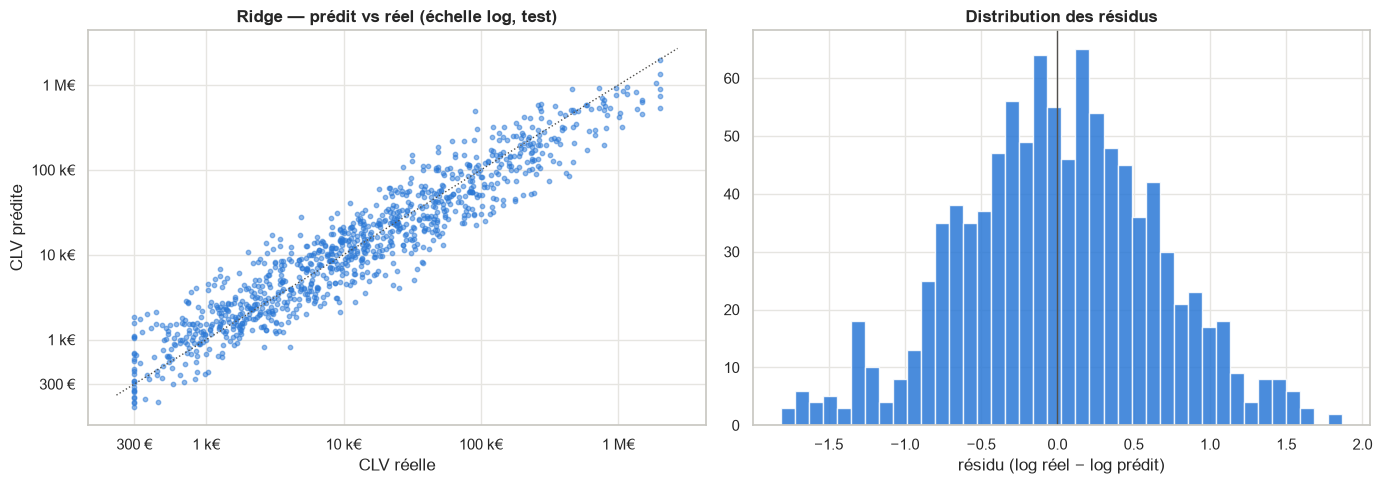

Erreur relative médiane : ×1.53 (la CLV prédite est typiquement à ±53% de la réelle)


In [59]:
best_reg = reg_fitted["Ridge (log CLV)"]
p_log = best_reg.predict(Xr_test)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.scatter(ylog_test, p_log, s=10, alpha=.5, color=C_OK)
lims = [ylog_test.min() - .3, ylog_test.max() + .3]
ax.plot(lims, lims, ls=":", color="#52514e", lw=1)
ticks = [300, 1e3, 1e4, 1e5, 1e6]
ax.set_xticks(np.log(ticks), ["300 €", "1 k€", "10 k€", "100 k€", "1 M€"])
ax.set_yticks(np.log(ticks), ["300 €", "1 k€", "10 k€", "100 k€", "1 M€"])
ax.set_xlabel("CLV réelle"); ax.set_ylabel("CLV prédite"); ax.set_title("Ridge — prédit vs réel (échelle log, test)")
ax = axes[1]
resid = ylog_test - p_log
ax.hist(resid, bins=40, color=C_OK, alpha=.85)
ax.axvline(0, color="#52514e", lw=1)
ax.set_xlabel("résidu (log réel − log prédit)"); ax.set_title("Distribution des résidus")
plt.tight_layout(); plt.show()
print(f"Erreur relative médiane : ×{np.exp(np.median(np.abs(resid))):.2f} "
      f"(la CLV prédite est typiquement à ±{(np.exp(np.median(np.abs(resid))) - 1):.0%} de la réelle)")

**Interprétation :**
- La **Ridge sur log(CLV)** explique ~90 % de la variance en échelle log (R² test 0,897, R² CV 0,894) et fait mieux que le boosting (0,889) → on retient à nouveau le modèle **le plus simple**. Le R² en euros est plus faible (0,72), car quelques très grands comptes (jusqu'à 2 M€) concentrent l'erreur absolue, ce qu'illustre aussi une RMSE en euros élevée.
- L'erreur **relative** typique est d'environ **±50 %** (facteur ×1,5) : suffisant pour **classer** les comptes par valeur (petit / moyen / grand compte), pas pour une prévision financière.
- La CLV est essentiellement expliquée par la **taille du compte** (sièges, MRR) et l'ancienneté — cohérent avec les corrélations du §6.7.
- **Usage recommandé** : colonne « valeur estimée » dans le CRM, combinée au risque de churn pour construire une matrice de priorisation *risque × valeur*.

### 12.5 Empreinte carbone du projet (CodeCarbon)

**Pourquoi le mesurer ici ?** C'est un impact du projet au même titre que le revenu préservé. On rassemble les mesures prises pendant les phases coûteuses (comparaison, optimisation), et on y ajoute le **scoring des 5 000 comptes**, qui sera l'opération répétée chaque mois en production. On en déduit une estimation **annuelle** : 12 scorings mensuels et 4 ré-entraînements trimestriels (une optimisation de la logistique).

Les quantités sont minuscules : les émissions sont affichées en **milligrammes** de CO₂eq. Pour rendre l'énergie parlante, on la compare à une recharge complète de smartphone (~15 Wh, ordre de grandeur). Toutes les mesures sont aussi enregistrées dans MLflow et dans `carbone/emissions.csv`.

In [60]:
with carbon_phase("Scoring batch de 5 000 comptes (opération mensuelle)"):
    _ = score_accounts(raw, model, meta, cat)

if EMISSIONS:
    em = pd.DataFrame(EMISSIONS).set_index("phase")
    display(em.style.format({"durée (s)": "{:.1f}", "énergie (Wh)": "{:.4f}",
                             "émissions (mg CO2eq)": "{:.2f}", "puissance CPU moyenne (W)": "{:.1f}"}))

    mg, wh = em["émissions (mg CO2eq)"], em["énergie (Wh)"]
    retrain = mg.filter(like="régression logistique").sum()
    scoring = mg.filter(like="Scoring").sum()
    annual = 4 * retrain + 12 * scoring
    SMARTPHONE_WH = 15  # ordre de grandeur d'une recharge complète de smartphone
    print(f"Total mesuré (phases ci-dessus) : {wh.sum():.3f} Wh et {mg.sum():.1f} mg CO2eq "
          f"≈ {wh.sum() / SMARTPHONE_WH:.1%} d'une recharge de smartphone")
    print(f"Intensité carbone utilisée : {mg.sum() / wh.sum():.0f} g CO2eq/kWh (mix électrique France)")
    print(f"Optimisation boosting / logistique : ×{mg.filter(like='gradient boosting').sum() / max(retrain, 1e-12):.1f} "
          f"d'émissions, pour une AUC plus faible")
    print(f"Optimisation XGBoost + Optuna / logistique : ×{mg.filter(like='XGBoost').sum() / max(retrain, 1e-12):.0f} "
          f"d'émissions, pour une AUC plus faible")
    print(f"Estimation annuelle en production (4 ré-entraînements + 12 scorings) : {annual:.1f} mg CO2eq")

    if FINAL_RUN_ID:
        with mlflow.start_run(run_id=FINAL_RUN_ID):
            mlflow.log_metrics({"carbone_total_notebook_mg": mg.sum(), "carbone_annuel_estime_mg": annual,
                                "carbone_scoring_mensuel_mg": scoring, "energie_totale_Wh": wh.sum()})
            if (CARBON_DIR / "emissions.csv").exists():
                mlflow.log_artifact(str(CARBON_DIR / "emissions.csv"))
else:
    print("CodeCarbon non installé : pas de mesure d'empreinte.")

,durée (s),énergie (Wh),émissions (mg CO2eq),puissance CPU moyenne (W)
phase,,,,
Comparaison des modèles (4 modèles × CV 5 plis),3.8,0.0201,1.12,15.0
Optimisation — régression logistique (16 combinaisons × 5 plis),0.4,0.0040,0.23,22.7
Optimisation — gradient boosting (24 combinaisons × 5 plis),5.2,0.0690,3.86,40.3
Optimisation — XGBoost + Optuna (60 essais × 5 plis),142.8,0.7008,39.27,14.7
Scoring batch de 5 000 comptes (opération mensuelle),1.2,0.0040,0.22,12.9


Total mesuré (phases ci-dessus) : 0.798 Wh et 44.7 mg CO2eq ≈ 5.3% d'une recharge de smartphone
Intensité carbone utilisée : 56 g CO2eq/kWh (mix électrique France)
Optimisation boosting / logistique : ×17.1 d'émissions, pour une AUC plus faible
Optimisation XGBoost + Optuna / logistique : ×174 d'émissions, pour une AUC plus faible
Estimation annuelle en production (4 ré-entraînements + 12 scorings) : 3.6 mg CO2eq


**Interprétation :**
- L'empreinte du projet est **négligeable** : de l'ordre de 1 Wh et de quelques dizaines de milligrammes de CO₂eq pour toutes les phases mesurées, soit moins de 10 % d'une recharge de smartphone. C'est attendu : 5 000 lignes, des modèles classiques, quelques secondes de calcul sur un processeur d'ordinateur portable et un mix électrique français peu carboné (~56 g CO₂eq/kWh). À titre de contraste, l'entraînement d'un grand modèle de langage se chiffre en centaines de tonnes.
- La mesure confirme néanmoins le **choix de sobriété** : l'optimisation du boosting émet **de 5 à 30 fois plus** que celle de la logistique selon les exécutions (valeur de cette exécution affichée ci-dessus) (plus de calcul et un processeur plus sollicité), pour une AUC plus faible. La logistique est à la fois le modèle le plus performant, le plus explicable et le plus sobre. *(Les valeurs exactes varient d'une exécution à l'autre, car la mesure inclut toute l'activité de la machine ; le sens de l'écart est stable.)*
- **L'étude Optuna / XGBoost représente à elle seule l'essentiel de l'empreinte** (de 60 à 250 fois l'optimisation de la logistique selon les exécutions, et plus de 80 % du total mesuré) — pour un modèle **moins bon**. C'est un argument concret : une recherche d'hyperparamètres large a un coût, qui ne se justifie que si elle apporte un gain. Ici, elle a surtout servi à *prouver* que le modèle simple suffisait ; on ne la relancera pas à chaque ré-entraînement, seulement si de nouvelles variables le justifient.
- Sur un vrai périmètre de production (des centaines de milliers de comptes, un historique mensuel, des grilles plus larges), ces chiffres seraient multipliés, mais le **rapport** entre les deux familles de modèles resterait du même ordre : c'est ce rapport qui guide la décision.
- Le **scoring mensuel** est quasi gratuit en énergie : le coût récurrent vient surtout du ré-entraînement. C'est un argument pour un ré-entraînement **déclenché par la dérive** (§13) plutôt que systématique et fréquent.
- *Limites* : mesure estimée (pas de lecture directe de la consommation du CPU sur Mac) et qui inclut les autres applications ouvertes. Elle ne couvre ni la fabrication du matériel, ni le stockage, ni le réseau. Les chiffres sont des **ordres de grandeur** servant à comparer des options, pas un bilan carbone complet.

**Arbitrages d'éco-conception présentés au commanditaire.** Les mesures ci-dessus sont transmises au commanditaire et à l'équipe ML (§4.8), pour qu'ils choisissent la stratégie en connaissant son coût :

| Décision | Options | Recommandation | Raison |
|---|---|---|---|
| Choix du modèle | Logistique ou boosting / XGBoost | **Logistique** | Plus performante **et** beaucoup plus sobre (voir les ratios mesurés ci-dessus) |
| Fréquence de ré-entraînement | Mensuelle, trimestrielle, sur alerte de dérive | **Trimestrielle, plus sur alerte** (§13.2) | Le gain d'un ré-entraînement mensuel n'est pas démontré ; le coût reste faible mais inutile |
| Recherche d'hyperparamètres | Large (Optuna, 60 essais) ou ciblée (petite grille) | **Grille ciblée** pour la logistique ; recherche large seulement pour évaluer un challenger | L'étude Optuna représente l'essentiel de l'empreinte mesurée, sans gain |
| Mode de scoring | Temps réel ou batch mensuel | **Batch mensuel** + API à la demande | 12 calculs par an au lieu d'un calcul permanent |
| Matériel | GPU ou CPU | **CPU** | Aucun besoin de GPU pour un modèle linéaire sur 5 000 lignes |

### 12.6 Indicateurs de suivi en production

| Type | Indicateur | Fréquence | Seuil d'alerte (proposé) |
|---|---|---|---|
| Technique | ROC-AUC / PR-AUC mesurées à M+1 sur les churns réels | Mensuelle | AUC < 0,82 (baisse > 0,05) |
| Technique | Rappel au seuil retenu | Mensuelle | < 0,75 |
| Données | PSI (dérive) par variable | Mensuelle | PSI > 0,2 |
| Métier | Taux de churn des comptes signalés **et contactés** vs **non contactés** (groupe témoin) | Trimestrielle | Pas d'écart significatif = actions inefficaces |
| Métier | MRR préservé, nombre de comptes sauvés | Trimestrielle | — |
| Usage | % d'alertes traitées par les CSM | Mensuelle | < 60 % = outil peu adopté |
| Environnement | Énergie et CO₂eq du scoring et du ré-entraînement (CodeCarbon → MLflow) | À chaque exécution | Hausse × 2 sans gain de performance |
| Équité | Rappel et taux de FP par taille / plan / pays | Trimestrielle | Écart > 0,15 entre segments |

### 📓 Journal de bord — Performance
- **Constat** : à charge CSM égale, le modèle détecte plus de churners que la règle métier.
- **Essai abandonné** : sélectionner les comptes par MRR à risque — revenu quasi identique mais 20 comptes sauvés en moins → gardé uniquement pour ordonner la liste.
- **Constat** : rappel homogène entre segments ; taux de FP plus élevé pour les PME / Starter (écart > 0,15) → actions légères recommandées et suivi dans le monitoring.
- **Décision** : CLV par Ridge sur log, usage en priorisation uniquement.
- **Constat** : empreinte carbone négligeable (quelques dizaines de mg CO₂eq, moins de 1 Wh), dominée par l'étude Optuna / XGBoost (60 à 250 fois l'optimisation de la logistique selon les exécutions, pour un modèle moins bon).
- **Limite** : l'impact en euros repose sur un taux de succès des actions supposé (25 %) → mesure par groupe témoin indispensable.

## 🟦 13. Amélioration continue (ré-entraînement, suivi, versioning) [C9]

### 13.1 Détection de dérive des données (PSI)

**Pourquoi surveiller la dérive ?** Le comportement des clients évolue (nouvelle fonctionnalité, changement de prix, crise sectorielle). Si la distribution des variables d'entrée change, le modèle peut se dégrader **avant même** qu'on puisse mesurer sa performance (il faut attendre l'échéance pour connaître les vrais churns). Le **PSI** (*Population Stability Index*) compare la distribution d'une variable entre une période de référence (le train) et le lot courant :
- PSI < 0,1 : stable ; 0,1-0,2 : à surveiller ; **> 0,2 : dérive significative**.

Le PSI est choisi car il est simple, interprétable, standard dans le scoring, et calculable sans connaître la cible.

**Démonstration :** (1) PSI entre train et test → doit être stable (même distribution) ; (2) on **simule** une baisse d'usage de 30 % et une hausse des tickets (scénario « dégradation produit ») → le PSI doit déclencher l'alerte.

In [61]:
def psi(reference, current, bins=10):
    # Population Stability Index sur les déciles de la distribution de référence
    reference, current = pd.Series(reference).dropna(), pd.Series(current).dropna()
    edges = np.unique(np.quantile(reference, np.linspace(0, 1, bins + 1)))
    edges[0], edges[-1] = -np.inf, np.inf
    ref_pct = np.histogram(reference, edges)[0] / len(reference)
    cur_pct = np.histogram(current, edges)[0] / len(current)
    ref_pct, cur_pct = np.clip(ref_pct, 1e-4, None), np.clip(cur_pct, 1e-4, None)
    return float(np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct)))


drifted = X_test.copy()
for c in ["connexions_30j", "heures_usage_30j", "taux_adoption_pct"]:
    drifted[c] = drifted[c] * 0.7
drifted["tickets_support_90j"] = drifted["tickets_support_90j"] + rng.poisson(1.5, len(drifted))

drift_cols = ["connexions_30j", "heures_usage_30j", "taux_adoption_pct", "tickets_support_90j",
              "derniere_connexion_jours", "anciennete_mois", "retards_paiement_12m", "log_mrr"]
drift = pd.DataFrame({"PSI train→test": [psi(X_train[c], X_test[c]) for c in drift_cols],
                      "PSI train→lot simulé dégradé": [psi(X_train[c], drifted[c]) for c in drift_cols]},
                     index=drift_cols)
drift["alerte"] = np.where(drift["PSI train→lot simulé dégradé"] > 0.2, "🔴 dérive",
                  np.where(drift["PSI train→lot simulé dégradé"] > 0.1, "🟠 surveiller", "🟢 stable"))
display(drift.round(3))
print(f"Score moyen prédit — test : {final_model.predict_proba(X_test)[:, 1].mean():.3f} | "
      f"lot dégradé : {final_model.predict_proba(drifted)[:, 1].mean():.3f}  (dérive de la sortie du modèle)")

,PSI train→test,PSI train→lot simulé dégradé,alerte
connexions_30j,0.008,0.454,🔴 dérive
heures_usage_30j,0.010,0.136,🟠 surveiller
taux_adoption_pct,0.009,1.669,🔴 dérive
tickets_support_90j,0.005,0.488,🔴 dérive
derniere_connexion_jours,0.005,0.005,🟢 stable
anciennete_mois,0.007,0.007,🟢 stable
retards_paiement_12m,0.003,0.003,🟢 stable
log_mrr,0.008,0.008,🟢 stable


Score moyen prédit — test : 0.277 | lot dégradé : 0.341  (dérive de la sortie du modèle)


**Lecture** : entre train et test, tous les PSI sont < 0,02 (même population). Sur le lot simulé, connexions, adoption et tickets dépassent nettement 0,2 → **alerte déclenchée** ; les heures d'usage ne passent qu'en « à surveiller » (beaucoup de valeurs proches de 0, qu'une baisse proportionnelle déplace peu entre déciles — d'où l'intérêt de suivre plusieurs variables d'un même bloc). Les variables non modifiées restent stables, ce qui montre que l'indicateur ne génère pas de fausses alertes. Le score moyen prédit passe de 0,28 à 0,34 : le modèle réagit logiquement à la dégradation. En production, ce contrôle tourne à chaque scoring mensuel, avant même de connaître les vrais churns.

### 13.2 Stratégie de ré-entraînement

| Déclencheur | Action |
|---|---|
| **Calendaire** : chaque trimestre | Ré-entraînement sur une fenêtre glissante de 12-24 mois de cohortes |
| **Performance** : AUC mesurée à M+1 < 0,82 ou rappel < 0,75 | Ré-entraînement anticipé + analyse des erreurs |
| **Dérive** : PSI > 0,2 sur une variable importante | Analyse de la cause (bug de source ? changement métier réel ?) avant ré-entraînement |
| **Changement produit** : nouveau plan, nouvelle tarification | Mise à jour du catalogue + ré-entraînement |

**Protocole de promotion (champion / challenger)** — déjà outillé par le registre MLflow (§10.1 bis) : le nouveau modèle est enregistré avec l'alias `challenger`, et sa promotion consiste à lui donner l'alias `champion`.
1. Le nouveau modèle (*challenger*) est entraîné sur les données récentes et validé **temporellement** (entraîné jusqu'à M-2, testé sur M-1) — ce que la photographie unique actuelle ne permettait pas.
2. Il n'est promu que s'il bat le *champion* sur AUC **et** PR-AUC, sans dégrader l'équité par segment.
3. Déploiement progressif possible (*shadow mode* : on calcule les deux scores pendant un mois, seul le champion est affiché).
4. **Rollback** immédiat possible via le registre de modèles.

### 13.2 bis Démonstration du ré-entraînement et transfert de connaissances

**Pourquoi une démonstration ?** La stratégie ci-dessus n'a de valeur que si le ré-entraînement est **outillé** et **reproductible**. La fonction `retrain` enchaîne ce que ferait le job trimestriel : relire la couche Gold, ré-entraîner, comparer au champion avec le même protocole, enregistrer le nouveau modèle dans le registre MLflow sous l'alias `challenger`, et ne le promouvoir `champion` que s'il gagne.

**Transfert de connaissances d'un modèle à l'autre.**
- L'**apprentissage par transfert** au sens classique (réutiliser un réseau pré-entraîné sur un grand corpus, comme en vision ou en traitement du langage) **ne s'applique pas** ici : il n'existe pas de modèle pré-entraîné pour les données de churn de *cette* entreprise, et une régression logistique s'entraîne en quelques millisecondes (§12.1 bis), sans rien à économiser.
- Le transfert se fait donc **entre versions successives** de notre modèle :
  - **Hyperparamètres** : on part de ceux du champion (`C`, `class_weight`) et on ne cherche qu'**autour** (`C/3`, `C`, `3C`) au lieu de refaire toute la grille. C'est plus sobre (§12.5) ;
  - **Décisions de conception** : variables exclues (fuite, leurres), imputations métier, seuil fondé sur les coûts, tous repris tels quels ;
  - **Historique** : le registre MLflow garde les résultats de chaque version, qui servent de référence au suivant ;
  - pour un modèle plus lourd (boosting), on pourrait aussi repartir du modèle existant (`warm_start`, `xgb_model`) ou reprendre une étude Optuna enregistrée.

**Ce qu'on démontre** : deux ré-entraînements avec les mêmes données, faute de nouvelle cohorte. (1) Le **champion ré-entraîné** (mêmes variables) et (2) un **challenger** avec le jeu réduit du §8.6. En production, `retrain` serait appelé sur les cohortes les plus récentes, et la comparaison se ferait sur le mois suivant (validation temporelle).

In [62]:
def retrain(num_cols, cat_cols, base_params):
    # Job de ré-entraînement : relit Gold, part des hyperparamètres du champion, recherche locale autour de C
    g = read_gold(gold_path)
    X_g, y_g = g[num_cols + cat_cols].loc[X_train.index], g[TARGET].loc[X_train.index]  # en production : cohortes récentes
    c0 = base_params["C"]
    search = GridSearchCV(
        Pipeline([("prep", make_preprocessor(num_cols, cat_cols)),
                  ("model", LogisticRegression(max_iter=5000, class_weight=base_params["class_weight"]))]),
        {"model__C": [c0 / 3, c0, c0 * 3]}, cv=CV, n_jobs=-1, refit="roc_auc",
        scoring={"roc_auc": "roc_auc", "pr_auc": "average_precision"})
    search.fit(X_g, y_g)
    b, res = search.best_index_, search.cv_results_
    return search.best_estimator_, {"C": search.best_params_["model__C"],
                                    "cv_roc_auc": res["mean_test_roc_auc"][b], "± AUC": res["std_test_roc_auc"][b],
                                    "cv_pr_auc": res["mean_test_pr_auc"][b]}


champion_params = metadata["hyperparameters"]
_, champ = retrain(NUM_FEATURES, CAT_FEATURES, champion_params)
challenger, chal = retrain(NUM_REDUCED, CAT_REDUCED, champion_params)

gain_auc, gain_pr = chal["cv_roc_auc"] - champ["cv_roc_auc"], chal["cv_pr_auc"] - champ["cv_pr_auc"]
promote = gain_auc > champ["± AUC"] and gain_pr > 0     # règle du §13.2 : gain supérieur au bruit
display(pd.DataFrame({"champion ré-entraîné (22 variables)": champ,
                      f"challenger (jeu réduit, {len(NUM_REDUCED) + len(CAT_REDUCED)} variables)": chal}).T.round(4))
print(f"Gain du challenger : AUC {gain_auc:+.4f}, PR-AUC {gain_pr:+.4f} (bruit : ± {champ['± AUC']:.4f})")
print("Décision :", "promotion en champion" if promote else "pas de promotion — le challenger reste en attente")

if MLFLOW_OK:
    feats_c = NUM_REDUCED + CAT_REDUCED
    X_sig_c = X_train[feats_c].astype({c: "float64" for c in NUM_REDUCED}).astype({c: "object" for c in CAT_REDUCED})
    with mlflow.start_run(run_name="Ré-entraînement — challenger jeu réduit"):
        mlflow.set_tags({"phase": "reentrainement", "statut": "champion" if promote else "challenger"})
        mlflow.log_params({"C": chal["C"], "class_weight": champion_params["class_weight"],
                           "hyperparametres_de_depart": "champion", "features": ", ".join(feats_c)})
        mlflow.log_metrics({"cv_roc_auc": chal["cv_roc_auc"], "cv_pr_auc": chal["cv_pr_auc"],
                            "gain_auc_vs_champion": gain_auc, "gain_pr_auc_vs_champion": gain_pr})
        mlflow.sklearn.log_model(challenger, name="model", registered_model_name=REGISTERED_MODEL,
                                 signature=infer_signature(X_sig_c, challenger.predict_proba(X_train[feats_c])[:, 1]),
                                 input_example=X_sig_c.head(3), skops_trusted_types=["numpy.dtype"])
    client = MlflowClient()
    v_chal = max(int(m.version) for m in client.search_model_versions(f"name='{REGISTERED_MODEL}'"))
    client.set_registered_model_alias(REGISTERED_MODEL, "challenger", str(v_chal))
    if promote:
        client.set_registered_model_alias(REGISTERED_MODEL, "champion", str(v_chal))
    aliases = {a: client.get_model_version_by_alias(REGISTERED_MODEL, a).version for a in ["champion", "challenger"]}
    print(f"Registre {REGISTERED_MODEL} : {aliases}")

,C,cv_roc_auc,± AUC,cv_pr_auc
champion ré-entraîné (22 variables),0.03,0.8922,0.0090,0.7936
"challenger (jeu réduit, 18 variables)",0.09,0.8922,0.0086,0.7940


Gain du challenger : AUC -0.0000, PR-AUC +0.0004 (bruit : ± 0.0090)
Décision : pas de promotion — le challenger reste en attente


Registre churn_saas_logistic : {'champion': 10, 'challenger': 11}


Registered model 'churn_saas_logistic' already exists. Creating a new version of this model...
Created version '11' of model 'churn_saas_logistic'.


**Lecture** :
- Le **champion ré-entraîné** retrouve exactement le même réglage (`C` = 0,03) et la même AUC (0,892) : le ré-entraînement est **reproductible**.
- Le **challenger** à 18 variables fait jeu égal (même AUC, PR-AUC +0,0004), avec un `C` légèrement différent trouvé par la recherche locale autour du champion.
- **Pas de promotion** : le gain est très inférieur au bruit (± 0,009). Le challenger est enregistré dans le registre MLflow avec l'alias `challenger`, et l'alias `champion` reste sur le modèle du §10.1 bis. Les numéros de version affichés augmentent à chaque exécution du notebook.
- **Suite prévue** : réévaluer ce challenger sur la prochaine cohorte réelle (validation temporelle). S'il fait toujours jeu égal, le promouvoir **pour sa sobriété** : moins de données collectées (minimisation, §4.3) et une API plus simple. Selon la convention du §13.3, ce serait une version **2.0.0**, car les variables changent.

### 13.3 Versioning et traçabilité

- **Code** : **en place** — dépôt Git sur GitHub (`churn-saas-ia`), étiquette `v1.0.0`, tests `pytest` sur les fonctions de parsing (chaque format de date et de nombre est un cas de test) et sur l'API, exécutés automatiquement par le pipeline CI/CD (§10.6). Étape suivante : extraire l'entraînement du notebook en modules Python (`train.py`, `score.py`) avec revue de code par pull request.
- **Données** : couches Bronze / Silver / Gold avec empreintes SHA-256 (en place, §5.0) ; en production, un snapshot mensuel de la table Gold (ou DVC) → chaque modèle est ré-entraînable à l'identique, et son run MLflow indique l'empreinte des données utilisées.
- **Expériences** : chaque évaluation, recherche d'hyperparamètres et mesure carbone de ce notebook est un run MLflow (experiment `churn_saas`) → on peut retrouver pourquoi un modèle a été écarté.
- **Modèles** : registre MLflow (en place, §10.1 bis) — version sémantique (`1.0.0` → `1.1.0` si ré-entraînement, `2.0.0` si changement de variables), métriques, hyperparamètres, seuil, checksum (déjà produits au §10.1).
- **Scores** : chaque score est historisé avec la version du modèle qui l'a produit → audit et mesure de performance a posteriori.

### 13.4 Boucle de feedback métier

- Les CSM qualifient chaque alerte dans le CRM (« contacté », « motif réel du départ », « action menée ») → données d'entraînement plus riches et mesure de l'efficacité des actions.
- **Groupe témoin** : 10 % des comptes signalés ne reçoivent pas d'action spécifique → seule façon de mesurer l'**effet causal** des actions de rétention et de calibrer les hypothèses de coût (§9.3).
- À terme : passer d'un modèle de *risque* à un modèle d'*uplift* (qui prédit l'effet de l'action), pour cibler les clients **qu'on peut encore convaincre** plutôt que ceux qui partiront quoi qu'il arrive.

### 13.5 Pistes d'amélioration du modèle

- Ajouter l'**historique** des métriques (tendances 3 mois : variation des connexions, de l'adoption) — la courbe d'apprentissage (§9.2) montre que c'est l'information, pas le volume, qui limite la performance.
- Structurer le commentaire CSM en catégories **horodatées** (disponibles avant l'échéance) pour le rendre utilisable sans fuite.
- Modèle de **survie** (délai avant churn) pour anticiper au-delà de la prochaine échéance.
- **Retirer le profil de l'entreprise** (secteur, pays, taille) des variables du modèle : il n'apporte aucun gain mesurable (§8.5). Ce serait une minimisation des données sans perte de performance ; ces variables resteraient utilisées pour l'audit d'équité par segment. À confirmer sur la prochaine cohorte avant de changer le modèle champion.

### 13.6 Cycle de vie des jeux de données

| Jeu de données | Propriétaire | Accès | Mise à jour | Conservation (proposée) | Fin de vie |
|---|---|---|---|---|---|
| **Bronze** (exports sources tels que reçus) | Équipe data | Data engineers | Mensuelle (un dossier daté par mois) | 36 mois | Archivage froid à 12 mois, suppression à 36 mois |
| **Silver** (nettoyé, avec `client_id` et pseudonyme) | Équipe data | **Restreint** (contient la correspondance avec l'identité) | Mensuelle | 36 mois | Suppression ; c'est ici que s'applique le **droit à l'effacement** |
| **Gold** (variables du modèle, pseudonymisé) | Équipe ML | Data scientists | Mensuelle, versionnée par empreinte SHA-256 | Tant qu'un modèle entraîné dessus est conservé, + 12 mois | Supprimée avec la version de modèle correspondante |
| **Scores mensuels** | Customer Success | CSM et managers CS | Mensuelle | 24 mois (§4.3) | Suppression ; seuls des indicateurs agrégés et anonymes sont gardés pour le monitoring |
| **Modèles et métadonnées** (registre MLflow) | Équipe ML | Équipe ML, audit | À chaque ré-entraînement | Champion + 2 versions précédentes actives | Archivage des versions plus anciennes |
| **Rapports** de qualité, d'ingestion et de carbone | Équipe data | Équipe data, audit | À chaque exécution | Même durée que le jeu décrit | Supprimés avec lui |

**Points vérifiés ou prévus :**
- **Accessibilité des données produites** : chaque couche est **relue après écriture** et comparée à l'original (Silver §6.1 bis, Gold §7.3) ; le modèle est rechargé avec vérification d'empreinte (§10.2, §10.4) et depuis le registre MLflow (§10.1 bis).
- **Usages futurs** : Silver peut alimenter des tableaux de bord ou d'autres modèles (la CLV, §12.4) ; l'historisation mensuelle de Gold permettra la validation temporelle et des variables de tendance (§13.5).
- **Caractéristiques du cas d'usage** : rythme mensuel (scoring et mise à jour des couches), photographie à date fixe, conservation alignée sur l'horizon de ré-entraînement.
- **Gouvernance** : un propriétaire par jeu, accès par rôle, empreintes et rapports à chaque étape, propagation d'une demande d'effacement de Bronze / Silver vers Gold à la reconstruction suivante.
- **Soumission aux parties prenantes** : ce cycle de vie est présenté aux propriétaires des données, au DPO et au commanditaire, qui valident les durées de conservation et les accès (§4.8).


## 🟦 14. Conclusion (synthèse et recommandations)

### Synthèse

1. **Données** : un jeu volontairement imparfait a été nettoyé de façon traçable et réutilisable en production (35 doublons, 4 types de défauts de format, 3 formats de date validés à 100 %, imputations métier via le catalogue).
2. **Fuite de données** : `sante_compte_fin_periode` (AUC 0,999 à elle seule) a été détectée, démontrée et exclue ; le commentaire CSM a été écarté par précaution (fuite partielle + RGPD).
3. **Leurres** : couleur de thème, datacenter, groupe A/B, jour de souscription — sans pouvoir prédictif (χ² et permutation), exclus.
4. **Modèle** : une **régression logistique régularisée** l'emporte sur la Random Forest, le Gradient Boosting et un XGBoost optimisé par Optuna, avec une ROC-AUC ≈ 0,88 et une PR-AUC ≈ 0,76 sur le test, des probabilités calibrées et une explicabilité native.
5. **Décision** : seuil 0,18 choisi selon le coût métier (FN = 5 × FP) sous contrainte de rappel ≥ 0,80 → ~9 churners sur 10 détectés, coût des erreurs réduit de 40 % par rapport au seuil par défaut.
6. **Impact** : à charge CSM égale, le modèle contacte 15 % de churners de plus que la règle métier et 80 % de plus que le hasard ; le MRR à risque sert à ordonner la liste, pas à sélectionner.
7. **Industrialisation** : expériences tracées et modèle versionné dans MLflow (alias `champion`) ; empreinte carbone mesurée avec CodeCarbon, négligeable (quelques dizaines de mg CO₂eq, moins de 1 Wh) ; optimiser la logistique coûte 5 à 30 fois moins que le boosting scikit-learn et 60 à 250 fois moins que XGBoost avec Optuna (selon les exécutions).
8. **CLV** : régression Ridge sur log(CLV), R² ≈ 0,90 en log, utilisée pour enrichir la priorisation, jamais comme variable du churn.

### Recommandations

| # | Recommandation | Horizon |
|---|---|---|
| 1 | Déployer le scoring **mensuel** dans le CRM avec probabilité, facteurs principaux et MRR à risque | Court terme |
| 2 | **Former les CSM** à la lecture du score (probabilité ≠ certitude, facteurs = pistes de discussion) | Court terme |
| 3 | Mettre en place un **groupe témoin** pour mesurer l'effet réel des actions et recalibrer les coûts / le seuil | Court terme |
| 4 | Historiser les features mensuelles pour permettre une **validation temporelle** et des variables de tendance | Moyen terme |
| 5 | Actions différenciées : suivi CSM individuel pour les comptes à forte valeur, actions « à l'échelle » pour les TPE / Starter | Moyen terme |
| 6 | Évoluer vers un modèle d'**uplift** pour cibler les clients réellement récupérables | Long terme |

> **Message clé** : la performance vient de la démarche (détection de la fuite, nettoyage rigoureux, variables métier, seuil aligné sur les coûts), pas de la complexité du modèle. Un modèle simple, explicable et honnêtement évalué est plus utile aux équipes qu'un modèle « parfait » qui s'appuierait sur une information venue du futur.

## 🟦 15. Annexes (versions, paramètres, dépendances, fonctions utilitaires)

### 15.1 Versions de l'environnement et dépendances

**Pourquoi ?** Reproductibilité : un modèle scikit-learn sérialisé n'est garanti qu'avec la même version de la bibliothèque. On génère aussi un `requirements.txt` figé à côté du modèle.

In [63]:
import importlib
libs = ["pandas", "numpy", "pyarrow", "scikit-learn", "scipy", "xgboost", "optuna", "matplotlib", "seaborn", "joblib", "mlflow", "codecarbon", "fastapi"]
versions = {}
for lib in libs:
    try:
        versions[lib] = importlib.import_module(lib.replace("scikit-learn", "sklearn")).__version__
    except ImportError:
        versions[lib] = "non installé"
(MODEL_DIR / "requirements.txt").write_text("\n".join(f"{k}=={v}" for k, v in versions.items() if v != "non installé") + "\n")
print(f"Python {sys.version.split()[0]} — {platform.platform()}")
pd.Series(versions, name="version").to_frame()

Python 3.12.13 — macOS-27.0.1-arm64-arm-64bit


,version
pandas,3.0.6
numpy,2.5.3
pyarrow,25.0.1
scikit-learn,1.9.1
scipy,1.18.1
xgboost,3.4.1
optuna,5.0.0
matplotlib,3.11.2
seaborn,0.13.2
joblib,1.6.0


### 15.2 Paramètres du modèle final et fichiers produits

In [64]:
print(json.dumps({k: metadata[k] for k in ["version", "algorithm", "hyperparameters", "decision_threshold",
                                           "cost_assumptions_eur", "test_metrics"]}, indent=2, ensure_ascii=False))
print("\nFichiers produits :")
for p in sorted(p for d in [BRONZE_DIR, SILVER_DIR, GOLD_DIR, MODEL_DIR, API_DIR, CARBON_DIR] for p in d.iterdir() if p.is_file()) + [Path("Dockerfile"), Path(".dockerignore"), Path("mlflow.db")]:
    if not p.exists():
        continue
    print(f"  {p}  ({p.stat().st_size / 1024:.1f} Ko)")

{
  "version": "1.0.0",
  "algorithm": "LogisticRegression (L2)",
  "hyperparameters": {
    "C": 0.03,
    "class_weight": null
  },
  "decision_threshold": 0.18,
  "cost_assumptions_eur": {
    "false_positive": 300,
    "false_negative": 1500
  },
  "test_metrics": {
    "ROC-AUC": 0.882,
    "PR-AUC": 0.7624,
    "Brier": 0.1206,
    "Rappel @ 0.18": 0.8857,
    "Précision @ 0.18": 0.531,
    "F1 @ 0.18": 0.664,
    "% comptes signalés": 0.467
  }
}

Fichiers produits :
  api/__init__.py  (0.0 Ko)
  api/app.py  (5.2 Ko)
  api/churn_scoring.py  (5.6 Ko)
  api/openapi.json  (10.5 Ko)
  api/requirements.txt  (0.1 Ko)
  carbone/emissions.csv  (18.0 Ko)
  data/bronze/_ingestion.json  (0.7 Ko)
  data/bronze/catalogue_plans.csv  (0.2 Ko)
  data/bronze/churn_saas_complet.csv  (710.6 Ko)
  data/bronze/churn_saas_echantillon.csv  (7.6 Ko)
  data/gold/_meta.json  (2.0 Ko)
  data/gold/features_churn.parquet  (298.6 Ko)
  data/silver/_qualite.json  (2.4 Ko)
  data/silver/comptes.parquet  (312.5

### 15.3 Fonctions utilitaires (récapitulatif)

| Fonction | Section | Rôle |
|---|---|---|
| `to_number`, `normalize_cat`, `parse_dates`, `parse_raw` | §6.0 | Conversion des formats bruts (réutilisées en production) |
| `sha256_file` | §5.0 | Empreinte d'un fichier (traçabilité des couches) |
| `add_features` | §7.1 | Imputations métier + variables dérivées (déterministes) |
| `pseudonymize` | §6.1 bis | Pseudonyme HMAC-SHA256 de l'identifiant |
| `read_gold` | §7.3 | Lecture de la couche Gold avec des types identiques au développement |
| `make_preprocessor` | §7.4 | Imputation médiane / `Inconnu`, standardisation, one-hot |
| `evaluate` | §8.1 | Validation croisée stratifiée 5 plis (AUC, PR-AUC, Brier) |
| `business_rule_score` | §8.2 | Baseline métier sans ML |
| `xgb_pipeline`, `objective`, `log_trial` | §9.1 bis | Challenger XGBoost : fonction objectif Optuna (CV avec élagage) et traçage MLflow de chaque essai |
| `threshold_table` | §9.3 | Rappel, précision, coût par seuil |
| `load_model`, `score_accounts` | §10.2 | Chargement vérifié + scoring de bout en bout avec explications |
| `api/app.py` : `load_bundle`, `require_api_key`, routes `/health`, `/ready`, `/score` | §10.4 | API FastAPI |
| `psi` | §13.1 | Indice de stabilité de population (dérive) |
| `log_run` | Configuration | Enregistre un run MLflow (paramètres, métriques, artefacts) |
| `carbon_phase` | Configuration | Mesure énergie / CO₂eq d'un bloc de code avec CodeCarbon |

### 15.4 Glossaire

- **Churn** : résiliation d'un abonnement à l'échéance.
- **MRR** (*Monthly Recurring Revenue*) : revenu mensuel récurrent d'un compte.
- **CLV** (*Customer Lifetime Value*) : valeur totale estimée d'un client sur sa durée de vie.
- **Fuite de données** (*data leakage*) : utilisation d'une information qui ne serait pas disponible au moment de la prédiction ; gonfle artificiellement les performances.
- **Variable leurre** : variable sans lien avec la cible, qui peut créer des corrélations fortuites.
- **ROC-AUC** : probabilité qu'un churner tiré au hasard ait un score plus élevé qu'un fidèle tiré au hasard.
- **PR-AUC** (*Average Precision*) : aire sous la courbe précision-rappel ; référence = taux de positifs.
- **Rappel** : part des churners réels détectés. **Précision** : part des alertes qui sont de vrais churners.
- **Brier score** : erreur quadratique moyenne des probabilités (plus bas = mieux calibré).
- **Validation croisée** : entraînements / évaluations successifs sur des partitions différentes pour estimer la performance de façon robuste.
- **Prédictions hors-plis (OOF)** : prédictions obtenues pour chaque ligne par un modèle qui ne l'a pas vue à l'entraînement.
- **Importance par permutation** : perte de performance quand on mélange une variable ; mesure son utilité pour le modèle.
- **PSI** : indice mesurant l'écart entre deux distributions d'une même variable.
- **Champion / challenger** : le modèle en production (champion) n'est remplacé que si un nouveau modèle (challenger) fait mieux.
- **Architecture médaillon (Bronze / Silver / Gold)** : organisation des données en trois couches — brutes, nettoyées, prêtes pour l'usage.
- **Pseudonymisation** : remplacement d'un identifiant par un pseudonyme ; réversible pour qui détient la clé ou la correspondance (les données restent protégées par le RGPD).
- **Anonymisation** : transformation irréversible empêchant toute ré-identification, y compris par croisement de variables (quasi-identifiants).
- **HMAC** : empreinte calculée avec une clé secrète ; sans la clé, on ne peut ni la recalculer ni la « deviner ».
- **Parquet** : format de fichier en colonnes, compressé, qui conserve les types des données.
- **Lignée des données** (*data lineage*) : capacité à retrouver de quelles données exactes provient un résultat.
- **Grid search** : recherche exhaustive testant toutes les combinaisons d'une grille d'hyperparamètres.
- **Optuna** : bibliothèque d'optimisation d'hyperparamètres qui choisit les essais suivants à partir des résultats précédents.
- **TPE** (*Tree-structured Parzen Estimator*) : algorithme d'Optuna qui modélise les zones de l'espace de recherche donnant de bons scores.
- **Élagage** (*pruning*) : arrêt anticipé d'un essai dont les résultats intermédiaires sont mauvais.
- **XGBoost** : bibliothèque de gradient boosting d'arbres de décision, très utilisée sur données tabulaires.
- **MLflow** : outil open source de suivi des expériences (runs), de stockage des modèles et de registre de versions.
- **Alias `champion`** : étiquette du registre MLflow qui désigne la version du modèle utilisée en production.
- **CO₂eq** : équivalent CO₂, unité qui agrège les différents gaz à effet de serre.
- **Uplift** : modélisation de l'effet d'une action (différence de probabilité avec / sans action).